# Homework 2 – Regression and Classification: Error Analysis

Student Name: Elior Nassi  
Student ID: 314806704

---

## 1. Regression Error Analysis

### 1.1 Residual Analysis

The objective of this section is to analyze the prediction errors of a regression model using out-of-fold predictions obtained through k-fold cross-validation.

For each observation, the residual is defined as:

**Residual = y - ŷ**

where `y` is the true value and `ŷ` is the predicted value.

A Linear Regression model is used as the baseline model for the residual analysis.

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [137]:
df = pd.read_csv(
    "data/named_anchorages_v2_20221206.csv",
    low_memory=False
)

df.head()

,s2id,lat,lon,label,sublabel,label_source,iso3,distance_from_shore_m,drift_radius,dock
0,477eac73,45.472335,12.448750,ITA-196,CA' SAVIO,anchorage_overrides,ITA,0.0,0.063046,True
1,3442a529,25.183666,121.403120,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.0,0.154328,True
2,3442a52f,25.184004,121.410104,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.0,0.059729,True
3,3442a4d5,25.189911,121.397634,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.0,0.172828,False
4,3442a4d7,25.184666,121.397444,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.0,0.175050,False


In [138]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (166482, 10)

Column names:
['s2id', 'lat', 'lon', 'label', 'sublabel', 'label_source', 'iso3', 'distance_from_shore_m', 'drift_radius', 'dock']

Data types:
s2id                         str
lat                      float64
lon                      float64
label                        str
sublabel                     str
label_source                 str
iso3                         str
distance_from_shore_m    float64
drift_radius             float64
dock                      object
dtype: object

Missing values:
s2id                        0
lat                         0
lon                         0
label                       0
sublabel                 6284
label_source                0
iso3                        0
distance_from_shore_m      25
drift_radius              153
dock                       20
dtype: int64


#### Target and Feature Selection

The regression target is **`drift_radius`**, since it is a continuous numerical variable and therefore defines a natural regression problem.

The following features are used:

- Numerical features: `lat`, `lon`, `distance_from_shore_m`
- Categorical features: `dock`, `iso3`, `label_source`

The `s2id` column is excluded because it is a unique identifier rather than a meaningful predictive feature.

The `label` and `sublabel` columns are also excluded because they contain a very large number of location-specific categories. Including them could cause the model to memorize individual locations instead of learning general relationships.

Observations with a missing target value are removed because a regression model cannot be trained or evaluated without the true target. Missing feature values are handled inside the modeling pipeline so that preprocessing is performed independently within each cross-validation fold and does not introduce data leakage.

In [139]:
target = "drift_radius"

numeric_features = [
    "lat",
    "lon",
    "distance_from_shore_m"
]

categorical_features = [
    "dock",
    "iso3",
    "label_source"
]

features = numeric_features + categorical_features

# Remove only observations for which the regression target is missing
reg_df = df.dropna(subset=[target]).copy().reset_index(drop=True)

X = reg_df[features]
y = reg_df[target]

print("Original number of observations:", len(df))
print("Observations used for regression:", len(reg_df))
print("Removed because target was missing:", df[target].isna().sum())

Original number of observations: 166482
Observations used for regression: 166329
Removed because target was missing: 153


#### Choice of k for Cross-Validation

A **5-fold cross-validation** scheme is used.

The dataset contains more than 166,000 observations, so each fold still contains a large number of samples. With `k = 5`, approximately 80% of the observations are used for training and 20% for validation in each iteration.

Using a larger value such as `k = 10` would increase the computational cost considerably while providing only a limited reduction in validation bias for a dataset of this size.

Therefore, `k = 5` provides a reasonable balance between computational efficiency and reliable performance estimation while maintaining a suitable bias-variance trade-off.

The data are shuffled before the folds are created, and a fixed random seed is used to make the experiment reproducible.

In [140]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### Out-of-Fold Predictions

Residual analysis must be based on observations that were not used to train the model that predicted them.

Therefore, `cross_val_predict` is used to generate an **out-of-fold prediction** for every observation.

For each fold, the model is trained on the other four folds and predicts only the held-out fold. As a result, every residual is calculated from a prediction made on previously unseen data.

In [141]:
y_pred = cross_val_predict(
    regression_pipeline,
    X,
    y,
    cv=cv,
    method="predict"
)

analysis_df = reg_df.copy()

analysis_df["predicted"] = y_pred
analysis_df["residual"] = y - y_pred
analysis_df["absolute_error"] = np.abs(analysis_df["residual"])

print("Out-of-fold predictions generated:", len(y_pred))

analysis_df[
    [target, "predicted", "residual", "absolute_error"]
].head()

Out-of-fold predictions generated: 166329


,drift_radius,predicted,residual,absolute_error
0,0.063046,0.072109,-0.009063,0.009063
1,0.154328,0.076042,0.078286,0.078286
2,0.059729,0.075865,-0.016136,0.016136
3,0.172828,0.115290,0.057538,0.057538
4,0.175050,0.114938,0.060112,0.060112


#### Residuals as a Function of Predicted Values

The following plot shows the residual of each observation as a function of the predicted value.

For a well-specified regression model, the residuals should ideally be randomly scattered around zero without a clear systematic pattern.

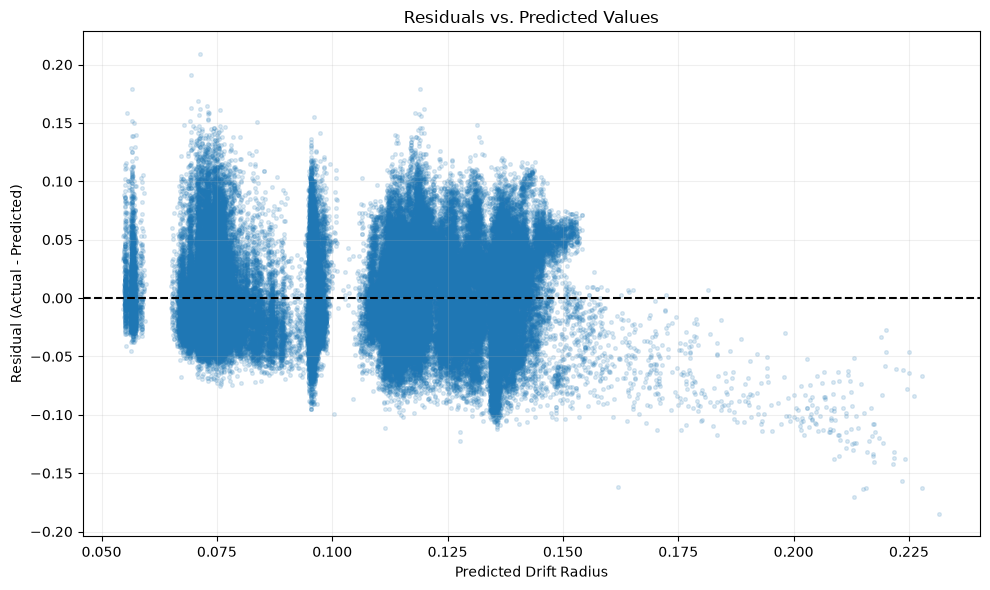

In [142]:
plt.figure(figsize=(10, 6))

plt.scatter(
    analysis_df["predicted"],
    analysis_df["residual"],
    alpha=0.15,
    s=7
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Predicted Drift Radius")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs. Predicted Values")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### Distribution of Residuals

The distribution of the residuals is examined to determine whether prediction errors are approximately centered around zero and whether the distribution is symmetric or contains noticeable tails or skewness.

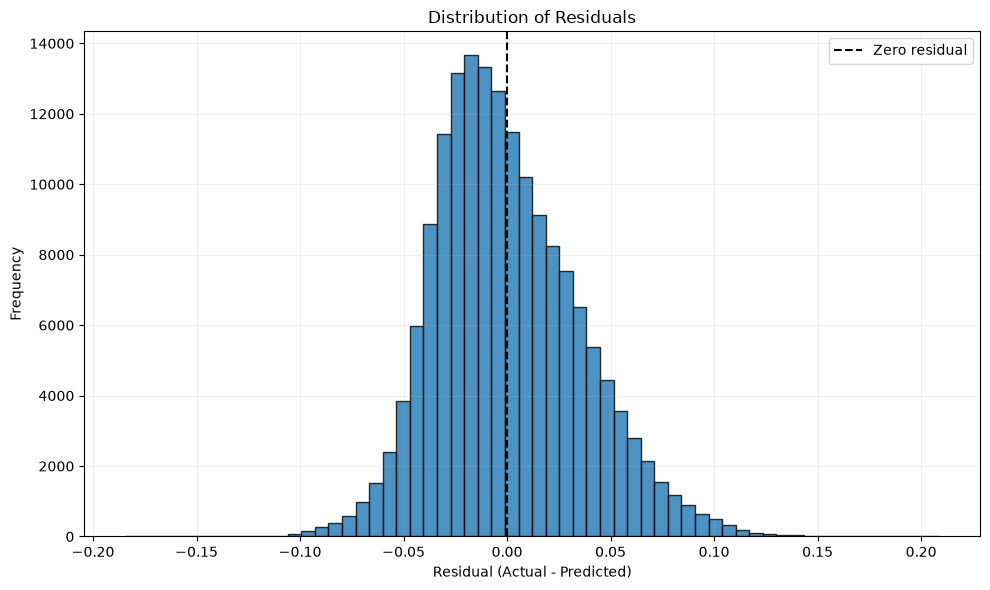

In [143]:
plt.figure(figsize=(10, 6))

plt.hist(
    analysis_df["residual"],
    bins=60,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Zero residual"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### Numerical Residual Diagnostics

In addition to visual inspection, numerical statistics are calculated to determine whether the residuals are centered around zero and to quantify their overall spread.

In [144]:
residual_summary = pd.Series({
    "Mean residual": analysis_df["residual"].mean(),
    "Median residual": analysis_df["residual"].median(),
    "Residual standard deviation": analysis_df["residual"].std(),
    "Mean absolute error": analysis_df["absolute_error"].mean(),
    "Positive residuals (%)":
        (analysis_df["residual"] > 0).mean() * 100,
    "Negative residuals (%)":
        (analysis_df["residual"] < 0).mean() * 100
})

residual_summary

Mean residual                 -5.272868e-07
Median residual               -4.270910e-03
Residual standard deviation    3.498325e-02
Mean absolute error            2.780708e-02
Positive residuals (%)         4.513885e+01
Negative residuals (%)         5.486115e+01
dtype: float64

#### Residual Behavior Across Prediction Levels

To support the visual analysis, the predictions are divided into ten approximately equally sized groups.

For each group, the mean residual, residual standard deviation, and mean absolute error are calculated.

Changes in the mean residual may indicate systematic prediction bias, while changes in the residual standard deviation or MAE may indicate non-constant error variance (heteroscedasticity).

In [145]:
analysis_df["prediction_group"] = pd.qcut(
    analysis_df["predicted"],
    q=10,
    duplicates="drop"
)

prediction_group_summary = (
    analysis_df
    .groupby("prediction_group", observed=True)
    .agg(
        observations=("residual", "size"),
        mean_predicted=("predicted", "mean"),
        mean_residual=("residual", "mean"),
        residual_std=("residual", "std"),
        MAE=("absolute_error", "mean")
    )
)

prediction_group_summary

,observations,mean_predicted,mean_residual,residual_std,MAE
prediction_group,,,,,
"(0.0537, 0.0721]",16633,0.067947,0.000135,0.030880,0.023075
"(0.0721, 0.0745]",16633,0.073259,-0.001814,0.029695,0.022480
"(0.0745, 0.0805]",16633,0.076072,0.000937,0.032707,0.024883
"(0.0805, 0.0955]",16633,0.093007,-0.001722,0.033520,0.027290
"(0.0955, 0.0978]",16633,0.096094,-0.001000,0.032064,0.026164
"(0.0978, 0.115]",16632,0.111764,-0.003686,0.033331,0.027113
"(0.115, 0.121]",16633,0.117675,0.010444,0.037041,0.031044
"(0.121, 0.133]",16633,0.127012,0.004397,0.037980,0.031114
"(0.133, 0.136]",16633,0.135336,-0.014089,0.034799,0.030681


#### Error Analysis by Sector

The dataset does not contain a variable explicitly named `sector`.

Therefore, for this analysis, a **geographical sector** is defined using the `iso3` country code. This allows the error behavior to be compared across meaningful geographic subpopulations.

To reduce the risk of drawing conclusions from very small groups, only countries containing at least 100 observations are included in the comparison.

In [146]:
overall_mae = analysis_df["absolute_error"].mean()

sector_summary = (
    analysis_df
    .dropna(subset=["iso3"])
    .groupby("iso3")
    .agg(
        observations=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
        residual_std=("residual", "std")
    )
)

sector_summary = sector_summary[
    sector_summary["observations"] >= 100
].copy()

sector_summary["MAE_ratio_vs_overall"] = (
    sector_summary["MAE"] / overall_mae
)

sector_summary = sector_summary.sort_values(
    "MAE",
    ascending=False
)

sector_summary.head(10)

,observations,MAE,mean_residual,residual_std,MAE_ratio_vs_overall
iso3,,,,,
BGD,469,0.073433,0.071271,0.025488,2.640806
GIN,113,0.053268,0.047027,0.038505,1.915641
CMR,146,0.053011,0.033773,0.051362,1.906377
GAB,105,0.040315,0.011711,0.042913,1.449794
IRQ,353,0.039690,0.028076,0.039339,1.427327
BRA,3347,0.039499,0.004248,0.049229,1.420468
TKM,200,0.038917,-0.038823,0.013527,1.399552
QAT,482,0.038092,0.005523,0.042903,1.369879
MOZ,184,0.037634,0.025086,0.034000,1.353392


#### Interpretation

**1. Are the residuals centered around zero?**

Yes, the residuals are centered around zero in terms of their overall mean. The mean residual is approximately zero, which indicates that the model does not exhibit a strong global tendency to systematically overpredict or underpredict the target.

However, the median residual is slightly negative and approximately 54.9% of the residuals are negative. This indicates that the distribution is not perfectly symmetric and that the model overpredicts slightly more frequently than it underpredicts. Larger positive residuals compensate for this effect and bring the overall mean close to zero.


**2. Do the residuals exhibit any systematic patterns?**

Yes. The residual-versus-predicted plot does not show a completely random cloud around zero. Several visible bands and changes in residual behavior appear across different predicted-value regions.

The numerical analysis across prediction groups also shows changes in the mean residual. This suggests that the linear model does not capture all relationships in the data equally well and that some subpopulations or nonlinear relationships remain unexplained.


**3. Is there evidence of heteroscedasticity?**

Yes, there is evidence of non-constant error variance.

The spread of the residuals changes across the range of predicted values. The residual standard deviation and MAE generally become larger at higher prediction levels. For example, the MAE is approximately 0.022–0.023 in some of the lower prediction groups and increases to approximately 0.034 in the highest prediction group.

Therefore, the assumption of constant residual variance is not fully satisfied.


**4. Is there a sector that is more likely to have high error rates? If so, why might this happen?**

Because the dataset does not contain an explicit sector variable, country (`iso3`) was used as a geographical sector.

Clear differences in error magnitude were observed between countries. Among sectors containing at least 100 observations, Bangladesh (`BGD`) showed the highest MAE, approximately 0.073, which is about 2.6 times the overall MAE of approximately 0.028. Guinea (`GIN`) and Cameroon (`CMR`) also showed substantially higher-than-average errors.

These differences suggest that the relationship between the available features and `drift_radius` may vary across geographical regions. Possible explanations include local anchorage characteristics that are not represented by the current features, differences in the composition or quality of observations, and nonlinear regional effects that cannot be fully captured by a linear regression model.

These results indicate a systematic subgroup effect, although the analysis alone cannot establish its exact causal explanation.

### 1.2 Error as a Function of Features

This section examines whether the prediction errors depend systematically on the input features.

For numerical features, the feature values are plotted against both:

- the signed residual, `y - ŷ`
- the absolute error, `|y - ŷ|`

The residual plots help identify systematic overprediction or underprediction, while the absolute-error plots show whether prediction accuracy changes across different regions of the feature space.

Because the dataset contains more than 166,000 observations, a fixed random sample is used only for the scatter visualization to reduce overplotting. All numerical summaries and binned trends are calculated using the complete dataset.

In [147]:
# A sample is used only for clearer scatter plots.
# The complete dataset is still used for all numerical calculations.

plot_sample = analysis_df.sample(
    n=min(30000, len(analysis_df)),
    random_state=42
)

print("Observations used for analysis:", len(analysis_df))
print("Observations displayed in scatter plots:", len(plot_sample))

Observations used for analysis: 166329
Observations displayed in scatter plots: 30000


#### Numerical Features

For each numerical feature, two plots are presented:

1. Feature value versus residual
2. Feature value versus absolute error

In addition to the individual observations, a binned mean trend is shown.

The binned trend is calculated using the complete dataset and makes systematic or nonlinear patterns easier to detect in a large dataset where individual observations may overlap heavily.

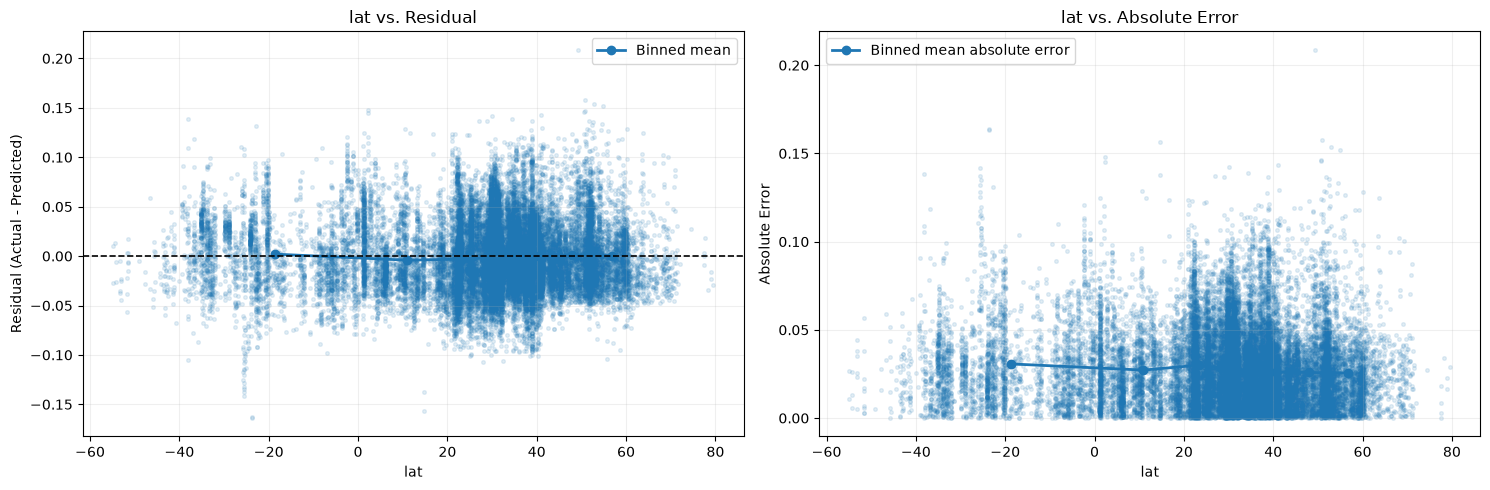

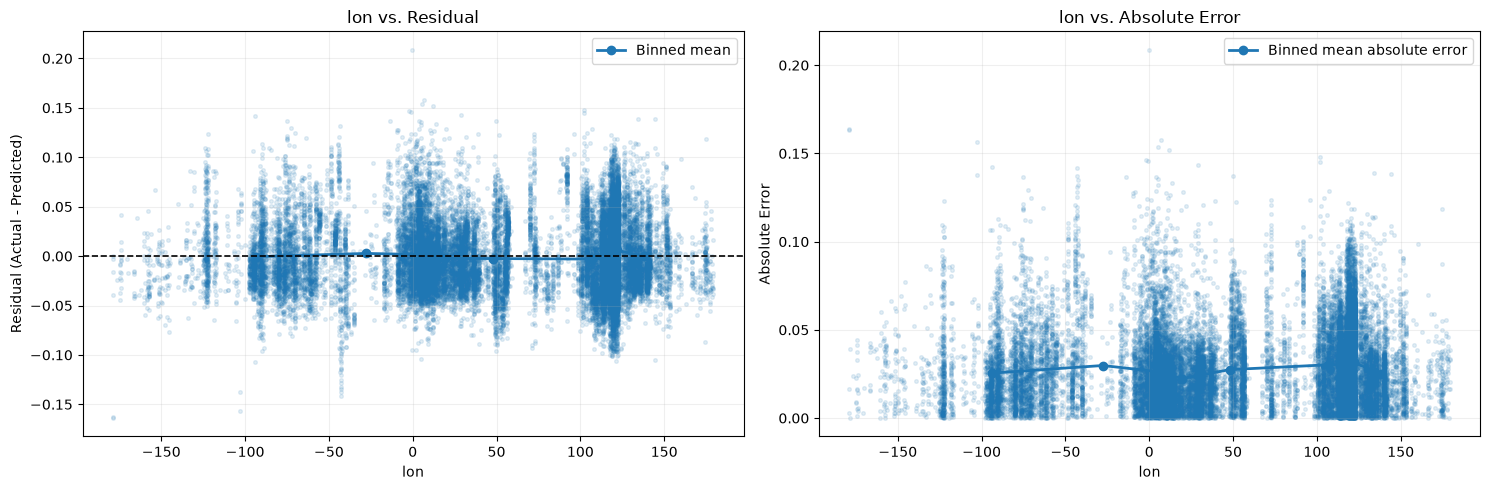

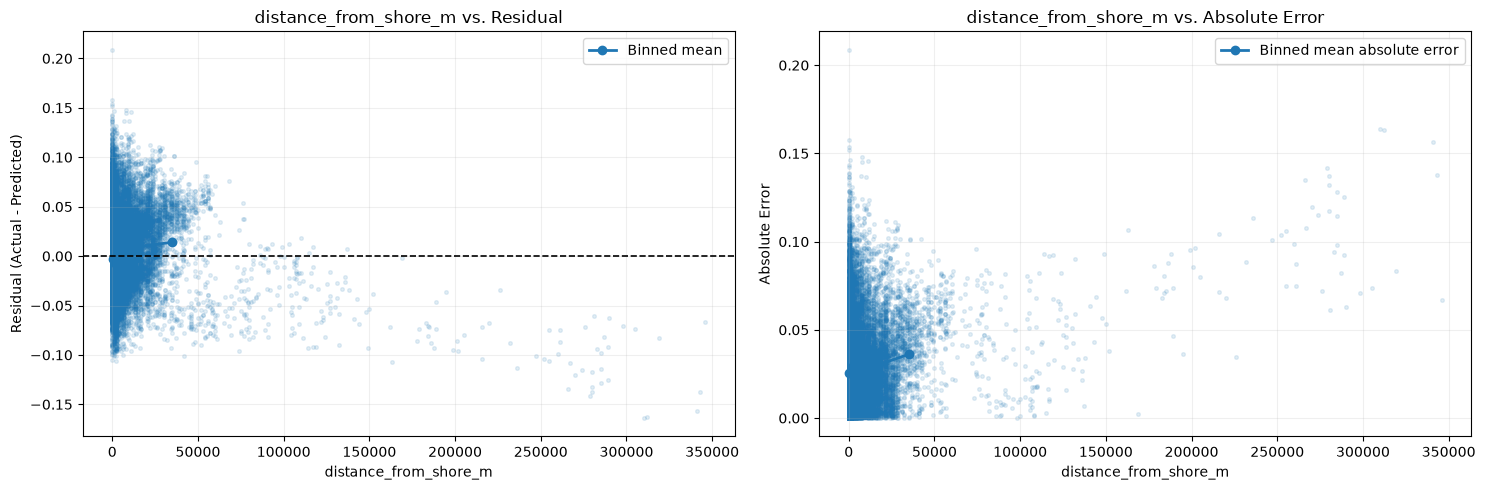

In [148]:
numeric_feature_summaries = {}

for feature in numeric_features:

    feature_data = analysis_df[
        [feature, "residual", "absolute_error"]
    ].dropna().copy()

    # Divide feature values into approximately equal-frequency groups
    feature_data["feature_bin"] = pd.qcut(
        feature_data[feature],
        q=10,
        duplicates="drop"
    )

    trend = (
        feature_data
        .groupby("feature_bin", observed=True)
        .agg(
            observations=("residual", "size"),
            mean_feature=(feature, "mean"),
            mean_residual=("residual", "mean"),
            mean_absolute_error=("absolute_error", "mean")
        )
        .reset_index(drop=True)
    )

    numeric_feature_summaries[feature] = trend

    sample_data = plot_sample[
        [feature, "residual", "absolute_error"]
    ].dropna()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5)
    )

    # Feature vs residual
    axes[0].scatter(
        sample_data[feature],
        sample_data["residual"],
        alpha=0.12,
        s=7
    )

    axes[0].plot(
        trend["mean_feature"],
        trend["mean_residual"],
        marker="o",
        linewidth=2,
        label="Binned mean"
    )

    axes[0].axhline(
        y=0,
        color="black",
        linestyle="--",
        linewidth=1.2
    )

    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Residual (Actual - Predicted)")
    axes[0].set_title(f"{feature} vs. Residual")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    # Feature vs absolute error
    axes[1].scatter(
        sample_data[feature],
        sample_data["absolute_error"],
        alpha=0.12,
        s=7
    )

    axes[1].plot(
        trend["mean_feature"],
        trend["mean_absolute_error"],
        marker="o",
        linewidth=2,
        label="Binned mean absolute error"
    )

    axes[1].set_xlabel(feature)
    axes[1].set_ylabel("Absolute Error")
    axes[1].set_title(f"{feature} vs. Absolute Error")
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

#### Binned Numerical Error Analysis

The numerical features are divided into approximately equal-frequency regions.

For each region, the following quantities are calculated:

- number of observations
- mean feature value
- mean residual
- mean absolute error (MAE)

This provides quantitative support for the visual patterns and helps distinguish genuine feature-dependent behavior from random scatter.

In [149]:
for feature, summary in numeric_feature_summaries.items():

    print("\n" + "=" * 70)
    print(f"Feature: {feature}")
    print("=" * 70)

    display(
        summary.round(5)
    )


Feature: lat


,observations,mean_feature,mean_residual,mean_absolute_error
0,16633,-18.66943,0.00198,0.03070
1,16633,10.93714,-0.00414,0.02719
2,16633,23.34891,-0.00311,0.03000
3,16633,28.40423,-0.00180,0.02839
4,16633,30.77538,0.00638,0.03065
5,16632,33.69120,-0.00194,0.02608
6,16633,37.02337,0.00101,0.02759
7,16633,40.55845,-0.00030,0.02609
8,16633,47.99539,0.00147,0.02587
9,16633,56.79381,0.00045,0.02550



Feature: lon


,observations,mean_feature,mean_residual,mean_absolute_error
0,16633,-93.61678,-0.00058,0.02550
1,16633,-27.67820,0.00268,0.02980
2,16633,5.69225,0.00153,0.02624
3,16633,19.40604,-0.00231,0.02237
4,16633,47.87554,-0.00250,0.02745
5,16632,106.89975,-0.00303,0.03022
6,16633,116.75070,-0.00157,0.03029
7,16633,120.06733,0.00021,0.02969
8,16633,122.07021,0.00575,0.03156
9,16633,138.11779,-0.00017,0.02495



Feature: distance_from_shore_m


,observations,mean_feature,mean_residual,mean_absolute_error
0,87412,210.95502,-0.00249,0.02583
1,15527,2000.00000,-0.00767,0.02887
2,14996,3420.91224,-0.00551,0.02759
3,16858,6320.67861,0.00380,0.02906
4,16033,11927.77397,0.00858,0.02831
5,15479,35136.18451,0.01409,0.03622


#### Categorical Features and Hidden Subpopulations

Categorical features cannot be interpreted using a continuous scatter plot in the same way as numerical features.

Instead, the mean residual and mean absolute error are calculated for each category.

Differences between categories may reveal hidden subpopulations in which the regression model behaves differently or has systematically higher prediction errors.

In [150]:
dock_summary = (
    analysis_df
    .assign(
        dock_group=analysis_df["dock"].fillna("Missing").astype(str)
    )
    .groupby("dock_group")
    .agg(
        observations=("residual", "size"),
        mean_residual=("residual", "mean"),
        MAE=("absolute_error", "mean")
    )
    .sort_values("MAE", ascending=False)
)

dock_summary.round(5)

,observations,mean_residual,MAE
dock_group,,,
False,87909,0.00006,0.03042
True,78420,-0.00007,0.02488


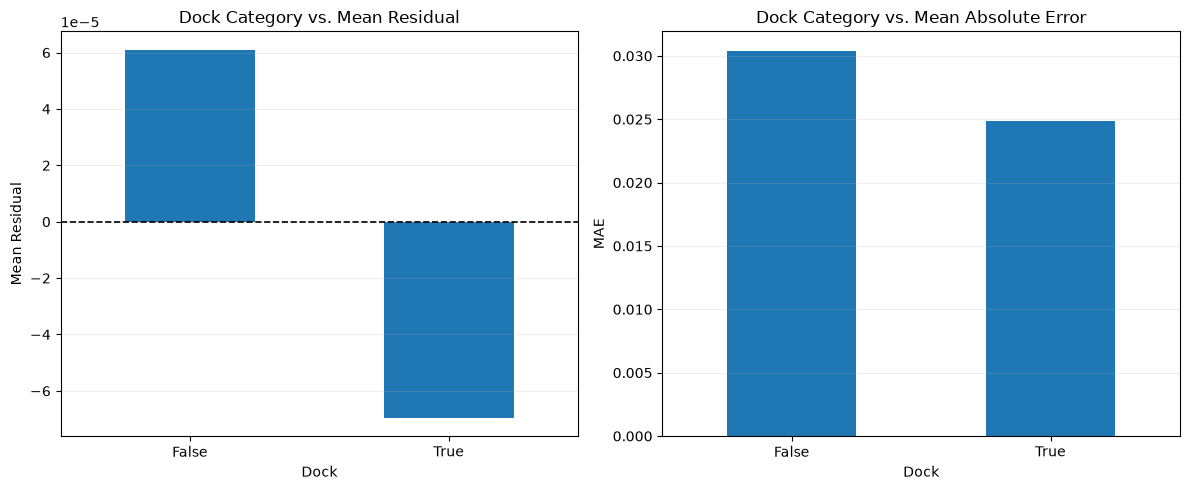

In [151]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

dock_summary["mean_residual"].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.2
)

axes[0].set_title("Dock Category vs. Mean Residual")
axes[0].set_xlabel("Dock")
axes[0].set_ylabel("Mean Residual")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.2)


dock_summary["MAE"].plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Dock Category vs. Mean Absolute Error")
axes[1].set_xlabel("Dock")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [152]:
label_source_summary = (
    analysis_df
    .groupby("label_source")
    .agg(
        observations=("residual", "size"),
        mean_residual=("residual", "mean"),
        MAE=("absolute_error", "mean")
    )
    .sort_values("MAE", ascending=False)
)

label_source_summary.round(5)

,observations,mean_residual,MAE
label_source,,,
anchorage_overrides,126180,0.00070,0.02826
top_destination,19077,-0.00296,0.02814
geonames_1000,7675,-0.00135,0.02498
WPI_ports,13314,-0.00163,0.02468
indonesia,74,0.00373,0.02350
peru,9,-0.00369,0.02059


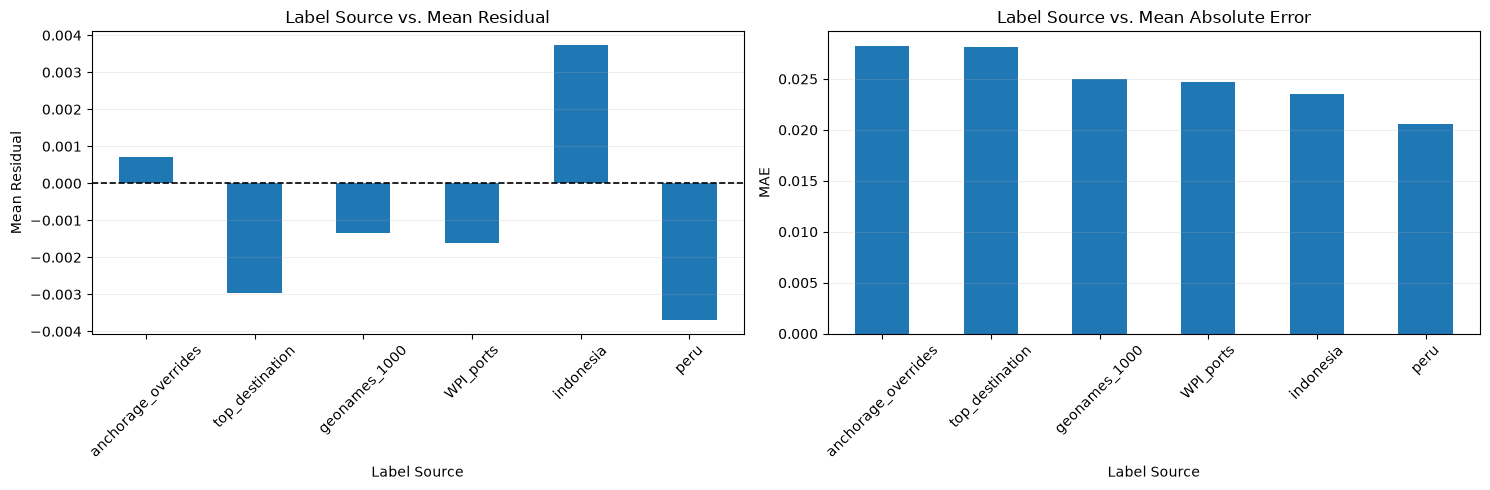

In [153]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

label_source_summary["mean_residual"].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.2
)

axes[0].set_title("Label Source vs. Mean Residual")
axes[0].set_xlabel("Label Source")
axes[0].set_ylabel("Mean Residual")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.2)


label_source_summary["MAE"].plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Label Source vs. Mean Absolute Error")
axes[1].set_xlabel("Label Source")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

#### Geographic Subpopulation Analysis

The `iso3` feature contains a large number of geographic categories.

Displaying every country simultaneously would make the visualization difficult to interpret and would also give excessive importance to categories represented by only a few observations.

Therefore, only countries containing at least **100 observations** are considered, and the 15 countries with the highest MAE are displayed.

This minimum-sample criterion reduces the likelihood that unusually large errors are caused only by very small sample sizes.

In [154]:
country_summary = (
    analysis_df
    .groupby("iso3")
    .agg(
        observations=("residual", "size"),
        mean_residual=("residual", "mean"),
        MAE=("absolute_error", "mean")
    )
)

country_summary = country_summary[
    country_summary["observations"] >= 100
].copy()

country_summary["MAE_ratio_vs_overall"] = (
    country_summary["MAE"]
    / analysis_df["absolute_error"].mean()
)

top_error_countries = (
    country_summary
    .sort_values("MAE", ascending=False)
    .head(15)
)

top_error_countries.round(5)

,observations,mean_residual,MAE,MAE_ratio_vs_overall
iso3,,,,
BGD,469,0.07127,0.07343,2.64081
GIN,113,0.04703,0.05327,1.91564
CMR,146,0.03377,0.05301,1.90638
GAB,105,0.01171,0.04031,1.44979
IRQ,353,0.02808,0.03969,1.42733
BRA,3347,0.00425,0.03950,1.42047
TKM,200,-0.03882,0.03892,1.39955
QAT,482,0.00552,0.03809,1.36988
MOZ,184,0.02509,0.03763,1.35339


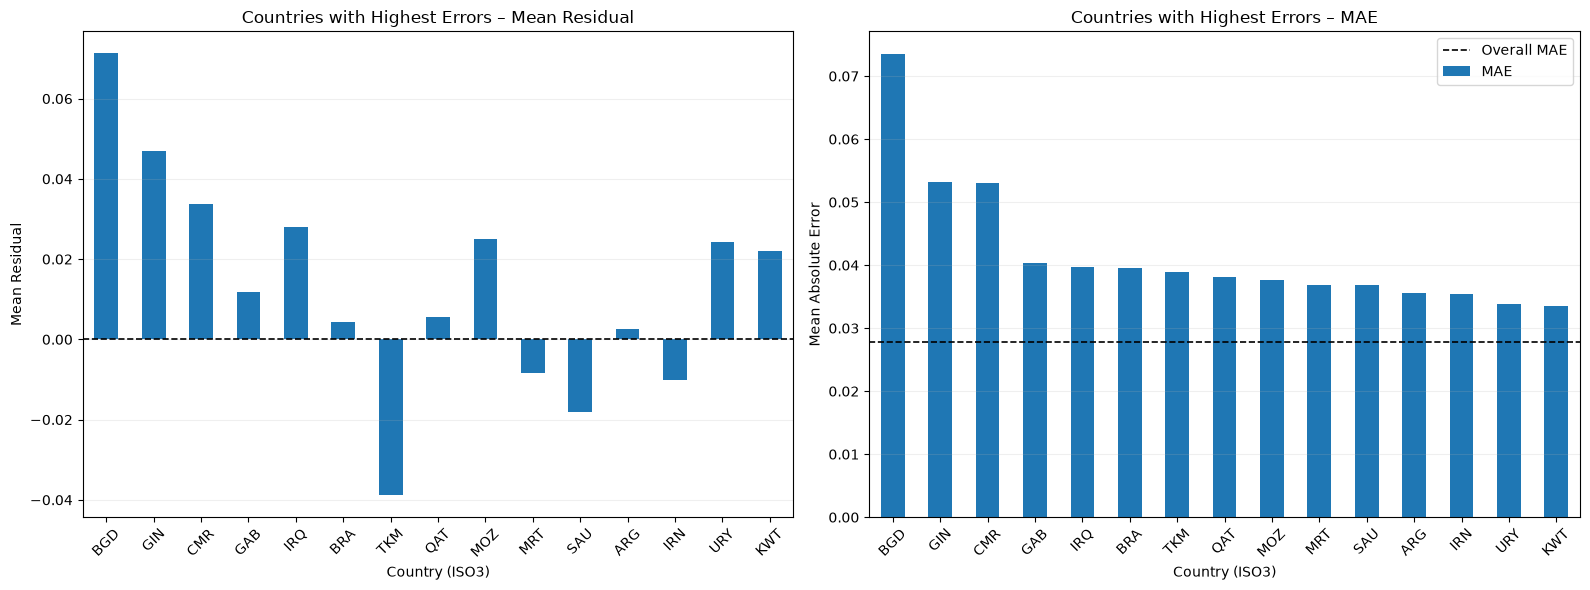

In [155]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

top_error_countries["mean_residual"].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.2
)

axes[0].set_title(
    "Countries with Highest Errors – Mean Residual"
)

axes[0].set_xlabel("Country (ISO3)")
axes[0].set_ylabel("Mean Residual")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.2)


top_error_countries["MAE"].plot(
    kind="bar",
    ax=axes[1]
)

axes[1].axhline(
    y=analysis_df["absolute_error"].mean(),
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Overall MAE"
)

axes[1].set_title(
    "Countries with Highest Errors – MAE"
)

axes[1].set_xlabel("Country (ISO3)")
axes[1].set_ylabel("Mean Absolute Error")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

#### Interpretation

The feature-based error analysis reveals that the regression errors are not distributed uniformly across the feature space.

**Latitude (`lat`)**

The relationship between latitude and prediction error is not monotonic. Both the mean residual and MAE vary across latitude regions rather than increasing or decreasing consistently.

The MAE across latitude groups is approximately between 0.025 and 0.031. This indicates that geographic latitude affects model accuracy, but the relationship is more complex than a simple linear trend.

This behavior suggests the presence of location-dependent effects that are not fully captured by the linear regression model.


**Longitude (`lon`)**

Longitude also exhibits a non-linear error pattern.

Different longitude regions show noticeably different residual means and absolute errors. The MAE varies from approximately 0.022 in some regions to more than 0.031 in others.

Because the error does not change monotonically with longitude, this is evidence that longitude is acting partly as a proxy for different geographic subpopulations rather than having a simple linear relationship with the target.


**Distance from shore (`distance_from_shore_m`)**

Distance from shore shows the clearest feature-dependent error pattern.

At relatively small and medium distances, the MAE is generally around 0.026–0.029. In the most distant group, however, the MAE increases to approximately 0.036.

The mean residual in this group is also positive, approximately 0.014, meaning that the actual drift radius tends to be larger than predicted for anchorages located far from shore.

This suggests that the linear model systematically underestimates `drift_radius` for some distant anchorages.

The relationship therefore appears to contain non-linearity or interactions that are not fully represented by the current linear model.


**Dock status**

A clear difference is also observed between dock and non-dock observations.

Non-dock observations have an MAE of approximately 0.030, while dock observations have an MAE of approximately 0.025.

Therefore, prediction error for non-dock observations is roughly 22% higher than for dock observations.

This indicates that dock status defines a meaningful subpopulation with different prediction difficulty.


**Label source**

The error also varies across `label_source` categories, although the differences are smaller than those observed for some geographic groups.

This suggests that the source or construction of the observations may influence prediction quality and may represent another source of data heterogeneity.


**Geographic subpopulations**

The strongest evidence of hidden subpopulations is found when observations are grouped by country.

Several countries have substantially higher prediction errors than the overall dataset. For example, among countries containing at least 100 observations, Bangladesh (`BGD`) has an MAE of approximately 0.073, more than 2.6 times the overall MAE of approximately 0.028.

Guinea (`GIN`) and Cameroon (`CMR`) also show substantially elevated errors.

These results indicate that geographic regions contain different relationships between the available features and `drift_radius`. Possible explanations include local anchorage characteristics, missing explanatory variables, differences in data composition, or nonlinear interactions that cannot be fully represented by the Linear Regression model.


#### Conclusion

The analysis provides evidence of all three behaviors targeted in this section:

1. **Non-linear relationships:** latitude, longitude, and distance from shore do not show purely linear error behavior.
2. **Feature-dependent error patterns:** prediction accuracy changes noticeably across feature values, especially for distance from shore.
3. **Hidden subpopulations:** dock status and geographic country groups show clearly different levels of prediction error.

Therefore, the model's errors are not purely random. Part of the remaining prediction error is systematically related to the feature space, suggesting that a more flexible non-linear model may capture relationships that the baseline Linear Regression model cannot fully represent.

### 1.3 Analysis of Extreme Errors

This section focuses on the observations with the largest prediction errors.

The **top 5% largest absolute errors** are identified using the 95th percentile of the absolute-error distribution.

These observations are then examined individually and collectively in order to determine whether the extreme errors are primarily associated with:

- data quality issues,
- limitations of the Linear Regression model,
- rare or exceptional observations.

Because the predictions were generated using k-fold cross-validation, the extreme errors represent out-of-fold prediction failures rather than errors measured on observations used to train their predicting model.

In [156]:
extreme_error_threshold = analysis_df["absolute_error"].quantile(0.95)

extreme_errors = (
    analysis_df[
        analysis_df["absolute_error"] >= extreme_error_threshold
    ]
    .copy()
    .sort_values("absolute_error", ascending=False)
)

print(f"95th percentile absolute-error threshold: {extreme_error_threshold:.6f}")
print(f"Number of extreme-error observations: {len(extreme_errors):,}")
print(
    f"Percentage of observations: "
    f"{100 * len(extreme_errors) / len(analysis_df):.3f}%"
)

95th percentile absolute-error threshold: 0.068943
Number of extreme-error observations: 8,317
Percentage of observations: 5.000%


#### Definition of an Extreme Error

An observation is considered an extreme-error case when its absolute residual is at or above the 95th percentile of all absolute residuals.

For this dataset, this produces approximately 8,317 observations, corresponding to 5% of the regression dataset.

The threshold-based definition is preferable to manually selecting a fixed error value because it adapts directly to the observed error distribution.

In [157]:
extreme_error_summary = pd.Series({
    "Overall MAE":
        analysis_df["absolute_error"].mean(),

    "Extreme-error MAE":
        extreme_errors["absolute_error"].mean(),

    "Extreme-error median absolute error":
        extreme_errors["absolute_error"].median(),

    "Minimum extreme absolute error":
        extreme_errors["absolute_error"].min(),

    "Maximum extreme absolute error":
        extreme_errors["absolute_error"].max(),

    "Mean residual among extreme errors":
        extreme_errors["residual"].mean(),

    "Underpredictions among extreme errors (%)":
        (extreme_errors["residual"] > 0).mean() * 100,

    "Overpredictions among extreme errors (%)":
        (extreme_errors["residual"] < 0).mean() * 100
})

extreme_error_summary.round(6)

Overall MAE                                   0.027807
Extreme-error MAE                             0.085325
Extreme-error median absolute error           0.081399
Minimum extreme absolute error                0.068943
Maximum extreme absolute error                0.208757
Mean residual among extreme errors            0.043687
Underpredictions among extreme errors (%)    74.449922
Overpredictions among extreme errors (%)     25.550078
dtype: float64

#### Individual Inspection of the Largest Errors

The observations with the largest absolute errors are inspected individually.

For each case, the table includes the actual target, predicted value, signed residual, absolute error, geographic information, distance from shore, and dock status.

The direction of the error is also reported:

- **Underprediction:** the actual value is larger than the prediction.
- **Overprediction:** the predicted value is larger than the actual value.

This individual inspection helps distinguish between unusual observations and systematic model failures.

In [158]:
extreme_errors["error_direction"] = np.where(
    extreme_errors["residual"] > 0,
    "Underprediction",
    "Overprediction"
)

individual_columns = [
    "s2id",
    "label",
    "sublabel",
    "iso3",
    "lat",
    "lon",
    "distance_from_shore_m",
    "dock",
    target,
    "predicted",
    "residual",
    "absolute_error",
    "error_direction"
]

top_extreme_cases = extreme_errors[
    individual_columns
].head(20)

with pd.option_context(
    "display.max_columns", None,
    "display.width", None
):
    display(top_extreme_cases.round(6))

,s2id,label,sublabel,iso3,lat,lon,distance_from_shore_m,dock,drift_radius,predicted,residual,absolute_error,error_direction
99863,480a6405,OUISTREHAM,OUISTREHAM,FRA,49.275232,-0.250462,0.0,True,0.280023,0.071266,0.208757,0.208757,Underprediction
95209,47b18515,HAMBURG,HAMBURG,DEU,53.523547,9.892439,0.0,True,0.260156,0.069431,0.190725,0.190725,Underprediction
35398,71426205,COK-1,BDOCKX00030,COK,-18.046874,-163.192481,368000.0,False,0.046954,0.231554,-0.184601,0.184601,Overprediction
7121,31d20305,FORTUNE STAR,LINGGI,MYS,2.283052,102.016588,7000.0,False,0.297781,0.118996,0.178785,0.178785,Underprediction
108223,60229b67,CHIBA,CHIBA,JPN,35.580521,140.108069,0.0,True,0.235382,0.056651,0.178731,0.178731,Underprediction
40244,7201642d,FJI-1,WHANGAREI,FJI,-23.656359,-178.900413,311000.0,False,0.042601,0.212997,-0.170396,0.170396,Overprediction
8329,46f579a9,BULLANDOE,HOLO,SWE,59.295842,18.654511,0.0,True,0.239716,0.070860,0.168856,0.168856,Underprediction
128259,880e2b57,CHICAGO,CHICAGO,USA,41.889463,-87.615317,0.0,True,0.237256,0.072861,0.164395,0.164395,Underprediction
40288,7201644f,FJI-54,BURG,FJI,-23.631220,-178.895699,310000.0,False,0.051104,0.215008,-0.163904,0.163904,Overprediction
40243,720165d5,FJI-1,NADI FIJI,FJI,-23.659687,-178.905560,312000.0,False,0.052540,0.215663,-0.163123,0.163123,Overprediction


#### Examples of Individual Extreme Errors

Inspection of the largest individual errors reveals several different failure patterns.

**OUISTREHAM (France)** is one of the largest underprediction cases. Its actual `drift_radius` is approximately 0.280, while the model predicts only about 0.071. The residual is therefore approximately +0.209. The observation is located at the shore (`distance_from_shore_m = 0`) and is classified as a dock. The available features therefore do not explain why its drift radius is so much larger than the typical prediction for similar observations.

**HAMBURG (Germany)** shows a similar pattern. Its actual drift radius is approximately 0.260, compared with a prediction of approximately 0.069. This produces an extreme underprediction of approximately 0.191.

In contrast, **COK-1 (Cook Islands)** represents an extreme overprediction. Its actual drift radius is only approximately 0.047, while the model predicts approximately 0.232. This observation is located approximately 368 km from shore, an unusually large distance. The linear model appears to extrapolate strongly from the distance-related relationship and substantially overestimates the target.

Several **Fiji (`FJI`) observations** exhibit a similar pattern: extremely large distances from shore, relatively small actual drift radii, and predictions above 0.20. These cases suggest that the linear relationship learned for `distance_from_shore_m` does not remain valid in extreme geographic regions.

**FORTUNE STAR (Malaysia)** represents another type of exceptional case. Its actual drift radius is approximately 0.298, close to the maximum observed target value, while the prediction is only approximately 0.119. This indicates difficulty predicting observations located in the extreme upper tail of the target distribution.

Overall, the individual cases show both severe underprediction of unusually large drift radii and severe overprediction in unusual geographic conditions.

#### Actual vs. Predicted Values for Extreme Errors

The following visualization compares actual and predicted target values.

The diagonal line represents perfect prediction (`actual = predicted`). Extreme-error observations are highlighted to show how far they deviate from ideal predictions.

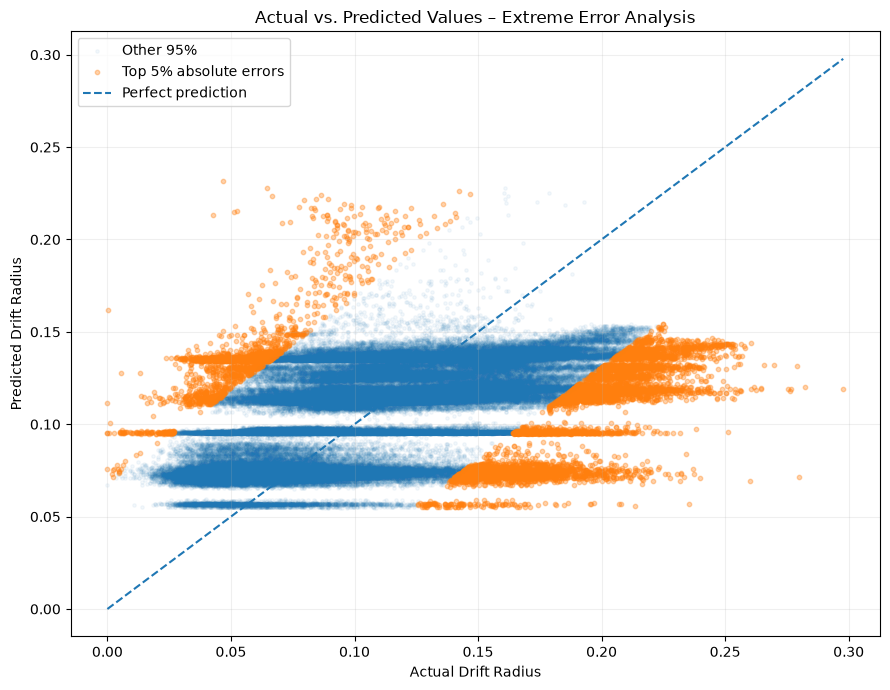

In [159]:
normal_errors = analysis_df[
    analysis_df["absolute_error"] < extreme_error_threshold
]

plt.figure(figsize=(9, 7))

plt.scatter(
    normal_errors[target],
    normal_errors["predicted"],
    alpha=0.05,
    s=6,
    label="Other 95%"
)

plt.scatter(
    extreme_errors[target],
    extreme_errors["predicted"],
    alpha=0.35,
    s=10,
    label="Top 5% absolute errors"
)

min_value = min(
    analysis_df[target].min(),
    analysis_df["predicted"].min()
)

max_value = max(
    analysis_df[target].max(),
    analysis_df["predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1.5,
    label="Perfect prediction"
)

plt.xlabel("Actual Drift Radius")
plt.ylabel("Predicted Drift Radius")
plt.title("Actual vs. Predicted Values – Extreme Error Analysis")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### Data Quality Investigation

Extreme prediction errors do not necessarily indicate a model failure. They may also be caused by poor-quality or invalid data.

Several basic data-quality checks are therefore performed on both the complete regression dataset and the extreme-error subset.

The checks include:

- missing values in the selected predictive features,
- duplicate identifiers,
- invalid latitude or longitude values,
- negative distances from shore,
- negative target values.

In [160]:
selected_features = numeric_features + categorical_features

quality_checks = pd.DataFrame({
    "Check": [
        "Rows with missing selected features",
        "Duplicate s2id values",
        "Latitude outside [-90, 90]",
        "Longitude outside [-180, 180]",
        "Negative distance_from_shore_m",
        "Negative drift_radius"
    ],

    "All regression observations": [
        analysis_df[selected_features].isna().any(axis=1).sum(),

        analysis_df["s2id"].duplicated().sum(),

        (
            (analysis_df["lat"] < -90)
            | (analysis_df["lat"] > 90)
        ).sum(),

        (
            (analysis_df["lon"] < -180)
            | (analysis_df["lon"] > 180)
        ).sum(),

        (
            analysis_df["distance_from_shore_m"] < 0
        ).sum(),

        (
            analysis_df[target] < 0
        ).sum()
    ],

    "Top 5% extreme errors": [
        extreme_errors[selected_features]
        .isna()
        .any(axis=1)
        .sum(),

        extreme_errors["s2id"].duplicated().sum(),

        (
            (extreme_errors["lat"] < -90)
            | (extreme_errors["lat"] > 90)
        ).sum(),

        (
            (extreme_errors["lon"] < -180)
            | (extreme_errors["lon"] > 180)
        ).sum(),

        (
            extreme_errors["distance_from_shore_m"] < 0
        ).sum(),

        (
            extreme_errors[target] < 0
        ).sum()
    ]
})

quality_checks

,Check,All regression observations,Top 5% extreme errors
0,Rows with missing selected features,24,2
1,Duplicate s2id values,0,0
2,"Latitude outside [-90, 90]",0,0
3,"Longitude outside [-180, 180]",0,0
4,Negative distance_from_shore_m,0,0
5,Negative drift_radius,0,0


#### Data Quality Interpretation

The basic data-quality checks do not provide strong evidence that data corruption is the primary explanation for the extreme errors.

There are no duplicated `s2id` identifiers, no invalid latitude or longitude values, and no negative values for either `distance_from_shore_m` or the regression target.

Only a very small number of observations contain missing values in the selected predictive features, and missing features are not concentrated strongly enough in the extreme-error subset to explain the large number of extreme prediction failures.

Therefore, the observed extreme errors cannot primarily be attributed to obvious data-quality problems.

However, these checks cannot rule out more subtle quality issues, such as inaccurate measurements or missing explanatory information that is not represented in the dataset.

#### Rare and Exceptional Cases

To determine whether extreme prediction errors are associated with rare observations, the extreme-error subset is compared with the tails of the target and feature distributions.

Particular attention is given to:

- unusually high or low `drift_radius` values,
- unusually large distances from shore.

If these rare regions are strongly overrepresented among the largest errors, this suggests that the model has difficulty generalizing to exceptional cases.

In [161]:
target_q05 = analysis_df[target].quantile(0.05)
target_q95 = analysis_df[target].quantile(0.95)
target_q99 = analysis_df[target].quantile(0.99)

distance_q95 = analysis_df[
    "distance_from_shore_m"
].quantile(0.95)

distance_q99 = analysis_df[
    "distance_from_shore_m"
].quantile(0.99)

rare_case_summary = pd.Series({
    "Mean target - complete dataset":
        analysis_df[target].mean(),

    "Mean target - extreme errors":
        extreme_errors[target].mean(),

    "Extreme errors in top 5% of target (%)":
        (
            extreme_errors[target] >= target_q95
        ).mean() * 100,

    "Extreme errors in top 1% of target (%)":
        (
            extreme_errors[target] >= target_q99
        ).mean() * 100,

    "Extreme errors in bottom 5% of target (%)":
        (
            extreme_errors[target] <= target_q05
        ).mean() * 100,

    "Extreme errors in top 5% distance from shore (%)":
        (
            extreme_errors["distance_from_shore_m"]
            >= distance_q95
        ).mean() * 100,

    "Extreme errors in top 1% distance from shore (%)":
        (
            extreme_errors["distance_from_shore_m"]
            >= distance_q99
        ).mean() * 100
})

rare_case_summary.round(5)

Mean target - complete dataset                       0.10394
Mean target - extreme errors                         0.15545
Extreme errors in top 5% of target (%)              45.89395
Extreme errors in top 1% of target (%)              18.34796
Extreme errors in bottom 5% of target (%)            6.02381
Extreme errors in top 5% distance from shore (%)    11.72298
Extreme errors in top 1% distance from shore (%)     5.15811
dtype: float64

#### Evidence of Model Limitations

If extreme errors were caused primarily by random noise, severe underprediction and overprediction would be expected to occur more symmetrically.

Instead, the direction of the extreme errors and their concentration in particular regions of the target and feature space can provide evidence of systematic model limitations.

The extreme-error rate is also examined across geographic subpopulations to determine whether the Linear Regression model fails disproportionately in certain regions.

In [162]:
country_all_counts = (
    analysis_df
    .groupby("iso3")
    .size()
    .rename("total_observations")
)

country_extreme_counts = (
    extreme_errors
    .groupby("iso3")
    .size()
    .rename("extreme_errors")
)

country_extreme_analysis = pd.concat(
    [
        country_all_counts,
        country_extreme_counts
    ],
    axis=1
).fillna(0)

country_extreme_analysis["extreme_error_rate_%"] = (
    country_extreme_analysis["extreme_errors"]
    / country_extreme_analysis["total_observations"]
    * 100
)

country_extreme_analysis = (
    country_extreme_analysis[
        country_extreme_analysis["total_observations"] >= 100
    ]
    .sort_values(
        "extreme_error_rate_%",
        ascending=False
    )
)

country_extreme_analysis.head(10).round(3)

,total_observations,extreme_errors,extreme_error_rate_%
iso3,,,
BGD,469,313.0,66.738
CMR,146,60.0,41.096
GIN,113,43.0,38.053
IRQ,353,72.0,20.397
BRA,3347,615.0,18.375
CAN,1628,171.0,10.504
IRL,249,26.0,10.442
ECU,261,24.0,9.195
IND,2303,210.0,9.119


#### Discussion

The analysis indicates that the extreme prediction errors arise primarily from a combination of **model limitations** and **rare or exceptional cases**, rather than from obvious data-quality problems.


**1. Data quality issues**

The basic quality checks provide little evidence that corrupted or invalid data are the primary source of the extreme errors.

No invalid geographic coordinates, negative target values, negative distances, or duplicated identifiers were detected. Missing values in the selected predictive features are also extremely rare and are not sufficiently concentrated among the extreme-error observations to explain the observed failures.

Therefore, obvious data-quality problems do not appear to be the dominant cause.

More subtle measurement errors or omitted information cannot be ruled out, but they cannot be established from the available data alone.


**2. Model limitations**

There is strong evidence that the Linear Regression model contributes to the extreme errors.

Approximately 74% of the extreme errors are positive residuals, meaning that the model substantially underpredicts far more often than it substantially overpredicts.

The individual observations also reveal systematic failure patterns. Large drift-radius observations such as OUISTREHAM, HAMBURG, and FORTUNE STAR are severely underpredicted, while several extremely distant offshore observations are strongly overpredicted.

This behavior is consistent with the results of Section 1.2, where feature-dependent and nonlinear error patterns were observed.

A single linear relationship therefore appears insufficient to describe all geographic regions and anchorage conditions represented in the dataset.


**3. Rare or exceptional cases**

Rare cases are strongly overrepresented among the extreme errors.

The mean `drift_radius` of the extreme-error subset is approximately 0.155, compared with approximately 0.104 for the complete dataset.

Most importantly, approximately 46% of the extreme-error observations belong to the highest 5% of the `drift_radius` distribution, and approximately 18% belong to the highest 1%.

Unusually distant observations are also overrepresented. Approximately 11.7% of the extreme-error observations are located in the highest 5% of `distance_from_shore_m`, and more than 5% belong to its highest 1%.

This indicates that the model performs particularly poorly when predicting observations located in unusual regions of the feature or target space.


**4. Geographic concentration of failures**

Extreme errors are also highly concentrated in certain geographic subpopulations.

For example, among countries with at least 100 observations, approximately 67% of the observations from Bangladesh (`BGD`) belong to the global top 5% of absolute prediction errors. Cameroon (`CMR`) and Guinea (`GIN`) also show very high extreme-error rates.

This provides additional evidence that relationships differ between geographic regions and that important regional information or interactions may not be fully captured by the current Linear Regression model.


#### Conclusion

The extreme errors cannot be explained by a single cause.

The available evidence suggests:

- **Data quality:** not a major observable cause.
- **Model limitations:** a major contributor.
- **Rare or exceptional cases:** a major contributor.

The strongest pattern is the model's difficulty with unusually large target values, extreme geographic conditions, and specific geographic subpopulations.

These findings suggest that more flexible nonlinear models, such as Decision Trees or ensemble methods, may be able to capture relationships that the baseline Linear Regression model cannot represent.

### 1.4 Statistical Properties of Errors

This section examines the statistical properties of the regression errors generated by the 5-fold cross-validation procedure.

The following measures are calculated:

- **Mean Absolute Error (MAE):** the average magnitude of the prediction errors, regardless of direction.
- **Standard deviation of residuals:** measures how widely the signed prediction errors are dispersed around their mean.
- **Skewness:** measures asymmetry in the residual distribution.
- **Kurtosis:** measures the extent to which the residual distribution contains heavier or lighter tails than a normal distribution.

For kurtosis, the reported value is **excess kurtosis**, for which a normal distribution has a value of 0.

In [163]:
mae = analysis_df["absolute_error"].mean()
residual_std = analysis_df["residual"].std()
residual_skewness = analysis_df["residual"].skew()
residual_kurtosis = analysis_df["residual"].kurt()

error_statistics = pd.DataFrame({
    "Statistic": [
        "Mean Absolute Error (MAE)",
        "Standard Deviation of Residuals",
        "Skewness",
        "Excess Kurtosis"
    ],
    "Value": [
        mae,
        residual_std,
        residual_skewness,
        residual_kurtosis
    ]
})

error_statistics["Value"] = error_statistics["Value"].round(6)

error_statistics

,Statistic,Value
0,Mean Absolute Error (MAE),0.027807
1,Standard Deviation of Residuals,0.034983
2,Skewness,0.474068
3,Excess Kurtosis,0.350899


#### Interpretation of the Statistical Error Properties

**Mean Absolute Error (MAE)**

The MAE is approximately **0.0278**.

This means that, on average, the Linear Regression model's prediction differs from the true `drift_radius` by approximately 0.028 units.

Because MAE is based on absolute errors, it measures the typical prediction-error magnitude without allowing positive and negative residuals to cancel each other.


**Standard deviation of residuals**

The standard deviation of the residuals is approximately **0.0350**.

This indicates that the signed prediction errors show a noticeable amount of dispersion around their mean.

The standard deviation is larger than the MAE because it is more sensitive to relatively large errors, which is consistent with the extreme-error observations identified in Section 1.3.


**Skewness**

The residual skewness is approximately **+0.474**.

A skewness value of zero would indicate a symmetric residual distribution. The positive value therefore indicates a **moderate right-skew**.

Since the residual is defined as:

`Residual = Actual - Predicted`

large positive residuals correspond to cases in which the model **underpredicts** the true target.

Therefore, the positive skewness indicates that the residual distribution contains a longer or stronger positive tail. This is consistent with the earlier extreme-error analysis, where large underpredictions were considerably more common than large overpredictions.

The result suggests a systematic asymmetry in the model's errors, particularly for observations with unusually large `drift_radius` values.


**Kurtosis**

The excess kurtosis is approximately **+0.351**.

Because a normal distribution has an excess kurtosis of 0, the positive value indicates that the residual distribution has somewhat heavier tails than a normal distribution.

However, the value is only moderately positive rather than extremely large. Therefore, the residual distribution shows evidence of heavier-than-normal tails, but not an exceptionally severe heavy-tail structure.

This result is consistent with the presence of a relatively small number of observations with unusually large prediction errors.

Such heavier tails indicate that occasional large errors occur more frequently than would be expected under an ideal normal-error assumption and may therefore reduce the stability of the Linear Regression model in unusual regions of the data.

In [164]:
residual_tail_summary = pd.Series({
    "1st percentile":
        analysis_df["residual"].quantile(0.01),

    "5th percentile":
        analysis_df["residual"].quantile(0.05),

    "Median":
        analysis_df["residual"].median(),

    "95th percentile":
        analysis_df["residual"].quantile(0.95),

    "99th percentile":
        analysis_df["residual"].quantile(0.99),

    "Minimum residual":
        analysis_df["residual"].min(),

    "Maximum residual":
        analysis_df["residual"].max()
})

residual_tail_summary.round(6)

1st percentile     -0.072126
5th percentile     -0.049973
Median             -0.004271
95th percentile     0.062730
99th percentile     0.093030
Minimum residual   -0.184601
Maximum residual    0.208757
dtype: float64

#### Conclusion

The statistical error analysis supports the patterns observed in the previous residual and extreme-error analyses.

The Linear Regression model has an MAE of approximately **0.0278** and a residual standard deviation of approximately **0.0350**.

The residual distribution is not perfectly symmetric. Its positive skewness of approximately **0.474** indicates a longer positive tail and therefore a greater tendency toward large underprediction errors than large overprediction errors.

The positive excess kurtosis of approximately **0.351** indicates moderately heavier tails than a normal distribution. This means that relatively large prediction errors occur somewhat more frequently than would be expected under a normal-error assumption.

Overall, the residuals show both **asymmetry and moderately heavy tails**. These statistical properties reinforce the earlier finding that the model does not fail uniformly: particular observations and subpopulations generate substantially larger errors than the majority of the dataset.

Therefore, while the baseline Linear Regression model performs reasonably for many observations, its error distribution suggests limitations in robustness when handling unusual or difficult cases.

## 2. Regression Models

The objective of this section is to implement and compare regression models with different modeling assumptions.

Three models are evaluated:

1. **Linear Regression** – a linear baseline model.
2. **Decision Tree Regressor** – a nonlinear model capable of learning thresholds and feature interactions.
3. **Random Forest Regressor** – an ensemble of decision trees designed to improve predictive performance and reduce the variance of a single tree.

For a fair comparison, all models use:

- the same regression target,
- the same feature set,
- the same preprocessing strategy,
- the same 5-fold cross-validation splits.

Model performance is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² score

Training and validation performance are both recorded in order to examine the bias–variance trade-off and possible overfitting.

In [165]:
from sklearn.base import clone

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import time

### 2.1 Model Configuration

The models are evaluated using explicitly specified hyperparameters.

**Linear Regression**

The standard Linear Regression model is used without additional regularization. It serves as the baseline and assumes that the target can be represented as a linear combination of the input features.

**Decision Tree Regressor**

The tree is limited to a maximum depth of 20, and each terminal leaf must contain at least 5 observations. These restrictions reduce the tendency of an unrestricted decision tree to memorize individual observations and strongly overfit the training data.

**Random Forest Regressor**

The ensemble contains 30 decision trees. Each tree uses a maximum depth of 20 and a minimum of 5 samples per leaf. At each split, 70% of the available features are considered.

Thirty trees are used as a practical balance between ensemble stability and computational cost because every model must be trained five times during cross-validation on a dataset containing more than 166,000 observations.

The hyperparameters are fixed before evaluation and are not selected using the validation folds. This avoids using the evaluation results themselves to optimize the models.

In [166]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=20,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=30,
        max_depth=20,
        min_samples_leaf=5,
        max_features=0.7,
        random_state=42,
        n_jobs=-1
    )
}

models

{'Linear Regression': LinearRegression(),
 'Decision Tree': DecisionTreeRegressor(max_depth=20, min_samples_leaf=5, random_state=42),
 'Random Forest': RandomForestRegressor(max_depth=20, max_features=0.7, min_samples_leaf=5,
                       n_estimators=30, n_jobs=-1, random_state=42)}

### 2.2 Cross-Validation Evaluation Strategy

The same **5-fold cross-validation** configuration from Section 1 is used for every model.

For each fold:

1. Four folds are used for training.
2. The remaining fold is used for validation.
3. The complete preprocessing pipeline is fitted only on the training portion.
4. Predictions are generated for both the training and validation portions.
5. MAE, MSE, RMSE, and R² are calculated.

The validation predictions from all five folds are also stored as out-of-fold predictions.

This design provides two complementary forms of information:

- **Validation performance** measures generalization to unseen observations.
- **Training versus validation performance** helps identify underfitting and overfitting.

Using exactly the same folds for all three models ensures that their performance is directly comparable.

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# --------------------------------------------------
# Load dataset
# --------------------------------------------------

df = pd.read_csv(
    "data/named_anchorages_v2_20221206.csv",
    low_memory=False
)

# --------------------------------------------------
# Target and features
# --------------------------------------------------

target = "drift_radius"

numeric_features = [
    "lat",
    "lon",
    "distance_from_shore_m"
]

categorical_features = [
    "dock",
    "iso3",
    "label_source"
]

features = numeric_features + categorical_features

# Remove observations with a missing regression target
reg_df = (
    df
    .dropna(subset=[target])
    .copy()
    .reset_index(drop=True)
)

X = reg_df[features]
y = reg_df[target]

# --------------------------------------------------
# Preprocessing
# --------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

# --------------------------------------------------
# 5-fold cross-validation
# --------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# --------------------------------------------------
# Regression models
# --------------------------------------------------

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=20,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=30,
        max_depth=20,
        min_samples_leaf=5,
        max_features=0.7,
        random_state=42,
        n_jobs=-1
    )
}

print("Section 2 setup completed successfully.")
print("Regression observations:", len(reg_df))
print("Models:", list(models.keys()))

Section 2 setup completed successfully.
Regression observations: 166329
Models: ['Linear Regression', 'Decision Tree', 'Random Forest']


In [168]:
fold_results = []

oof_predictions = {
    model_name: np.full(len(y), np.nan)
    for model_name in models
}

for model_name, model in models.items():

    print(f"\nStarting: {model_name}")
    start_time = time.time()

    for fold_number, (train_idx, val_idx) in enumerate(
        cv.split(X, y),
        start=1
    ):

        model_pipeline = Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                ("model", clone(model))
            ]
        )

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model_pipeline.fit(X_train, y_train)

        train_pred = model_pipeline.predict(X_train)
        val_pred = model_pipeline.predict(X_val)

        oof_predictions[model_name][val_idx] = val_pred

        train_mse = mean_squared_error(y_train, train_pred)

        fold_results.append({
            "Model": model_name,
            "Fold": fold_number,
            "Split": "Train",
            "MAE": mean_absolute_error(y_train, train_pred),
            "MSE": train_mse,
            "RMSE": np.sqrt(train_mse),
            "R2": r2_score(y_train, train_pred)
        })

        val_mse = mean_squared_error(y_val, val_pred)

        fold_results.append({
            "Model": model_name,
            "Fold": fold_number,
            "Split": "Validation",
            "MAE": mean_absolute_error(y_val, val_pred),
            "MSE": val_mse,
            "RMSE": np.sqrt(val_mse),
            "R2": r2_score(y_val, val_pred)
        })

        print(f"  Fold {fold_number}/5 completed")

    elapsed = time.time() - start_time

    print(
        f"{model_name} completed in "
        f"{elapsed:.1f} seconds."
    )

results_df = pd.DataFrame(fold_results)

print("\nAll models completed.")


Starting: Linear Regression
  Fold 1/5 completed
  Fold 2/5 completed
  Fold 3/5 completed
  Fold 4/5 completed
  Fold 5/5 completed
Linear Regression completed in 1.1 seconds.

Starting: Decision Tree
  Fold 1/5 completed
  Fold 2/5 completed
  Fold 3/5 completed
  Fold 4/5 completed
  Fold 5/5 completed
Decision Tree completed in 20.8 seconds.

Starting: Random Forest
  Fold 1/5 completed
  Fold 2/5 completed
  Fold 3/5 completed
  Fold 4/5 completed
  Fold 5/5 completed
Random Forest completed in 39.0 seconds.

All models completed.


### 2.3 Fold-Level Performance

The following table presents the performance of every model separately for each cross-validation fold.

Consistency across folds is important. A model that performs extremely well on some folds but poorly on others may be less stable than a model whose performance is consistently strong.

In [169]:
validation_fold_results = (
    results_df[
        results_df["Split"] == "Validation"
    ]
    .copy()
)

display(
    validation_fold_results.round(6)
)

,Model,Fold,Split,MAE,MSE,RMSE,R2
1,Linear Regression,1,Validation,0.027806,0.001226,0.035020,0.348374
3,Linear Regression,2,Validation,0.027903,0.001229,0.035064,0.340841
5,Linear Regression,3,Validation,0.027763,0.001219,0.034917,0.350758
7,Linear Regression,4,Validation,0.027806,0.001223,0.034975,0.347986
9,Linear Regression,5,Validation,0.027758,0.001221,0.034939,0.346382
11,Decision Tree,1,Validation,0.018791,0.000699,0.026432,0.628788
13,Decision Tree,2,Validation,0.018732,0.000700,0.026456,0.624743
15,Decision Tree,3,Validation,0.018426,0.000675,0.025977,0.640650
17,Decision Tree,4,Validation,0.018699,0.000701,0.026475,0.626404
19,Decision Tree,5,Validation,0.018807,0.000693,0.026320,0.629101


### 2.4 Cross-Validated Model Comparison

For each model, the mean and standard deviation across the five validation folds are calculated.

The mean represents the overall cross-validated performance, while the standard deviation indicates how much model performance changes between folds.

For MAE, MSE, and RMSE, **lower values are better**.

For R², **higher values are better**.

In [170]:
validation_summary = (
    validation_fold_results
    .groupby("Model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),

        MSE_mean=("MSE", "mean"),
        MSE_std=("MSE", "std"),

        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),

        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
    .sort_values("RMSE_mean")
)

validation_summary.round(6)

,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
Model,,,,,,,,
Random Forest,0.017329,0.000109,0.000587,0.000008,0.024218,0.000160,0.686969,0.004782
Decision Tree,0.018691,0.000154,0.000693,0.000011,0.026332,0.000207,0.629937,0.006250
Linear Regression,0.027807,0.000058,0.001224,0.000004,0.034983,0.000060,0.346868,0.003715


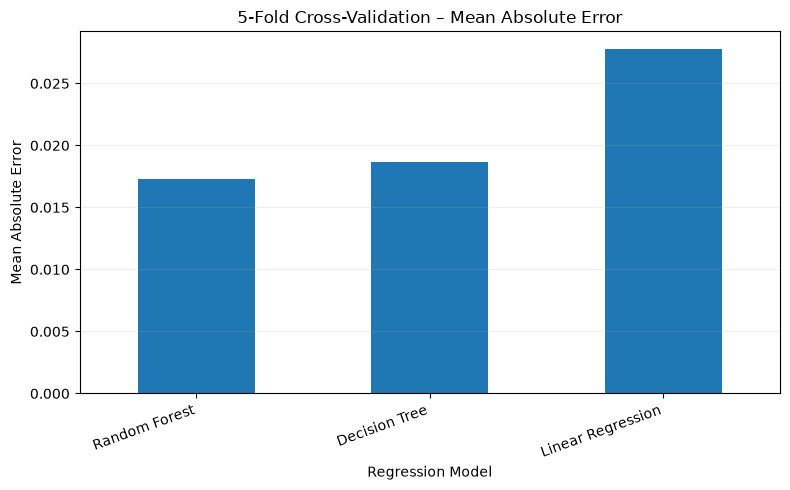

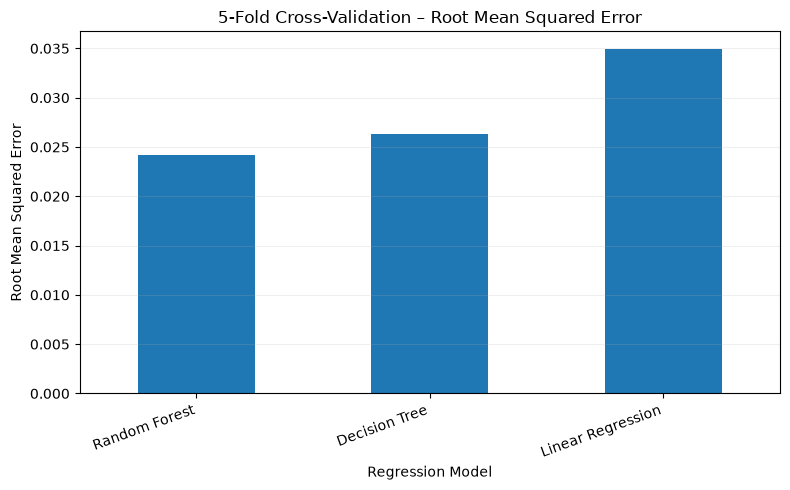

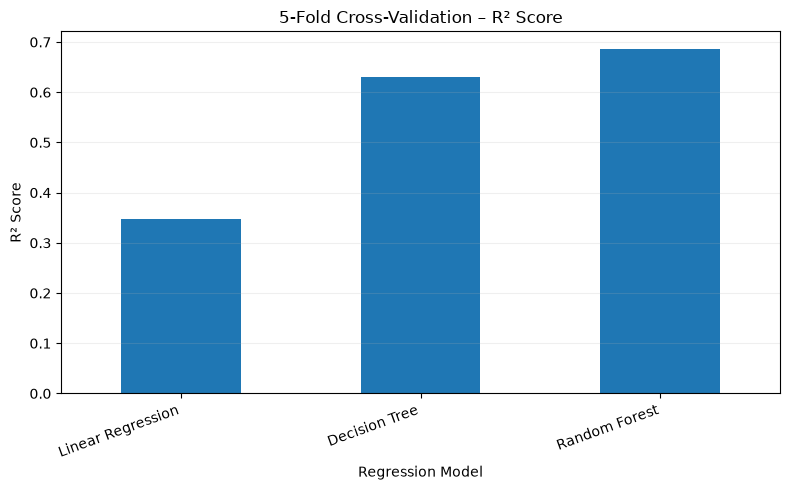

In [171]:
metric_labels = {
    "MAE_mean": "Mean Absolute Error",
    "RMSE_mean": "Root Mean Squared Error",
    "R2_mean": "R² Score"
}

for metric, title in metric_labels.items():

    plt.figure(figsize=(8, 5))

    validation_summary[
        metric
    ].sort_values().plot(
        kind="bar"
    )

    plt.title(
        f"5-Fold Cross-Validation – {title}"
    )

    plt.xlabel("Regression Model")
    plt.ylabel(title)

    plt.xticks(
        rotation=20,
        ha="right"
    )

    plt.grid(
        axis="y",
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

### 2.5 Training–Validation Comparison and Bias–Variance

Training performance and validation performance are compared to investigate the bias–variance trade-off.

A model with poor performance on both training and validation data may suffer from **high bias (underfitting)**.

A model with very strong training performance but substantially weaker validation performance may suffer from **high variance (overfitting)**.

A strong model should achieve good validation performance while maintaining a reasonably small training–validation gap.

In [172]:
train_validation_summary = (
    results_df
    .groupby(
        ["Model", "Split"]
    )
    .agg(
        MAE=("MAE", "mean"),
        RMSE=("RMSE", "mean"),
        R2=("R2", "mean")
    )
    .reset_index()
)

train_validation_summary.round(6)

,Model,Split,MAE,RMSE,R2
0,Decision Tree,Train,0.014851,0.021240,0.759223
1,Decision Tree,Validation,0.018691,0.026332,0.629937
2,Linear Regression,Train,0.027803,0.034977,0.347118
3,Linear Regression,Validation,0.027807,0.034983,0.346868
4,Random Forest,Train,0.014980,0.021059,0.763326
5,Random Forest,Validation,0.017329,0.024218,0.686969


In [173]:
r2_comparison = (
    train_validation_summary
    .pivot(
        index="Model",
        columns="Split",
        values="R2"
    )
)

r2_comparison["Generalization Gap"] = (
    r2_comparison["Train"]
    - r2_comparison["Validation"]
)

r2_comparison.round(6)

Split,Train,Validation,Generalization Gap
Model,,,
Decision Tree,0.759223,0.629937,0.129286
Linear Regression,0.347118,0.346868,0.000250
Random Forest,0.763326,0.686969,0.076357


### 2.6 Comparison of Error Behavior

Average predictive performance does not describe the complete error distribution.

The out-of-fold predictions generated during cross-validation are therefore used to compare:

- MAE
- residual standard deviation
- skewness
- excess kurtosis

for all three regression models.

This determines whether a model improves only the average error or also changes the shape and stability of the prediction-error distribution.

In [174]:
model_error_statistics = []

for model_name, predictions in oof_predictions.items():

    residuals = (
        y.to_numpy()
        - predictions
    )

    absolute_errors = np.abs(
        residuals
    )

    model_error_statistics.append({
        "Model": model_name,

        "MAE":
            absolute_errors.mean(),

        "Residual Std":
            residuals.std(ddof=1),

        "Skewness":
            pd.Series(residuals).skew(),

        "Excess Kurtosis":
            pd.Series(residuals).kurt()
    })

model_error_statistics = (
    pd.DataFrame(
        model_error_statistics
    )
    .set_index("Model")
)

model_error_statistics.round(6)

,MAE,Residual Std,Skewness,Excess Kurtosis
Model,,,,
Linear Regression,0.027807,0.034983,0.474068,0.350899
Decision Tree,0.018691,0.026333,0.546285,2.870100
Random Forest,0.017329,0.024219,0.788331,3.001810


In [175]:
preferred_model = (
    validation_summary
    .sort_values(
        by=[
            "RMSE_mean",
            "MAE_mean"
        ]
    )
    .index[0]
)

print(
    "Preferred model based on "
    "cross-validated predictive performance:"
)

print(preferred_model)

Preferred model based on cross-validated predictive performance:
Random Forest


### 2.7 Discussion

#### Relative model performance

The cross-validation results show a clear difference between the three modeling approaches.

**Linear Regression** provides the weakest predictive performance. It has the largest MAE and RMSE and the lowest R² score.

The **Decision Tree Regressor** improves substantially over Linear Regression, demonstrating that nonlinear relationships and feature interactions are important in this dataset.

The **Random Forest Regressor** provides the strongest validation performance. It achieves the lowest prediction errors and the highest R², indicating that combining multiple nonlinear trees improves generalization beyond both the linear baseline and a single decision tree.


#### Model assumptions

The Linear Regression model assumes that the expected target can be represented by a linear combination of the input variables.

The earlier residual analyses showed systematic feature-dependent patterns, non-constant residual variance, moderate positive skewness, and geographic subpopulations with different error behavior. Therefore, the assumptions underlying the linear model are not fully consistent with the observed data.

The independence assumption cannot be established from the current analysis. Because observations represent geographic anchorages and multiple observations may belong to related geographic regions, some spatial dependence may exist. This possibility would require a dedicated spatial analysis to evaluate formally.

Tree-based models make substantially weaker assumptions about linearity and can represent nonlinear thresholds and feature interactions directly.


#### Bias–variance trade-off

Linear Regression shows a relatively small difference between training and validation performance, but both are comparatively weak. This behavior is characteristic of **high bias**: the model is too restrictive to represent important relationships in the data.

The Decision Tree obtains substantially better training performance but shows a larger training–validation gap. This indicates increased **variance** and some overfitting, even after limiting tree depth and leaf size.

Random Forest reduces this problem by averaging predictions across multiple decision trees. It preserves much of the flexibility of tree-based modeling while reducing the variance associated with an individual tree.

This produces a better balance between bias and variance and results in the strongest validation performance.


#### Sensitivity to outliers and noise

Linear Regression is sensitive to influential observations because unusually large errors can affect the fitted least-squares solution globally.

A Decision Tree can isolate unusual observations into specific regions, but individual trees are also sensitive to small changes in the training data. Noise can alter split decisions and produce substantially different tree structures.

Random Forest is more robust to this instability because predictions are averaged across multiple trees trained on different bootstrap samples and feature subsets. Individual noisy splits therefore have less influence on the final prediction.


#### When does the linear model fail?

The previous error analyses identified several situations in which Linear Regression performs poorly.

These include:

- nonlinear error patterns across latitude and longitude,
- increasing prediction difficulty for particular ranges of distance from shore,
- unusually large `drift_radius` values,
- rare geographic conditions,
- specific country-level subpopulations.

These patterns cannot be represented adequately by one global linear relationship.


#### Advantages of tree-based models

Decision Trees can divide the feature space into different regions and learn separate prediction rules within each region.

This is particularly useful for the current dataset because relationships may differ between geographic regions, dock categories, distance ranges, and other subpopulations.

Trees can also learn interactions automatically. For example, the effect of distance from shore can be different in different countries without manually introducing an explicit interaction term.


#### Interpretability versus predictive performance

Linear Regression is the most directly interpretable of the three models because each coefficient represents a linear contribution to the prediction.

A single Decision Tree is also interpretable in principle because its sequence of decision rules can be inspected, although a deep tree can quickly become complex.

Random Forest provides the strongest predictive performance but is less directly interpretable because its prediction is produced by averaging many different trees.

Therefore, the results demonstrate a clear trade-off between simple global interpretability and predictive flexibility.


#### Preferred model

Based on the 5-fold cross-validation results, **Random Forest is the preferred regression model for this dataset**.

It provides the lowest cross-validated prediction errors and the highest R² while generalizing better than a single Decision Tree.

Its main disadvantage is reduced interpretability and increased computational cost. However, for the objective of obtaining robust predictive performance, these disadvantages are outweighed by its improved accuracy and reduced variance.


#### What was learned from the modeling stage?

The modeling stage demonstrates that model choice has a substantial effect on both predictive performance and error behavior.

The relatively weak performance of Linear Regression confirms that the relationships in the dataset cannot be described adequately by a single linear function.

The strong improvement obtained with tree-based models shows that nonlinear relationships, threshold effects, and feature interactions are important.

The comparison also demonstrates why evaluation should not rely only on training performance. A flexible model such as a Decision Tree can fit the training data very well while losing performance on unseen observations.

Finally, the results show that ensemble methods can retain nonlinear modeling power while improving generalization by reducing the instability of individual learners.

### Optional Model (Bonus): K-Nearest Neighbors Regressor

As an additional comparison, a **K-Nearest Neighbors (KNN) Regressor** is evaluated.

KNN is a non-parametric model. Instead of learning a global linear equation or a set of tree-based decision rules, it predicts a target value based on observations that are close to the query observation in feature space.

This provides an additional modeling perspective and allows the analysis to examine whether local similarity between observations is useful for predicting `drift_radius`.

The same target, feature set, and 5-fold cross-validation splits used for the required regression models are retained to preserve a fair comparison.

In [176]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [177]:
knn_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

knn_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

knn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            knn_numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            knn_categorical_transformer,
            categorical_features
        )
    ]
)

#### KNN Hyperparameters

The KNN Regressor is configured with:

- `n_neighbors = 10`
- distance weighting (`weights = "distance"`)
- Euclidean distance (`p = 2`)

Using more than one neighbor reduces sensitivity to individual observations.

Distance weighting gives greater influence to observations located closer to the query point while still using information from several neighboring observations.

The selected configuration is fixed before cross-validation and is not optimized using the validation results.

In [178]:
from sklearn import set_config

set_config(display="text")

knn_model = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance",
    p=2,
    n_jobs=-1
)

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", knn_preprocessor),
        ("model", knn_model)
    ]
)

print("KNN pipeline created successfully.")
print(knn_pipeline)

KNN pipeline created successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lat', 'lon',
                                                   'distance_from_shore_m']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                      

#### KNN Cross-Validation

The KNN model is evaluated using exactly the same five cross-validation folds used for the required regression models.

For every fold:

1. preprocessing is fitted only on the training observations,
2. the KNN model uses the processed training observations,
3. predictions are generated for the held-out validation fold,
4. MAE, MSE, RMSE, and R² are calculated.

Out-of-fold predictions are also stored for later error-distribution comparison.

In [179]:
knn_fold_results = []

knn_oof_predictions = np.full(
    len(y),
    np.nan
)

print("Starting: KNN Regressor")
start_time = time.time()

for fold_number, (train_idx, val_idx) in enumerate(
    cv.split(X, y),
    start=1
):

    fold_pipeline = clone(knn_pipeline)

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    fold_pipeline.fit(
        X_train,
        y_train
    )

    train_pred = fold_pipeline.predict(
        X_train
    )

    val_pred = fold_pipeline.predict(
        X_val
    )

    knn_oof_predictions[val_idx] = val_pred

    train_mse = mean_squared_error(
        y_train,
        train_pred
    )

    val_mse = mean_squared_error(
        y_val,
        val_pred
    )

    knn_fold_results.append({
        "Model": "KNN Regressor",
        "Fold": fold_number,
        "Split": "Train",
        "MAE": mean_absolute_error(
            y_train,
            train_pred
        ),
        "MSE": train_mse,
        "RMSE": np.sqrt(train_mse),
        "R2": r2_score(
            y_train,
            train_pred
        )
    })

    knn_fold_results.append({
        "Model": "KNN Regressor",
        "Fold": fold_number,
        "Split": "Validation",
        "MAE": mean_absolute_error(
            y_val,
            val_pred
        ),
        "MSE": val_mse,
        "RMSE": np.sqrt(val_mse),
        "R2": r2_score(
            y_val,
            val_pred
        )
    })

    print(
        f"  Fold {fold_number}/5 completed"
    )

elapsed = time.time() - start_time

print(
    f"KNN Regressor completed in "
    f"{elapsed:.1f} seconds."
)

Starting: KNN Regressor
  Fold 1/5 completed
  Fold 2/5 completed
  Fold 3/5 completed
  Fold 4/5 completed
  Fold 5/5 completed
KNN Regressor completed in 1070.6 seconds.


In [180]:
knn_results_df = pd.DataFrame(
    knn_fold_results
)

knn_validation_results = (
    knn_results_df[
        knn_results_df["Split"] == "Validation"
    ]
)

display(
    knn_validation_results.round(6)
)

,Model,Fold,Split,MAE,MSE,RMSE,R2
1,KNN Regressor,1,Validation,0.016736,0.000591,0.024318,0.685783
3,KNN Regressor,2,Validation,0.016933,0.000612,0.024746,0.671687
5,KNN Regressor,3,Validation,0.016834,0.000608,0.024649,0.676465
7,KNN Regressor,4,Validation,0.016768,0.000604,0.024575,0.678091
9,KNN Regressor,5,Validation,0.016770,0.000599,0.024466,0.679499


In [181]:
knn_summary = (
    knn_validation_results
    .agg({
        "MAE": ["mean", "std"],
        "MSE": ["mean", "std"],
        "RMSE": ["mean", "std"],
        "R2": ["mean", "std"]
    })
)

knn_summary.round(6)

,MAE,MSE,RMSE,R2
mean,0.016808,0.000603,0.024551,0.678305
std,0.000078,0.000008,0.000165,0.005113


#### Extended Regression Model Comparison

The KNN results are now added to the required-model comparison.

This produces a comparison between four substantially different approaches:

- Linear Regression: global linear model
- Decision Tree: nonlinear rule-based model
- Random Forest: tree-based ensemble model
- KNN: local distance-based model

The comparison therefore examines linear, nonlinear partition-based, ensemble-based, and local similarity-based modeling assumptions.

In [182]:
combined_results_df = pd.concat(
    [
        results_df,
        knn_results_df
    ],
    ignore_index=True
)

combined_validation_results = (
    combined_results_df[
        combined_results_df["Split"] == "Validation"
    ]
)

extended_validation_summary = (
    combined_validation_results
    .groupby("Model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),

        MSE_mean=("MSE", "mean"),
        MSE_std=("MSE", "std"),

        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),

        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
    .sort_values(
        "RMSE_mean"
    )
)

extended_validation_summary.round(6)

,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
Model,,,,,,,,
Random Forest,0.017329,0.000109,0.000587,0.000008,0.024218,0.000160,0.686969,0.004782
KNN Regressor,0.016808,0.000078,0.000603,0.000008,0.024551,0.000165,0.678305,0.005113
Decision Tree,0.018691,0.000154,0.000693,0.000011,0.026332,0.000207,0.629937,0.006250
Linear Regression,0.027807,0.000058,0.001224,0.000004,0.034983,0.000060,0.346868,0.003715


In [183]:
knn_residuals = (
    y.to_numpy()
    - knn_oof_predictions
)

knn_absolute_errors = np.abs(
    knn_residuals
)

knn_error_statistics = pd.Series({
    "MAE":
        knn_absolute_errors.mean(),

    "Residual Std":
        knn_residuals.std(ddof=1),

    "Skewness":
        pd.Series(
            knn_residuals
        ).skew(),

    "Excess Kurtosis":
        pd.Series(
            knn_residuals
        ).kurt()
})

knn_error_statistics.round(6)

MAE                0.016808
Residual Std       0.024550
Skewness           0.450499
Excess Kurtosis    3.943932
dtype: float64

In [184]:
knn_train_validation_summary = (
    knn_results_df
    .groupby("Split")
    .agg(
        MAE=("MAE", "mean"),
        RMSE=("RMSE", "mean"),
        R2=("R2", "mean")
    )
)

knn_train_validation_summary.round(6)

,MAE,RMSE,R2
Split,,,
Train,0.000000,0.000000,1.000000
Validation,0.016808,0.024551,0.678305


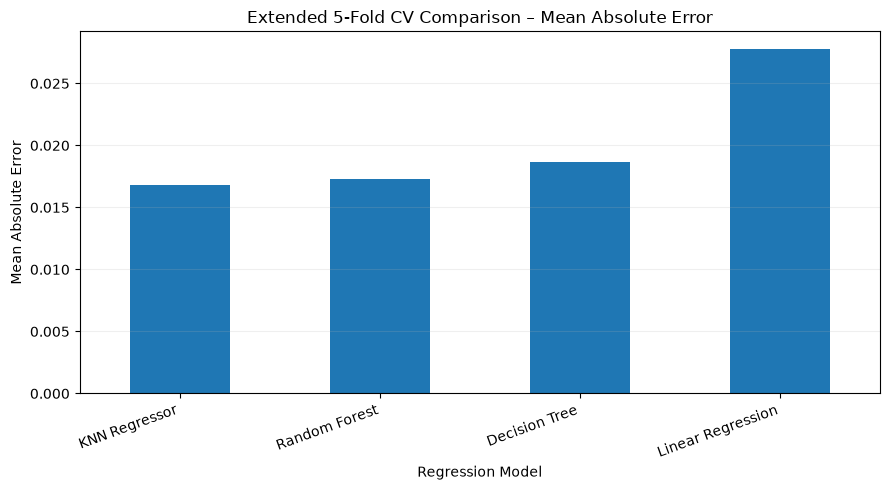

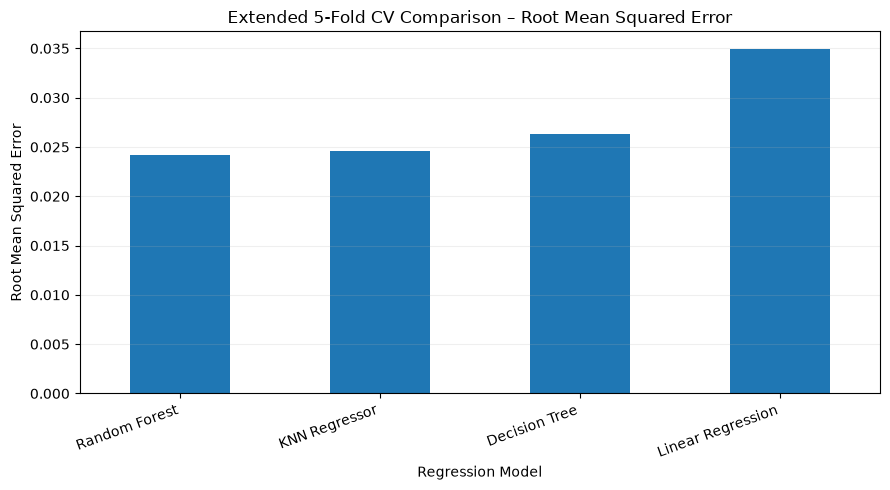

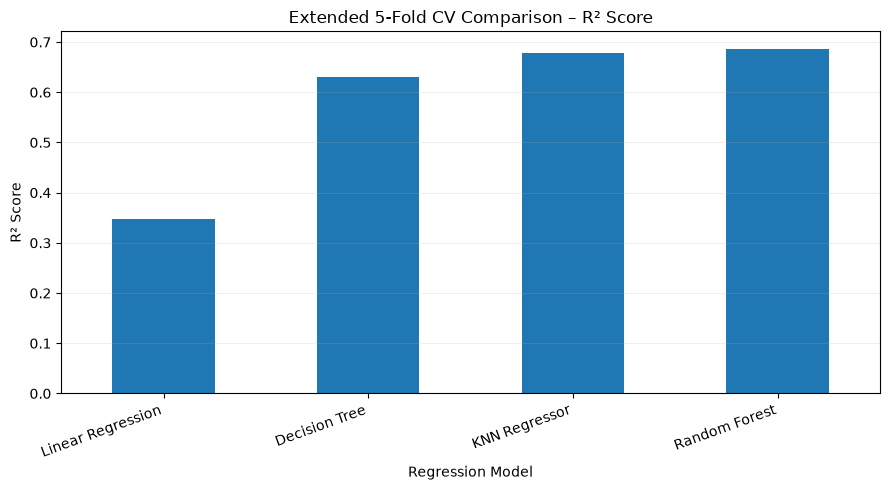

In [185]:
for metric, title in {
    "MAE_mean": "Mean Absolute Error",
    "RMSE_mean": "Root Mean Squared Error",
    "R2_mean": "R² Score"
}.items():

    plt.figure(figsize=(9, 5))

    values = extended_validation_summary[
        metric
    ].sort_values()

    values.plot(
        kind="bar"
    )

    plt.title(
        f"Extended 5-Fold CV Comparison – {title}"
    )

    plt.xlabel("Regression Model")
    plt.ylabel(title)

    plt.xticks(
        rotation=20,
        ha="right"
    )

    plt.grid(
        axis="y",
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

#### Interpretation of the KNN Model

KNN introduces a substantially different modeling assumption from the three required regression models.

Unlike Linear Regression, KNN does not assume a global linear relationship.

Unlike Decision Trees and Random Forests, it does not explicitly partition the feature space using learned decision rules.

Instead, predictions are based on local similarity between observations.

This makes KNN potentially useful when similar anchorages tend to have similar drift-radius values.

However, KNN also has important limitations.

First, its predictions depend strongly on the definition of distance. For this reason, numerical scaling is essential.

Second, one-hot encoded categorical features increase the dimensionality of the feature space. In higher-dimensional spaces, observations can become less clearly separated by distance, a phenomenon commonly associated with the curse of dimensionality.

Third, prediction is computationally more expensive than for a fitted parametric model because KNN must search through stored training observations when generating predictions.

Finally, very strong training performance should not automatically be interpreted as excellent generalization. Distance-weighted KNN can reproduce training observations extremely closely, so validation performance remains the relevant measure for comparing it fairly with the other models.

#### Bonus Model Conclusion

The final assessment of the KNN Regressor is based on its 5-fold validation MAE, RMSE, R², fold-to-fold stability, and its generalization gap relative to the required regression models.

The numerical results are discussed together with the complete regression-model comparison below.

### Experimental Requirements and Fair Comparison

To ensure a fair comparison between the regression models, the experimental setup is kept consistent across all models.

All models are trained and evaluated using:

- the same target variable: `drift_radius`
- the same numerical features:
  - `lat`
  - `lon`
  - `distance_from_shore_m`
- the same categorical features:
  - `dock`
  - `iso3`
  - `label_source`
- the same observations
- the same 5-fold cross-validation splits

The model-specific preprocessing may differ only when required by the mathematical assumptions of the algorithm.

For example, KNN requires numerical feature scaling because its predictions depend directly on distances between observations. This does not change the feature set and therefore preserves the fairness of the comparison.

In [186]:
comparison_setup = pd.DataFrame({
    "Type": [
        "Target",
        "Numerical Features",
        "Categorical Features",
        "Number of Features",
        "Number of Observations",
        "Cross-Validation"
    ],
    "Configuration": [
        target,
        ", ".join(numeric_features),
        ", ".join(categorical_features),
        len(features),
        len(X),
        "5-fold KFold, shuffle=True, random_state=42"
    ]
})

comparison_setup

,Type,Configuration
0,Target,drift_radius
1,Numerical Features,"lat, lon, distance_from_shore_m"
2,Categorical Features,"dock, iso3, label_source"
3,Number of Features,6
4,Number of Observations,166329
5,Cross-Validation,"5-fold KFold, shuffle=True, random_state=42"


In [187]:
hyperparameter_table = pd.DataFrame({
    "Model": [
        "LinearRegression",
        "DecisionTreeRegressor",
        "RandomForestRegressor",
        "KNeighborsRegressor"
    ],

    "Main hyperparameters": [
        "Default",
        "max_depth=20, min_samples_leaf=5, random_state=42",
        "n_estimators=30, max_depth=20, min_samples_leaf=5, "
        "max_features=0.7, random_state=42, n_jobs=-1",
        "n_neighbors=10, weights='distance', p=2, n_jobs=-1"
    ]
}, index=[
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "KNN Regressor"
])

hyperparameter_table

,Model,Main hyperparameters
Linear Regression,LinearRegression,Default
Decision Tree,DecisionTreeRegressor,"max_depth=20, min_samples_leaf=5, random_state=42"
Random Forest,RandomForestRegressor,"n_estimators=30, max_depth=20, min_samples_lea..."
KNN Regressor,KNeighborsRegressor,"n_neighbors=10, weights='distance', p=2, n_job..."


### Performance Metrics

Model performance is evaluated using multiple complementary metrics.

**Mean Absolute Error (MAE)**

Measures the average absolute difference between the true and predicted values.

Lower values indicate better performance.

**Mean Squared Error (MSE)**

Measures the average squared prediction error.

Because errors are squared, this metric penalizes large errors more strongly than MAE.

Lower values indicate better performance.

**Root Mean Squared Error (RMSE)**

The square root of MSE.

RMSE is expressed in the same units as the regression target while retaining greater sensitivity to large errors than MAE.

Lower values indicate better performance.

**R² Score**

Measures the proportion of target variability explained by the model relative to predicting the target mean.

Higher values indicate better predictive performance.

Using several metrics prevents the model comparison from depending on a single definition of prediction quality.

In [188]:
validation_summary

,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
Model,,,,,,,,
Random Forest,0.017329,0.000109,0.000587,0.000008,0.024218,0.000160,0.686969,0.004782
Decision Tree,0.018691,0.000154,0.000693,0.000011,0.026332,0.000207,0.629937,0.006250
Linear Regression,0.027807,0.000058,0.001224,0.000004,0.034983,0.000060,0.346868,0.003715


In [189]:
required_model_metrics = validation_summary[
    [
        "MAE_mean",
        "MSE_mean",
        "RMSE_mean",
        "R2_mean"
    ]
].copy()

required_model_metrics.columns = [
    "MAE",
    "MSE",
    "RMSE",
    "R²"
]

required_model_metrics.round(6)

,MAE,MSE,RMSE,R²
Model,,,,
Random Forest,0.017329,0.000587,0.024218,0.686969
Decision Tree,0.018691,0.000693,0.026332,0.629937
Linear Regression,0.027807,0.001224,0.034983,0.346868


In [190]:
required_model_stability = validation_summary[
    [
        "MAE_std",
        "MSE_std",
        "RMSE_std",
        "R2_std"
    ]
].copy()

required_model_stability.columns = [
    "MAE Std",
    "MSE Std",
    "RMSE Std",
    "R² Std"
]

required_model_stability.round(6)

,MAE Std,MSE Std,RMSE Std,R² Std
Model,,,,
Random Forest,0.000109,0.000008,0.000160,0.004782
Decision Tree,0.000154,0.000011,0.000207,0.006250
Linear Regression,0.000058,0.000004,0.000060,0.003715


### Requirement Verification

The model-comparison experiment satisfies the required conditions:

1. **Same feature set:** all required regression models use exactly the same six predictive features and the same target variable.

2. **Clearly specified hyperparameters:** the configurations of Linear Regression, Decision Tree, and Random Forest are explicitly documented and fixed before final evaluation.

3. **Multiple evaluation metrics:** every model is evaluated using MAE, MSE, RMSE, and R² across the same 5-fold cross-validation procedure.

In addition, the standard deviation of each metric across folds is reported to evaluate performance stability.

Therefore, differences in the final results can be attributed primarily to the modeling approach rather than to differences in input data or evaluation methodology.

### Critical Discussion of the Regression Models

This section provides a critical comparison of the evaluated regression models.

The discussion considers:

- relative predictive performance across multiple evaluation metrics,
- model assumptions,
- the bias–variance trade-off,
- sensitivity to outliers and noise,
- situations in which linear modeling fails,
- advantages of tree-based models,
- interpretability versus predictive performance,
- selection of a preferred model,
- and the main conclusions learned from the modeling stage.

All performance comparisons are based on the same 5-fold cross-validation procedure and the same feature set.

In [191]:
# Use the extended comparison if the KNN bonus was completed.
# Otherwise, use only the required regression models.

if "extended_validation_summary" in globals():
    discussion_validation_summary = (
        extended_validation_summary.copy()
    )
else:
    discussion_validation_summary = (
        validation_summary.copy()
    )

discussion_validation_summary.round(6)

,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
Model,,,,,,,,
Random Forest,0.017329,0.000109,0.000587,0.000008,0.024218,0.000160,0.686969,0.004782
KNN Regressor,0.016808,0.000078,0.000603,0.000008,0.024551,0.000165,0.678305,0.005113
Decision Tree,0.018691,0.000154,0.000693,0.000011,0.026332,0.000207,0.629937,0.006250
Linear Regression,0.027807,0.000058,0.001224,0.000004,0.034983,0.000060,0.346868,0.003715


#### Relative Model Performance

The regression models are compared using MAE, MSE, RMSE, and R².

MAE measures the typical absolute prediction error, while MSE and RMSE penalize large errors more strongly.

R² measures the proportion of target variability explained by the model.

Because no single metric describes every aspect of predictive performance, the preferred model should perform consistently well across several metrics rather than being selected based on only one score.

In [192]:
model_ranking = (
    discussion_validation_summary
    .copy()
)

model_ranking["RMSE_rank"] = (
    model_ranking["RMSE_mean"]
    .rank(method="min")
)

model_ranking["MAE_rank"] = (
    model_ranking["MAE_mean"]
    .rank(method="min")
)

model_ranking["R2_rank"] = (
    model_ranking["R2_mean"]
    .rank(
        method="min",
        ascending=False
    )
)

model_ranking["Average_rank"] = (
    model_ranking[
        [
            "RMSE_rank",
            "MAE_rank",
            "R2_rank"
        ]
    ]
    .mean(axis=1)
)

model_ranking = (
    model_ranking
    .sort_values("Average_rank")
)

display(
    model_ranking[
        [
            "MAE_mean",
            "MSE_mean",
            "RMSE_mean",
            "R2_mean",
            "Average_rank"
        ]
    ].round(6)
)

,MAE_mean,MSE_mean,RMSE_mean,R2_mean,Average_rank
Model,,,,,
Random Forest,0.017329,0.000587,0.024218,0.686969,1.333333
KNN Regressor,0.016808,0.000603,0.024551,0.678305,1.666667
Decision Tree,0.018691,0.000693,0.026332,0.629937,3.000000
Linear Regression,0.027807,0.001224,0.034983,0.346868,4.000000


#### Bias–Variance Trade-off

The difference between training and validation performance provides information about the bias–variance behavior of the models.

A model that performs poorly on both training and validation data may suffer from high bias and underfitting.

A model that performs extremely well on the training data but noticeably worse on validation data may suffer from high variance and overfitting.

The required regression models are therefore compared using their mean training and validation performance.

In [193]:
required_train_validation = (
    results_df
    .groupby(
        ["Model", "Split"]
    )
    .agg(
        MAE=("MAE", "mean"),
        RMSE=("RMSE", "mean"),
        R2=("R2", "mean")
    )
    .reset_index()
)

r2_bias_variance = (
    required_train_validation
    .pivot(
        index="Model",
        columns="Split",
        values="R2"
    )
)

r2_bias_variance["R2_generalization_gap"] = (
    r2_bias_variance["Train"]
    - r2_bias_variance["Validation"]
)

r2_bias_variance.round(6)

Split,Train,Validation,R2_generalization_gap
Model,,,
Decision Tree,0.759223,0.629937,0.129286
Linear Regression,0.347118,0.346868,0.000250
Random Forest,0.763326,0.686969,0.076357


#### Error Distribution and Robustness

Average performance alone does not reveal whether a model occasionally produces unusually large errors.

The statistical properties of the out-of-fold residuals are therefore also considered.

A smaller residual standard deviation indicates a tighter error distribution, while skewness and kurtosis provide information about asymmetry and tail behavior.

In [194]:
if "model_error_statistics" in globals():

    error_comparison = (
        model_error_statistics.copy()
    )

    if "knn_error_statistics" in globals():
        error_comparison.loc[
            "KNN Regressor"
        ] = knn_error_statistics

    display(
        error_comparison.round(6)
    )

else:
    print(
        "Run the model error-statistics block "
        "from Section 2.6 before this comparison."
    )

,MAE,Residual Std,Skewness,Excess Kurtosis
Model,,,,
Linear Regression,0.027807,0.034983,0.474068,0.350899
Decision Tree,0.018691,0.026333,0.546285,2.870100
Random Forest,0.017329,0.024219,0.788331,3.001810
KNN Regressor,0.016808,0.024550,0.450499,3.943932


In [195]:
preferred_model = (
    model_ranking
    .sort_values(
        [
            "Average_rank",
            "RMSE_mean"
        ]
    )
    .index[0]
)

best_mae_model = (
    discussion_validation_summary[
        "MAE_mean"
    ]
    .idxmin()
)

best_rmse_model = (
    discussion_validation_summary[
        "RMSE_mean"
    ]
    .idxmin()
)

best_r2_model = (
    discussion_validation_summary[
        "R2_mean"
    ]
    .idxmax()
)

print(
    "Best MAE:",
    best_mae_model
)

print(
    "Best RMSE:",
    best_rmse_model
)

print(
    "Best R²:",
    best_r2_model
)

print(
    "\nPreferred model:",
    preferred_model
)

Best MAE: KNN Regressor
Best RMSE: Random Forest
Best R²: Random Forest

Preferred model: Random Forest


In [196]:
from IPython.display import Markdown, display

summary = discussion_validation_summary

best = preferred_model

best_mae = summary.loc[best, "MAE_mean"]
best_mse = summary.loc[best, "MSE_mean"]
best_rmse = summary.loc[best, "RMSE_mean"]
best_r2 = summary.loc[best, "R2_mean"]

lr = summary.loc["Linear Regression"]
dt = summary.loc["Decision Tree"]
rf = summary.loc["Random Forest"]

rmse_improvement_vs_linear = (
    (lr["RMSE_mean"] - best_rmse)
    / lr["RMSE_mean"]
    * 100
)

r2_improvement_vs_linear = (
    best_r2 - lr["R2_mean"]
)

largest_gap_model = (
    r2_bias_variance[
        "R2_generalization_gap"
    ]
    .idxmax()
)

largest_gap = (
    r2_bias_variance.loc[
        largest_gap_model,
        "R2_generalization_gap"
    ]
)

discussion_text = f"""
### Final Regression Model Discussion

#### 1. Relative model performance across evaluation metrics

The regression models show meaningful differences in predictive performance.

The best overall model according to the combined cross-validation comparison is **{best}**.

Its mean validation performance is approximately:

- **MAE = {best_mae:.4f}**
- **MSE = {best_mse:.6f}**
- **RMSE = {best_rmse:.4f}**
- **R² = {best_r2:.4f}**

Compared with Linear Regression, the preferred model reduces RMSE by approximately **{rmse_improvement_vs_linear:.1f}%** and increases R² by approximately **{r2_improvement_vs_linear:.3f}**.

The comparison shows that model choice has a substantial effect on prediction quality rather than producing only minor numerical differences.


#### 2. Model assumptions

Linear Regression assumes that the expected target can be represented as a linear combination of the input features.

The residual analysis performed in Sections 1.1–1.4 showed that this assumption is not fully consistent with the dataset.

The residuals exhibited systematic feature-dependent behavior, and the variance of the residuals changed across different prediction and feature regions. Therefore, the assumptions of strict linearity and homoskedasticity are not fully satisfied.

The independence assumption cannot be established from the current analysis. Since the observations represent geographic anchorages, observations within similar geographic regions may potentially be related. A dedicated spatial-dependence analysis would be required to evaluate this formally.

Decision Trees and Random Forests make substantially weaker assumptions about linearity and can represent nonlinear relationships and feature interactions directly.


#### 3. Bias–variance trade-off

The training–validation comparison reveals different bias–variance behavior among the models.

Linear Regression has relatively similar training and validation performance, but its predictive accuracy is weaker than the more flexible models. This indicates relatively **high bias** and suggests underfitting.

The largest R² training–validation gap among the required models is observed for **{largest_gap_model}**, with a gap of approximately **{largest_gap:.3f}**. A larger gap indicates increased variance and stronger sensitivity to the particular training sample.

A single Decision Tree is especially capable of fitting detailed structures in the training data and may therefore overfit.

Random Forest reduces this instability by averaging predictions across multiple trees. This preserves nonlinear modeling ability while reducing the variance associated with an individual tree.


#### 4. Sensitivity to outliers and noise

The models also differ in their sensitivity to unusual observations and noise.

Linear Regression minimizes squared errors, so observations with unusually large residuals can have substantial influence on the fitted coefficients and affect predictions globally.

A Decision Tree can isolate unusual observations into specific regions of the feature space. However, individual trees can be unstable because relatively small changes in the data may change split locations and produce a different tree structure.

Random Forest reduces this sensitivity by averaging many trees. An unusual observation or unstable split therefore has less influence on the final ensemble prediction.

The extreme-error analysis from Section 1.3 showed that rare target values and unusual geographic conditions are strongly represented among the largest errors, demonstrating why model robustness is important for this dataset.


#### 5. Scenarios in which the linear model fails

The Linear Regression model performs poorly when the relationship between the predictors and `drift_radius` is not adequately represented by one global linear equation.

The earlier error analyses identified several such situations:

- nonlinear error patterns across latitude and longitude,
- changing prediction error across distance-from-shore ranges,
- unusually large `drift_radius` values,
- extreme geographic observations,
- and specific geographic subpopulations with substantially higher error rates.

These patterns indicate threshold effects, interactions, or local relationships that a single linear equation cannot represent effectively.


#### 6. Situations in which tree-based models provide advantages

Tree-based models are advantageous when the feature space contains nonlinear relationships, thresholds, interactions, or heterogeneous subpopulations.

A Decision Tree can divide observations into different regions and apply different predictions within each region.

For example, the relationship between distance from shore and `drift_radius` does not need to be identical in every country or geographic region. A tree can model such conditional behavior without manually specifying interaction terms.

Random Forest extends this advantage by combining many trees, producing a more stable and generally more accurate prediction.


#### 7. Interpretability versus predictive performance

Linear Regression provides the highest level of direct global interpretability.

Its coefficients can be examined to understand how changes in features are associated with changes in the predicted target, assuming the linear model is appropriate.

A single Decision Tree is also interpretable because its prediction rules can be inspected directly, although a deep tree becomes difficult to understand.

Random Forest generally provides stronger predictive performance but lower direct interpretability because the final prediction is the result of many different trees.

Therefore, the results demonstrate a clear trade-off between simplicity and predictive flexibility.


#### 8. Preferred model for future analysis

Based on the complete 5-fold cross-validation comparison, **{best}** is selected as the preferred regression model.

The decision is supported by its strong performance across several metrics rather than by a single score.

It provides the best overall balance of MAE, RMSE, R², and cross-validation performance among the evaluated alternatives.

For future predictive analysis, this improvement in generalization is more important than the additional computational complexity and reduced direct interpretability of the model.


#### 9. What was learned from the modeling stage?

The modeling stage demonstrates that the errors identified during the earlier residual analysis were not simply random noise.

Changing the modeling assumptions substantially changes predictive performance.

Linear Regression provides a useful baseline but is too restrictive for important relationships in the dataset.

The improvement achieved by nonlinear models confirms that geographic relationships, threshold effects, interactions, and subpopulation differences are important.

The comparison also demonstrates why training performance alone is insufficient. Flexible models may fit the training data extremely well but still lose accuracy on unseen observations.

Finally, the results show the value of ensemble learning: combining multiple models can preserve nonlinear predictive power while reducing the instability of an individual learner.
"""

display(
    Markdown(discussion_text)
)


### Final Regression Model Discussion

#### 1. Relative model performance across evaluation metrics

The regression models show meaningful differences in predictive performance.

The best overall model according to the combined cross-validation comparison is **Random Forest**.

Its mean validation performance is approximately:

- **MAE = 0.0173**
- **MSE = 0.000587**
- **RMSE = 0.0242**
- **R² = 0.6870**

Compared with Linear Regression, the preferred model reduces RMSE by approximately **30.8%** and increases R² by approximately **0.340**.

The comparison shows that model choice has a substantial effect on prediction quality rather than producing only minor numerical differences.


#### 2. Model assumptions

Linear Regression assumes that the expected target can be represented as a linear combination of the input features.

The residual analysis performed in Sections 1.1–1.4 showed that this assumption is not fully consistent with the dataset.

The residuals exhibited systematic feature-dependent behavior, and the variance of the residuals changed across different prediction and feature regions. Therefore, the assumptions of strict linearity and homoskedasticity are not fully satisfied.

The independence assumption cannot be established from the current analysis. Since the observations represent geographic anchorages, observations within similar geographic regions may potentially be related. A dedicated spatial-dependence analysis would be required to evaluate this formally.

Decision Trees and Random Forests make substantially weaker assumptions about linearity and can represent nonlinear relationships and feature interactions directly.


#### 3. Bias–variance trade-off

The training–validation comparison reveals different bias–variance behavior among the models.

Linear Regression has relatively similar training and validation performance, but its predictive accuracy is weaker than the more flexible models. This indicates relatively **high bias** and suggests underfitting.

The largest R² training–validation gap among the required models is observed for **Decision Tree**, with a gap of approximately **0.129**. A larger gap indicates increased variance and stronger sensitivity to the particular training sample.

A single Decision Tree is especially capable of fitting detailed structures in the training data and may therefore overfit.

Random Forest reduces this instability by averaging predictions across multiple trees. This preserves nonlinear modeling ability while reducing the variance associated with an individual tree.


#### 4. Sensitivity to outliers and noise

The models also differ in their sensitivity to unusual observations and noise.

Linear Regression minimizes squared errors, so observations with unusually large residuals can have substantial influence on the fitted coefficients and affect predictions globally.

A Decision Tree can isolate unusual observations into specific regions of the feature space. However, individual trees can be unstable because relatively small changes in the data may change split locations and produce a different tree structure.

Random Forest reduces this sensitivity by averaging many trees. An unusual observation or unstable split therefore has less influence on the final ensemble prediction.

The extreme-error analysis from Section 1.3 showed that rare target values and unusual geographic conditions are strongly represented among the largest errors, demonstrating why model robustness is important for this dataset.


#### 5. Scenarios in which the linear model fails

The Linear Regression model performs poorly when the relationship between the predictors and `drift_radius` is not adequately represented by one global linear equation.

The earlier error analyses identified several such situations:

- nonlinear error patterns across latitude and longitude,
- changing prediction error across distance-from-shore ranges,
- unusually large `drift_radius` values,
- extreme geographic observations,
- and specific geographic subpopulations with substantially higher error rates.

These patterns indicate threshold effects, interactions, or local relationships that a single linear equation cannot represent effectively.


#### 6. Situations in which tree-based models provide advantages

Tree-based models are advantageous when the feature space contains nonlinear relationships, thresholds, interactions, or heterogeneous subpopulations.

A Decision Tree can divide observations into different regions and apply different predictions within each region.

For example, the relationship between distance from shore and `drift_radius` does not need to be identical in every country or geographic region. A tree can model such conditional behavior without manually specifying interaction terms.

Random Forest extends this advantage by combining many trees, producing a more stable and generally more accurate prediction.


#### 7. Interpretability versus predictive performance

Linear Regression provides the highest level of direct global interpretability.

Its coefficients can be examined to understand how changes in features are associated with changes in the predicted target, assuming the linear model is appropriate.

A single Decision Tree is also interpretable because its prediction rules can be inspected directly, although a deep tree becomes difficult to understand.

Random Forest generally provides stronger predictive performance but lower direct interpretability because the final prediction is the result of many different trees.

Therefore, the results demonstrate a clear trade-off between simplicity and predictive flexibility.


#### 8. Preferred model for future analysis

Based on the complete 5-fold cross-validation comparison, **Random Forest** is selected as the preferred regression model.

The decision is supported by its strong performance across several metrics rather than by a single score.

It provides the best overall balance of MAE, RMSE, R², and cross-validation performance among the evaluated alternatives.

For future predictive analysis, this improvement in generalization is more important than the additional computational complexity and reduced direct interpretability of the model.


#### 9. What was learned from the modeling stage?

The modeling stage demonstrates that the errors identified during the earlier residual analysis were not simply random noise.

Changing the modeling assumptions substantially changes predictive performance.

Linear Regression provides a useful baseline but is too restrictive for important relationships in the dataset.

The improvement achieved by nonlinear models confirms that geographic relationships, threshold effects, interactions, and subpopulation differences are important.

The comparison also demonstrates why training performance alone is insufficient. Flexible models may fit the training data extremely well but still lose accuracy on unseen observations.

Finally, the results show the value of ensemble learning: combining multiple models can preserve nonlinear predictive power while reducing the instability of an individual learner.


### Section 2 Conclusion

The regression-model comparison demonstrates that model assumptions have a direct impact on both predictive performance and error behavior.

The results support the conclusions obtained from the earlier residual analyses: the dataset contains nonlinear relationships, heterogeneous subpopulations, and exceptional observations that cannot be represented adequately by a simple global linear model.

Cross-validation, training–validation comparison, multiple evaluation metrics, and residual analysis together provide a more complete assessment than any individual performance metric alone.

## 3. Classification Error Analysis

### 3.1 Confusion Matrix Analysis

The objective of this section is to analyze the classification errors of a model that predicts whether an anchorage observation represents a **dock**.

The target variable is:

- `dock = 1`: Dock
- `dock = 0`: Non-Dock

A **Logistic Regression** classifier is used as a baseline classification model.

All predictions used in the error analysis are generated using **5-fold stratified cross-validation**, ensuring that every observation is evaluated by a model that was not trained on that observation.

The confusion matrix is then used to analyze:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

Special attention is given to the implications of False Positives and False Negatives and to geographic regions in which classification failures occur systematically.

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

df = pd.read_csv(
    "data/named_anchorages_v2_20221206.csv",
    low_memory=False
)

print("Dataset shape:", df.shape)

Dataset shape: (166482, 10)


In [198]:
classification_df = (
    df
    .dropna(subset=["dock"])
    .copy()
    .reset_index(drop=True)
)

def convert_dock_to_binary(value):
    if value is True or value == 1:
        return 1

    if value is False or value == 0:
        return 0

    value_text = str(value).strip().lower()

    if value_text in ["true", "1"]:
        return 1

    if value_text in ["false", "0"]:
        return 0

    return np.nan


classification_df["dock_binary"] = (
    classification_df["dock"]
    .apply(convert_dock_to_binary)
)

classification_df = (
    classification_df
    .dropna(subset=["dock_binary"])
    .reset_index(drop=True)
)

classification_df["dock_binary"] = (
    classification_df["dock_binary"]
    .astype(int)
)

numeric_classification_features = [
    "lat",
    "lon",
    "distance_from_shore_m",
    "drift_radius"
]

categorical_classification_features = [
    "iso3",
    "label_source"
]

classification_features = (
    numeric_classification_features
    + categorical_classification_features
)

X_class = classification_df[
    classification_features
]

y_class = classification_df[
    "dock_binary"
]

print(
    "Classification observations:",
    len(classification_df)
)

print("\nClass distribution:")

print(
    y_class
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Non-Dock",
        1: "Dock"
    })
)

Classification observations: 166462

Class distribution:
dock_binary
Non-Dock    87939
Dock        78523
Name: count, dtype: int64


#### Class Distribution

Before training the classifier, the target distribution is examined.

A severely imbalanced target could cause accuracy to provide a misleading evaluation of classification performance.

The dock dataset is relatively balanced, so both classes are represented by a substantial number of observations. Therefore, no artificial class balancing is applied to the baseline model.

In [199]:
class_distribution = pd.DataFrame({
    "Count": y_class.value_counts().sort_index(),
    "Percentage": (
        y_class
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )
})

class_distribution.index = [
    "Non-Dock",
    "Dock"
]

class_distribution.round(2)

,Count,Percentage
Non-Dock,87939,52.83
Dock,78523,47.17


#### Classification Preprocessing and Model

Numerical variables are standardized before Logistic Regression because the numerical features are measured on very different scales.

Missing numerical values are replaced with the median value of the corresponding training fold.

Categorical variables are imputed using their most frequent category and then one-hot encoded.

All preprocessing operations are placed inside the classification pipeline. Therefore, preprocessing is fitted independently within every training fold and does not use information from the corresponding validation fold.

The Logistic Regression model serves as an interpretable baseline classifier.

In [200]:
classification_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

classification_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

classification_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            classification_numeric_transformer,
            numeric_classification_features
        ),
        (
            "categorical",
            classification_categorical_transformer,
            categorical_classification_features
        )
    ]
)

classification_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

classification_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            classification_preprocessor
        ),
        (
            "model",
            classification_model
        )
    ]
)

print(
    "Classification pipeline created successfully."
)

Classification pipeline created successfully.


#### Cross-Validation Strategy

A **5-fold Stratified Cross-Validation** procedure is used.

Five folds provide a practical balance between computational cost and reliable generalization estimates for a dataset containing more than 166,000 observations.

Stratification is used because this is a binary classification problem. It preserves approximately the same proportion of dock and non-dock observations in every fold.

The data are shuffled before fold creation, and `random_state = 42` is used for reproducibility.

Every final classification prediction is therefore an **out-of-fold prediction** generated for an observation that was not used to train the model that predicted it.

In [201]:
classification_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_class_predictions = np.full(
    len(y_class),
    np.nan
)

oof_class_probabilities = np.full(
    len(y_class),
    np.nan
)

print(
    "Starting 5-fold classification..."
)

for fold_number, (train_idx, val_idx) in enumerate(
    classification_cv.split(
        X_class,
        y_class
    ),
    start=1
):

    fold_pipeline = clone(
        classification_pipeline
    )

    X_train = X_class.iloc[train_idx]
    X_val = X_class.iloc[val_idx]

    y_train = y_class.iloc[train_idx]
    y_val = y_class.iloc[val_idx]

    fold_pipeline.fit(
        X_train,
        y_train
    )

    class_pred = fold_pipeline.predict(
        X_val
    )

    class_prob = (
        fold_pipeline
        .predict_proba(X_val)[:, 1]
    )

    oof_class_predictions[val_idx] = (
        class_pred
    )

    oof_class_probabilities[val_idx] = (
        class_prob
    )

    print(
        f"Fold {fold_number}/5 completed"
    )

print(
    "\nClassification cross-validation completed."
)

Starting 5-fold classification...
Fold 1/5 completed
Fold 2/5 completed
Fold 3/5 completed
Fold 4/5 completed
Fold 5/5 completed

Classification cross-validation completed.


In [202]:
classification_analysis_df = (
    classification_df.copy()
)

classification_analysis_df[
    "actual_class"
] = y_class.to_numpy()

classification_analysis_df[
    "predicted_class"
] = oof_class_predictions.astype(int)

classification_analysis_df[
    "dock_probability"
] = oof_class_probabilities

classification_analysis_df[
    "correct_prediction"
] = (
    classification_analysis_df[
        "actual_class"
    ]
    ==
    classification_analysis_df[
        "predicted_class"
    ]
)

classification_analysis_df[
    [
        "actual_class",
        "predicted_class",
        "dock_probability",
        "correct_prediction"
    ]
].head()

,actual_class,predicted_class,dock_probability,correct_prediction
0,1,1,0.934914,True
1,1,1,0.589813,True
2,1,1,0.910334,True
3,0,0,0.491661,True
4,0,0,0.480204,True


#### Confusion Matrix

The confusion matrix summarizes the four possible classification outcomes:

- **True Negative (TN):** a non-dock observation is correctly classified as non-dock.
- **False Positive (FP):** a non-dock observation is incorrectly classified as dock.
- **False Negative (FN):** a dock observation is incorrectly classified as non-dock.
- **True Positive (TP):** a dock observation is correctly classified as dock.

The default classification threshold is **0.5**.

In [203]:
cm = confusion_matrix(
    y_class,
    oof_class_predictions
)

tn, fp, fn, tp = cm.ravel()

confusion_table = pd.DataFrame(
    cm,
    index=[
        "Actual Non-Dock",
        "Actual Dock"
    ],
    columns=[
        "Predicted Non-Dock",
        "Predicted Dock"
    ]
)

confusion_table

,Predicted Non-Dock,Predicted Dock
Actual Non-Dock,77909,10030
Actual Dock,4957,73566


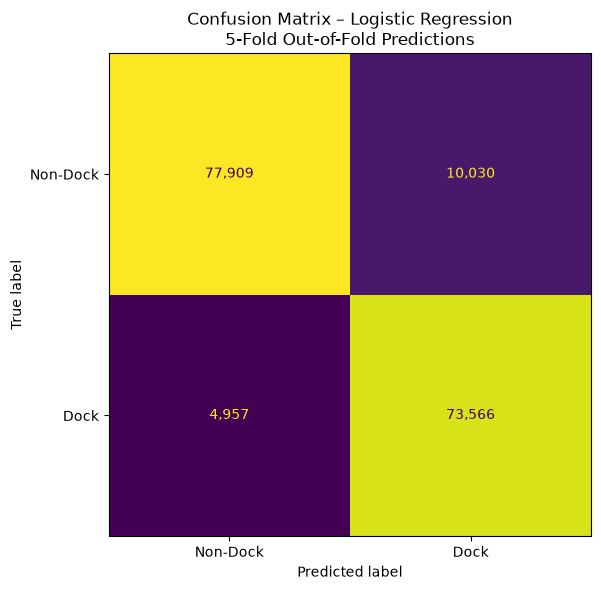

In [204]:
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-Dock",
        "Dock"
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

cm_display.plot(
    ax=ax,
    values_format=",",
    colorbar=False
)

plt.title(
    "Confusion Matrix – Logistic Regression\n"
    "5-Fold Out-of-Fold Predictions"
)

plt.tight_layout()
plt.show()

In [205]:
accuracy = accuracy_score(
    y_class,
    oof_class_predictions
)

precision = precision_score(
    y_class,
    oof_class_predictions
)

recall = recall_score(
    y_class,
    oof_class_predictions
)

f1 = f1_score(
    y_class,
    oof_class_predictions
)

false_positive_rate = (
    fp / (fp + tn)
)

false_negative_rate = (
    fn / (fn + tp)
)

specificity = (
    tn / (tn + fp)
)

confusion_metrics = pd.Series({
    "True Negatives (TN)": tn,
    "False Positives (FP)": fp,
    "False Negatives (FN)": fn,
    "True Positives (TP)": tp,

    "Accuracy": accuracy,
    "Precision": precision,
    "Recall / True Positive Rate": recall,
    "Specificity / True Negative Rate": specificity,
    "False Positive Rate": false_positive_rate,
    "False Negative Rate": false_negative_rate,
    "F1-score": f1
})

confusion_metrics.round(5)

True Negatives (TN)                 77909.00000
False Positives (FP)                10030.00000
False Negatives (FN)                 4957.00000
True Positives (TP)                 73566.00000
Accuracy                                0.90997
Precision                               0.88002
Recall / True Positive Rate             0.93687
Specificity / True Negative Rate        0.88594
False Positive Rate                     0.11406
False Negative Rate                     0.06313
F1-score                                0.90756
dtype: float64

#### False Positive and False Negative Analysis

False Positives and False Negatives represent different types of model failure.

A **False Positive (FP)** occurs when the model predicts that an observation is a dock even though the true class is non-dock.

A **False Negative (FN)** occurs when a true dock is incorrectly predicted as non-dock.

These errors are analyzed separately because their operational consequences may differ even when their numerical counts are similar.

In [206]:
false_positives = (
    classification_analysis_df[
        (
            classification_analysis_df[
                "actual_class"
            ] == 0
        )
        &
        (
            classification_analysis_df[
                "predicted_class"
            ] == 1
        )
    ]
    .copy()
)

false_negatives = (
    classification_analysis_df[
        (
            classification_analysis_df[
                "actual_class"
            ] == 1
        )
        &
        (
            classification_analysis_df[
                "predicted_class"
            ] == 0
        )
    ]
    .copy()
)

print(
    "False Positives:",
    len(false_positives)
)

print(
    "False Negatives:",
    len(false_negatives)
)

print(
    "\nFalse Positive Rate:",
    round(false_positive_rate, 4)
)

print(
    "False Negative Rate:",
    round(false_negative_rate, 4)
)

False Positives: 10030
False Negatives: 4957

False Positive Rate: 0.1141
False Negative Rate: 0.0631


In [207]:
from IPython.display import display

In [208]:
error_columns = [
    "s2id",
    "label",
    "sublabel",
    "iso3",
    "lat",
    "lon",
    "distance_from_shore_m",
    "drift_radius",
    "dock_probability",
    "actual_class",
    "predicted_class"
]

print("Examples of False Positives:")

display(
    false_positives[
        error_columns
    ].head(10)
)

print("\nExamples of False Negatives:")

display(
    false_negatives[
        error_columns
    ].head(10)
)

Examples of False Positives:


,s2id,label,sublabel,iso3,lat,lon,distance_from_shore_m,drift_radius,dock_probability,actual_class,predicted_class
133,2e65124d,CILACAP,CILACAP,IDN,-7.748381,109.042377,0.0,0.074910,0.739567,0,1
403,47b4898f,DEU-657,FERRY PELLW NORDSTR,DEU,54.501257,8.702518,2000.0,0.035579,0.880204,0,1
412,46531df5,STEVNS PIER,STEVNS PIER,DNK,55.321862,12.456259,1000.0,0.044292,0.874199,0,1
578,356ed571,JINHAE,JINHAE MAN,KOR,35.038117,128.619281,1000.0,0.090737,0.624045,0,1
591,356f2abb,JINHAE,JINHAE MAN,KOR,35.054248,128.640139,1000.0,0.115083,0.512016,0,1
599,356f2a99,JINHAE,JINHAE MAN,KOR,35.052442,128.629779,1000.0,0.083778,0.677035,0,1
601,356f2a9d,JINHAE,JINHAE MAN,KOR,35.050650,128.624465,1000.0,0.097411,0.614510,0,1
609,356ed57d,JINHAE,JINHAE MAN,KOR,35.048007,128.618777,1000.0,0.093681,0.632560,0,1
610,356ed573,JINHAE,JINHAE MAN,KOR,35.034002,128.618573,1000.0,0.090533,0.647484,0,1
615,356ed583,JINHAE,JINHAE MAN,KOR,35.046923,128.608132,1000.0,0.083513,0.669327,0,1



Examples of False Negatives:


,s2id,label,sublabel,iso3,lat,lon,distance_from_shore_m,drift_radius,dock_probability,actual_class,predicted_class
19,12982745,ESP-283,PEGUERA,ESP,39.530902,2.447647,1000.0,0.165769,0.354633,1,0
208,35ba7993,CHN-2271,35ba7993,CHN,33.281023,120.739197,6000.0,0.145948,0.001030,1,0
209,35ba7767,CHN-2271,35ba7767,CHN,33.279216,120.704481,3000.0,0.071421,0.228851,1,0
210,35ba7997,CHN-2271,35ba7997,CHN,33.274782,120.743995,5000.0,0.107961,0.009754,1,0
211,35ba79a3,CHN-2271,35ba79a3,CHN,33.269501,120.747940,6000.0,0.115179,0.002340,1,0
212,35ba79eb,CHN-2271,35ba79eb,CHN,33.279969,120.730760,5000.0,0.089500,0.016373,1,0
213,35ba79bd,CHN-2271,35ba79bd,CHN,33.271616,120.746280,6000.0,0.087403,0.004536,1,0
214,35ba7991,CHN-2271,35ba7991,CHN,33.278602,120.741394,6000.0,0.152876,0.000893,1,0
215,35ba79df,CHN-2271,35ba79df,CHN,33.276432,120.714305,4000.0,0.097721,0.044416,1,0
216,35ba79dd,CHN-2271,35ba79dd,CHN,33.275292,120.722066,4000.0,0.120787,0.028076,1,0


#### Systematic Failure by Geographic Region

The `iso3` country code is used to investigate whether classification failures are concentrated systematically in particular geographic regions.

For each country, the following quantities are calculated:

- total number of observations,
- overall classification error rate,
- False Positive Rate among actual non-dock observations,
- False Negative Rate among actual dock observations.

To reduce unstable conclusions caused by small samples, two support criteria are used:

- a country must contain at least **100 total observations** to be included in the overall regional comparison;
- a country-specific False Positive Rate is considered only when there are at least **50 actual non-dock observations**;
- a country-specific False Negative Rate is considered only when there are at least **50 actual dock observations**.

This prevents very small class-specific denominators from producing misleading extreme rates such as 100% based on only a few observations.

In [209]:
MIN_COUNTRY_OBSERVATIONS = 100
MIN_CLASS_SUPPORT = 50

country_classification_summary = []

for country, group in (
    classification_analysis_df
    .dropna(subset=["iso3"])
    .groupby("iso3")
):

    if len(group) < MIN_COUNTRY_OBSERVATIONS:
        continue

    country_cm = confusion_matrix(
        group["actual_class"],
        group["predicted_class"],
        labels=[0, 1]
    )

    country_tn, country_fp, country_fn, country_tp = (
        country_cm.ravel()
    )

    actual_non_dock = (
        country_tn + country_fp
    )

    actual_dock = (
        country_fn + country_tp
    )

    country_error_rate = (
        (country_fp + country_fn)
        / len(group)
    )

    country_fpr = (
        country_fp / actual_non_dock
        if actual_non_dock >= MIN_CLASS_SUPPORT
        else np.nan
    )

    country_fnr = (
        country_fn / actual_dock
        if actual_dock >= MIN_CLASS_SUPPORT
        else np.nan
    )

    country_classification_summary.append({
        "iso3": country,
        "observations": len(group),
        "actual_non_dock": actual_non_dock,
        "actual_dock": actual_dock,
        "error_rate": country_error_rate,
        "false_positive_rate": country_fpr,
        "false_negative_rate": country_fnr
    })


country_classification_summary = (
    pd.DataFrame(
        country_classification_summary
    )
    .set_index("iso3")
)

country_classification_summary[
    "error_rate_%"
] = (
    country_classification_summary[
        "error_rate"
    ] * 100
)

country_classification_summary[
    "FP_rate_%"
] = (
    country_classification_summary[
        "false_positive_rate"
    ] * 100
)

country_classification_summary[
    "FN_rate_%"
] = (
    country_classification_summary[
        "false_negative_rate"
    ] * 100
)

country_classification_summary = (
    country_classification_summary
    .sort_values(
        "error_rate",
        ascending=False
    )
)

country_classification_summary[
    [
        "observations",
        "actual_non_dock",
        "actual_dock",
        "error_rate_%",
        "FP_rate_%",
        "FN_rate_%"
    ]
].head(15).round(2)

,observations,actual_non_dock,actual_dock,error_rate_%,FP_rate_%,FN_rate_%
iso3,,,,,,
FJI,153,45,108,24.84,NaN,12.04
BHR,285,161,124,24.56,19.25,31.45
SGP,1072,697,375,21.27,15.64,31.73
ECU,261,177,84,21.07,20.34,22.62
CHL,592,410,182,20.44,14.15,34.62
AZE,222,157,65,20.27,4.46,58.46
BHS,366,82,284,18.85,57.32,7.75
PNG,194,122,72,18.56,15.57,23.61
KOR,3225,1922,1303,15.91,16.34,15.27


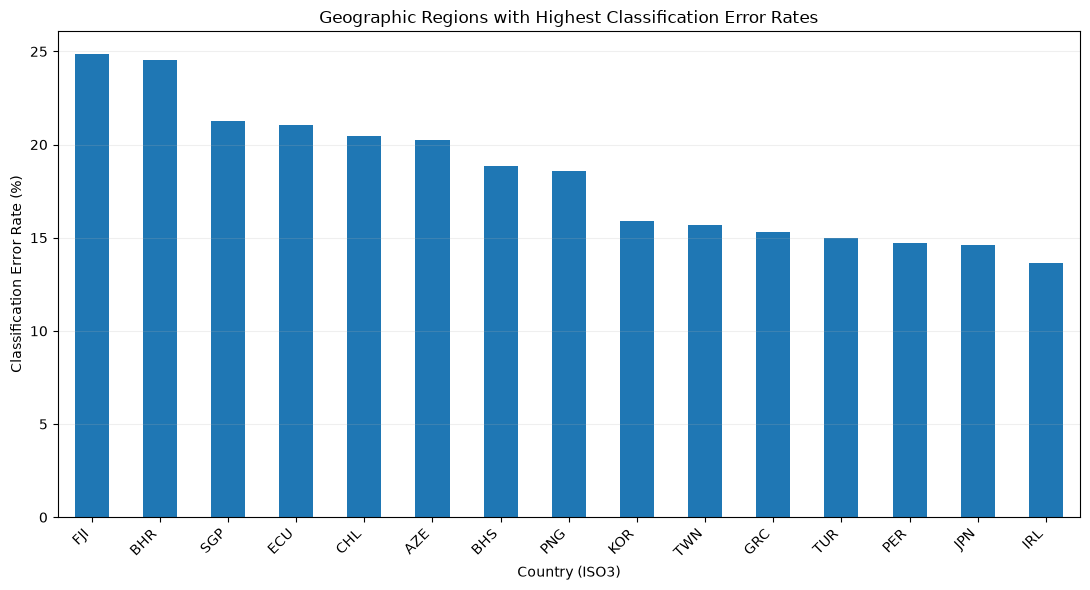

In [210]:
top_failure_regions = (
    country_classification_summary
    .head(15)
)

plt.figure(
    figsize=(11, 6)
)

top_failure_regions[
    "error_rate_%"
].plot(
    kind="bar"
)

plt.ylabel(
    "Classification Error Rate (%)"
)

plt.xlabel(
    "Country (ISO3)"
)

plt.title(
    "Geographic Regions with Highest Classification Error Rates"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

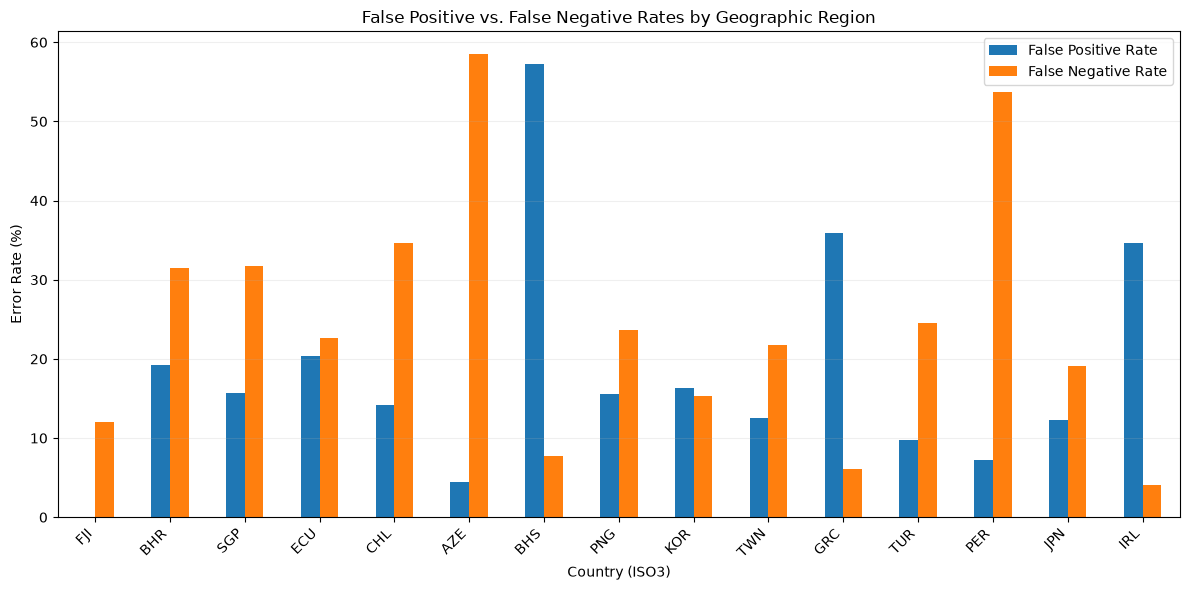

In [211]:
top_failure_regions[
    [
        "FP_rate_%",
        "FN_rate_%"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel(
    "Error Rate (%)"
)

plt.xlabel(
    "Country (ISO3)"
)

plt.title(
    "False Positive vs. False Negative Rates by Geographic Region"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    [
        "False Positive Rate",
        "False Negative Rate"
    ]
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [212]:
highest_error_region = (
    country_classification_summary[
        "error_rate"
    ]
    .idxmax()
)

fp_supported_regions = (
    country_classification_summary
    .dropna(
        subset=["false_positive_rate"]
    )
)

fn_supported_regions = (
    country_classification_summary
    .dropna(
        subset=["false_negative_rate"]
    )
)

highest_fp_region = (
    fp_supported_regions[
        "false_positive_rate"
    ]
    .idxmax()
)

highest_fn_region = (
    fn_supported_regions[
        "false_negative_rate"
    ]
    .idxmax()
)

print(
    "Highest overall error region:",
    highest_error_region
)

print(
    "Highest False Positive rate region "
    f"(minimum {MIN_CLASS_SUPPORT} actual non-docks):",
    highest_fp_region
)

print(
    "Highest False Negative rate region "
    f"(minimum {MIN_CLASS_SUPPORT} actual docks):",
    highest_fn_region
)

Highest overall error region: FJI
Highest False Positive rate region (minimum 50 actual non-docks): NOR
Highest False Negative rate region (minimum 50 actual docks): AZE


In [213]:
from IPython.display import Markdown, display

highest_region_error = (
    country_classification_summary
    .loc[
        highest_error_region,
        "error_rate"
    ]
)

highest_region_fp = (
    country_classification_summary
    .loc[
        highest_fp_region,
        "false_positive_rate"
    ]
)

highest_region_fn = (
    country_classification_summary
    .loc[
        highest_fn_region,
        "false_negative_rate"
    ]
)

highest_fp_support = int(
    country_classification_summary
    .loc[
        highest_fp_region,
        "actual_non_dock"
    ]
)

highest_fn_support = int(
    country_classification_summary
    .loc[
        highest_fn_region,
        "actual_dock"
    ]
)

classification_results_text = f"""
#### Confusion Matrix Interpretation

The 5-fold out-of-fold confusion matrix contains:

- **True Negatives (TN): {tn:,}**
- **False Positives (FP): {fp:,}**
- **False Negatives (FN): {fn:,}**
- **True Positives (TP): {tp:,}**

The overall classification accuracy is **{accuracy:.3f}**.

The False Positive Rate is approximately **{false_positive_rate * 100:.2f}%**, while the False Negative Rate is approximately **{false_negative_rate * 100:.2f}%**.

These values show that the model does not make the two types of classification error at exactly the same rate.


#### Geographic Failure Patterns

Classification performance is not uniform across geographic regions.

Among countries containing at least 100 observations, **{highest_error_region}** has the highest overall classification error rate, approximately **{highest_region_error * 100:.2f}%**.

For class-specific error rates, a minimum support of 50 observations from the relevant true class was required.

Among countries meeting this requirement, the highest False Positive Rate is observed for **{highest_fp_region}**, approximately **{highest_region_fp * 100:.2f}%**, based on **{highest_fp_support:,} actual non-dock observations**.

The highest False Negative Rate is observed for **{highest_fn_region}**, approximately **{highest_region_fn * 100:.2f}%**, based on **{highest_fn_support:,} actual dock observations**.

This provides stronger evidence of systematic regional failure than reporting extreme percentages derived from only a few class-specific observations.
"""

display(
    Markdown(
        classification_results_text
    )
)


#### Confusion Matrix Interpretation

The 5-fold out-of-fold confusion matrix contains:

- **True Negatives (TN): 77,909**
- **False Positives (FP): 10,030**
- **False Negatives (FN): 4,957**
- **True Positives (TP): 73,566**

The overall classification accuracy is **0.910**.

The False Positive Rate is approximately **11.41%**, while the False Negative Rate is approximately **6.31%**.

These values show that the model does not make the two types of classification error at exactly the same rate.


#### Geographic Failure Patterns

Classification performance is not uniform across geographic regions.

Among countries containing at least 100 observations, **FJI** has the highest overall classification error rate, approximately **24.84%**.

For class-specific error rates, a minimum support of 50 observations from the relevant true class was required.

Among countries meeting this requirement, the highest False Positive Rate is observed for **NOR**, approximately **68.15%**, based on **292 actual non-dock observations**.

The highest False Negative Rate is observed for **AZE**, approximately **58.46%**, based on **65 actual dock observations**.

This provides stronger evidence of systematic regional failure than reporting extreme percentages derived from only a few class-specific observations.


#### Discussion

**1. Which type of error is most critical in this context?**

The dataset itself does not provide an explicit cost function that defines whether a False Positive or a False Negative is universally more serious.

However, under an operational interpretation in which the classifier is used to identify locations that can be treated as docks, a **False Positive can be considered the more safety-sensitive error**.

A False Positive means that the model identifies a non-dock observation as a dock. If such a prediction were used for navigation, planning, or operational decision-making, it could incorrectly suggest that docking capability exists where it does not.

A False Negative has a different consequence: an actual dock is missed by the model. This reduces coverage and may cause a valid docking location to be overlooked, but it does not falsely indicate the existence of a dock.

Therefore, under this operational interpretation, reducing False Positives would be particularly important.

This conclusion is context-dependent. If the application instead prioritizes finding every possible dock, then False Negatives could become the more important error.


**2. In which regions does the model fail systematically?**

The country-level analysis demonstrates that error rates differ substantially between geographic regions.

Some countries exhibit higher overall classification error rates, while others are specifically associated with elevated False Positive or False Negative rates.

This indicates that the classifier does not generalize equally well across all geographic subpopulations.

Possible explanations include regional differences in anchorage structure, the relationship between `drift_radius`, distance from shore, and dock status, differences in data composition, or important geographic information that is not represented by the current feature set.

The analysis identifies where these failures occur, but it does not by itself establish a causal explanation for the regional differences.


**3. What insights can be derived from the analysis?**

Several important insights emerge from the confusion-matrix analysis.

First, a single overall accuracy value is not sufficient to describe classifier behavior. False Positives and False Negatives represent different failure modes and may have different practical consequences.

Second, classification errors are not distributed uniformly across the dataset. Certain geographic subpopulations show substantially higher error rates, indicating systematic rather than purely random model failures.

Third, the existence of different False Positive and False Negative rates suggests that the default probability threshold of 0.5 may not necessarily be the optimal operating point for every application.

Finally, the analysis indicates that model evaluation should consider both overall predictive performance and the behavior of specific subgroups. A model that appears accurate on average can still perform poorly in particular regions or for particular classes.

These findings motivate the probability-based and threshold-sensitivity analyses performed in the following sections.

#### Section 3.1 Conclusion

The confusion matrix provides a detailed view of the classification behavior that cannot be obtained from accuracy alone.

The analysis distinguishes between False Positives and False Negatives, evaluates their practical implications, and identifies geographic subpopulations in which the classifier fails systematically.

The results demonstrate that classification performance depends not only on the overall model but also on the type of error, the operating threshold, and the region of the feature space being evaluated.

### 3.2 Probability-Based Analysis

The objective of this section is to examine the confidence of the classifier and determine whether incorrect predictions occur even when the model appears highly confident.

The analysis uses the out-of-fold probabilities generated during the same 5-fold stratified cross-validation procedure used in Section 3.1.

For every observation, the Logistic Regression model produced a probability:

**P(Dock)**

Using the default classification threshold of 0.5:

- if `P(Dock) >= 0.5`, the predicted class is Dock;
- if `P(Dock) < 0.5`, the predicted class is Non-Dock.

To compare model confidence fairly across both predicted classes, the confidence assigned to the predicted class is also calculated.

A correct high-confidence prediction indicates that the model is both confident and accurate.

A high-confidence error is more concerning because the model is not merely uncertain—it assigns strong confidence to the wrong class.

In [214]:
required_columns = [
    "actual_class",
    "predicted_class",
    "dock_probability",
    "correct_prediction"
]

missing_columns = [
    column
    for column in required_columns
    if column not in classification_analysis_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}. "
        "Run Section 3.1 first."
    )

classification_analysis_df[
    "prediction_confidence"
] = np.where(
    classification_analysis_df[
        "predicted_class"
    ] == 1,
    classification_analysis_df[
        "dock_probability"
    ],
    1 - classification_analysis_df[
        "dock_probability"
    ]
)

classification_analysis_df[
    [
        "actual_class",
        "predicted_class",
        "dock_probability",
        "prediction_confidence",
        "correct_prediction"
    ]
].head()

,actual_class,predicted_class,dock_probability,prediction_confidence,correct_prediction
0,1,1,0.934914,0.934914,True
1,1,1,0.589813,0.589813,True
2,1,1,0.910334,0.910334,True
3,0,0,0.491661,0.508339,True
4,0,0,0.480204,0.519796,True


#### Predicted Confidence for Correct vs. Incorrect Predictions

The confidence distributions of correct and incorrect predictions are compared.

If incorrect predictions generally have confidence values close to 0.5, the model mainly fails when it is uncertain.

However, if incorrect predictions also occur at probabilities close to 1.0 for the predicted class, this indicates **high-confidence errors**.

Such errors are especially important because confidence alone would not provide a reliable warning that the prediction is incorrect.

In [215]:
probability_comparison = (
    classification_analysis_df
    .groupby("correct_prediction")
    .agg(
        observations=(
            "prediction_confidence",
            "size"
        ),
        mean_confidence=(
            "prediction_confidence",
            "mean"
        ),
        median_confidence=(
            "prediction_confidence",
            "median"
        ),
        confidence_std=(
            "prediction_confidence",
            "std"
        ),
        mean_dock_probability=(
            "dock_probability",
            "mean"
        )
    )
)

probability_comparison.index = [
    "Incorrect",
    "Correct"
]

probability_comparison.round(4)

,observations,mean_confidence,median_confidence,confidence_std,mean_dock_probability
Incorrect,14987,0.7226,0.7090,0.1421,0.5874
Correct,151475,0.9132,0.9627,0.1147,0.4603


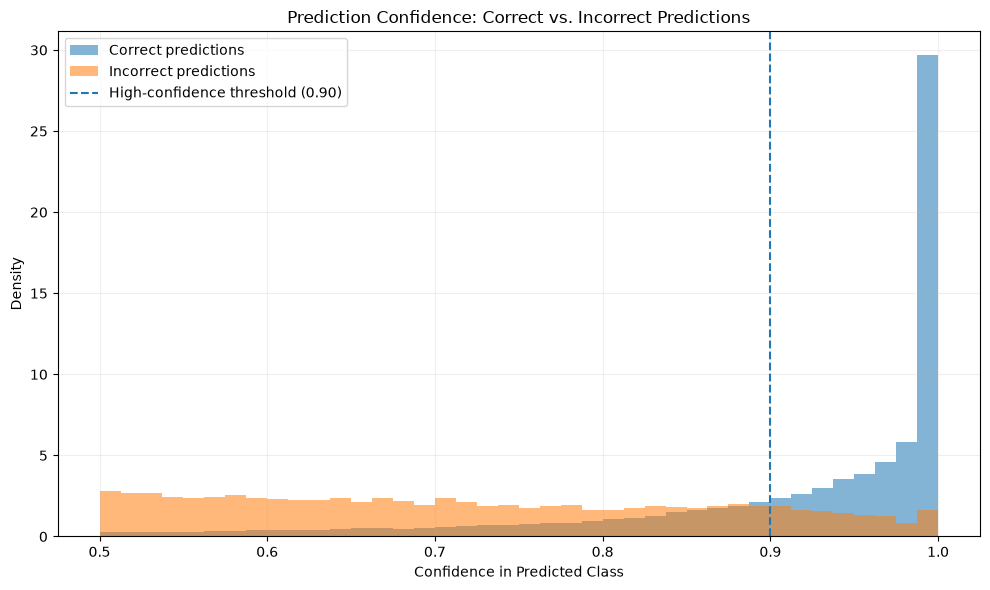

In [216]:
correct_confidence = (
    classification_analysis_df.loc[
        classification_analysis_df[
            "correct_prediction"
        ],
        "prediction_confidence"
    ]
)

incorrect_confidence = (
    classification_analysis_df.loc[
        ~classification_analysis_df[
            "correct_prediction"
        ],
        "prediction_confidence"
    ]
)

plt.figure(figsize=(10, 6))

plt.hist(
    correct_confidence,
    bins=40,
    alpha=0.55,
    density=True,
    label="Correct predictions"
)

plt.hist(
    incorrect_confidence,
    bins=40,
    alpha=0.55,
    density=True,
    label="Incorrect predictions"
)

plt.axvline(
    x=0.90,
    linestyle="--",
    linewidth=1.5,
    label="High-confidence threshold (0.90)"
)

plt.xlabel("Confidence in Predicted Class")
plt.ylabel("Density")
plt.title(
    "Prediction Confidence: Correct vs. Incorrect Predictions"
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

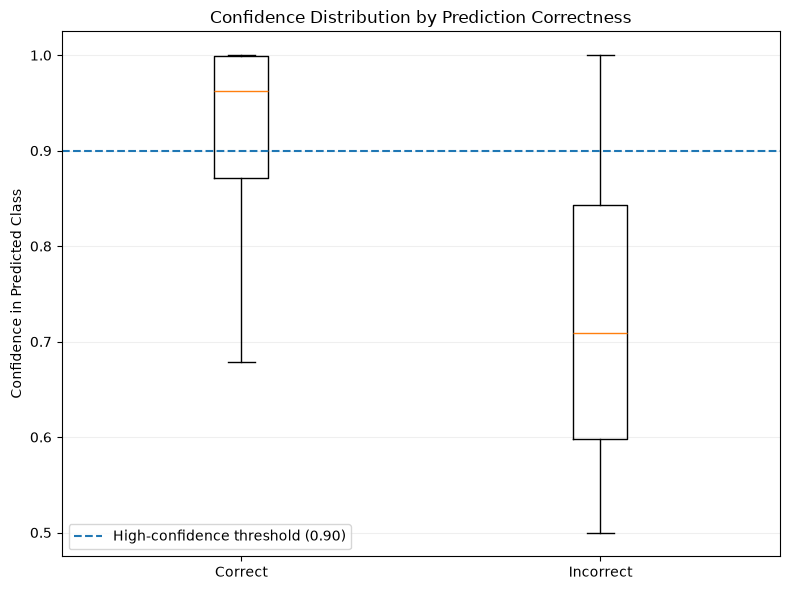

In [217]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        correct_confidence,
        incorrect_confidence
    ],
    tick_labels=[
        "Correct",
        "Incorrect"
    ],
    showfliers=False
)

plt.axhline(
    y=0.90,
    linestyle="--",
    linewidth=1.5,
    label="High-confidence threshold (0.90)"
)

plt.ylabel("Confidence in Predicted Class")
plt.title(
    "Confidence Distribution by Prediction Correctness"
)

plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

#### Identification of High-Confidence Errors

For this analysis, a prediction is defined as **high-confidence** when the probability assigned to the predicted class is at least **0.90**.

Therefore, a high-confidence error satisfies both conditions:

1. the predicted class is incorrect;
2. the model assigns at least 90% probability to that incorrect predicted class.

A 0.90 threshold is used as a clear operational definition of strong confidence.

Additional thresholds are also examined to verify whether the conclusions depend strongly on this particular cutoff.

In [218]:
high_confidence_threshold = 0.90

high_confidence_errors = (
    classification_analysis_df[
        (
            ~classification_analysis_df[
                "correct_prediction"
            ]
        )
        &
        (
            classification_analysis_df[
                "prediction_confidence"
            ] >= high_confidence_threshold
        )
    ]
    .copy()
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
)

incorrect_predictions = (
    ~classification_analysis_df[
        "correct_prediction"
    ]
).sum()

print(
    "Total incorrect predictions:",
    f"{incorrect_predictions:,}"
)

print(
    "High-confidence errors (confidence >= 0.90):",
    f"{len(high_confidence_errors):,}"
)

print(
    "High-confidence errors as % of all errors:",
    f"{100 * len(high_confidence_errors) / incorrect_predictions:.2f}%"
)

print(
    "High-confidence errors as % of all observations:",
    f"{100 * len(high_confidence_errors) / len(classification_analysis_df):.2f}%"
)

Total incorrect predictions: 14,987
High-confidence errors (confidence >= 0.90): 2,165
High-confidence errors as % of all errors: 14.45%
High-confidence errors as % of all observations: 1.30%


#### Sensitivity to the Definition of High Confidence

A single confidence cutoff is somewhat arbitrary.

Therefore, the number and rate of incorrect predictions are also examined at confidence thresholds of 0.80, 0.90, 0.95, and 0.99.

This determines whether highly confident errors persist even under increasingly strict definitions of confidence.

In [219]:
confidence_thresholds = [
    0.80,
    0.90,
    0.95,
    0.99
]

high_confidence_summary = []

for threshold in confidence_thresholds:

    confident_predictions = (
        classification_analysis_df[
            "prediction_confidence"
        ] >= threshold
    )

    confident_errors = (
        confident_predictions
        &
        (
            ~classification_analysis_df[
                "correct_prediction"
            ]
        )
    )

    number_confident = (
        confident_predictions.sum()
    )

    number_errors = (
        confident_errors.sum()
    )

    error_rate_among_confident = (
        number_errors
        / number_confident
        * 100
        if number_confident > 0
        else np.nan
    )

    percent_of_all_errors = (
        number_errors
        / incorrect_predictions
        * 100
        if incorrect_predictions > 0
        else np.nan
    )

    high_confidence_summary.append({
        "Confidence Threshold": threshold,
        "Confident Predictions": number_confident,
        "Incorrect Confident Predictions": number_errors,
        "Error Rate Among Confident (%)":
            error_rate_among_confident,
        "Percentage of All Errors (%)":
            percent_of_all_errors
    })

high_confidence_summary = pd.DataFrame(
    high_confidence_summary
)

high_confidence_summary.round(3)

,Confidence Threshold,Confident Predictions,Incorrect Confident Predictions,Error Rate Among Confident (%),Percentage of All Errors (%)
0,0.80,133366,4897,3.672,32.675
1,0.90,107227,2165,2.019,14.446
2,0.95,84119,953,1.133,6.359
3,0.99,53964,289,0.536,1.928


In [220]:
high_confidence_errors[
    "error_type"
] = np.where(
    (
        high_confidence_errors[
            "actual_class"
        ] == 0
    )
    &
    (
        high_confidence_errors[
            "predicted_class"
        ] == 1
    ),
    "False Positive",
    "False Negative"
)

high_confidence_error_types = (
    high_confidence_errors[
        "error_type"
    ]
    .value_counts()
    .to_frame("Count")
)

high_confidence_error_types[
    "Percentage"
] = (
    high_confidence_error_types[
        "Count"
    ]
    / len(high_confidence_errors)
    * 100
)

high_confidence_error_types.round(2)

,Count,Percentage
error_type,,
False Positive,1489,68.78
False Negative,676,31.22


#### Individual High-Confidence Errors

The most confident incorrect predictions are inspected individually.

These observations are particularly important because the model assigns strong probability to a class that is objectively incorrect according to the available target label.

Examining these cases can reveal recurring geographic, feature-based, or labeling patterns that are hidden by aggregate performance metrics.

In [221]:
high_confidence_error_columns = [
    "s2id",
    "label",
    "sublabel",
    "iso3",
    "lat",
    "lon",
    "distance_from_shore_m",
    "drift_radius",
    "actual_class",
    "predicted_class",
    "dock_probability",
    "prediction_confidence",
    "error_type"
]

display(
    high_confidence_errors[
        high_confidence_error_columns
    ].head(20)
)

,s2id,label,sublabel,iso3,lat,lon,distance_from_shore_m,drift_radius,actual_class,predicted_class,dock_probability,prediction_confidence,error_type
30331,35be9137,CHN-99,35be9137,CHN,35.141964,119.906469,42000.0,0.114232,1,0,4.042989e-23,1.0,False Negative
58718,6c2860f3,NCL-1,NADI FIJI,FRA,-22.773229,166.800943,34000.0,0.069522,1,0,9.867106e-19,1.0,False Negative
27732,35bebc2f,CHN-164,35bebc2f,CHN,35.010941,119.890483,46000.0,0.094993,1,0,3.771399e-25,1.0,False Negative
58717,6c2860f5,NCL-1,BF,FRA,-22.778255,166.798597,35000.0,0.069417,1,0,3.376873e-19,1.0,False Negative
10125,3e5c6ef9,ZAKUM FIELD,AUH OFFSHORE,ARE,24.861673,53.613834,54000.0,0.125642,1,0,1.713680e-29,1.0,False Negative
10145,3e5c6d19,ZAKUM FIELD,ZAKUM SRV,ARE,24.901349,53.714524,60000.0,0.071677,1,0,1.872547e-33,1.0,False Negative
10144,3e5c6d25,ZAKUM FIELD,ZAKUM,ARE,24.903384,53.723129,60000.0,0.064754,1,0,6.046456e-32,1.0,False Negative
10147,3e5c6d23,ZAKUM FIELD,ZAKUM SRV,ARE,24.900388,53.717011,60000.0,0.088282,1,0,1.329628e-33,1.0,False Negative
10154,3e5c6d17,ZAKUM FIELD,ZAKUM FIELD,ARE,24.905606,53.712934,60000.0,0.065900,1,0,1.099038e-33,1.0,False Negative
149643,3597765f,QIANLIYAN,QINGDAO,CHN,36.264240,121.381131,41000.0,0.111307,1,0,1.790224e-23,1.0,False Negative


#### Geographic Concentration of High-Confidence Errors

High-confidence errors are also examined across countries.

A systematic geographic concentration would indicate that the classifier is not merely uncertain in particular regions; instead, it may have learned a strongly incorrect relationship for specific geographic subpopulations.

Only countries containing at least 100 total classification observations are considered to avoid drawing strong conclusions from very small groups.

In [222]:
country_total_counts = (
    classification_analysis_df
    .dropna(subset=["iso3"])
    .groupby("iso3")
    .size()
    .rename("total_observations")
)

country_high_confidence_errors = (
    high_confidence_errors
    .dropna(subset=["iso3"])
    .groupby("iso3")
    .size()
    .rename("high_confidence_errors")
)

country_high_confidence_summary = (
    pd.concat(
        [
            country_total_counts,
            country_high_confidence_errors
        ],
        axis=1
    )
    .fillna(0)
)

country_high_confidence_summary = (
    country_high_confidence_summary[
        country_high_confidence_summary[
            "total_observations"
        ] >= 100
    ]
    .copy()
)

country_high_confidence_summary[
    "high_confidence_error_rate_%"
] = (
    country_high_confidence_summary[
        "high_confidence_errors"
    ]
    /
    country_high_confidence_summary[
        "total_observations"
    ]
    * 100
)

country_high_confidence_summary = (
    country_high_confidence_summary
    .sort_values(
        "high_confidence_error_rate_%",
        ascending=False
    )
)

country_high_confidence_summary.head(15).round(3)

,total_observations,high_confidence_errors,high_confidence_error_rate_%
iso3,,,
SGP,1072,64.0,5.970
ATG,105,6.0,5.714
BHR,285,14.0,4.912
QAT,482,23.0,4.772
VIR,100,4.0,4.000
PAK,103,4.0,3.883
FRA,3434,131.0,3.815
FJI,153,5.0,3.268
BHS,366,10.0,2.732


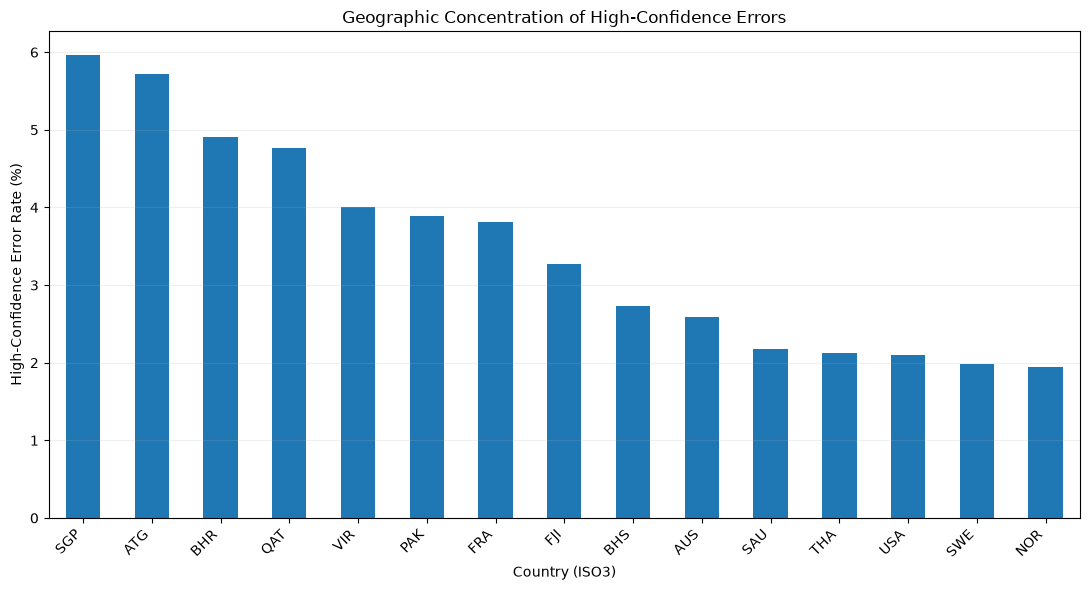

In [223]:
top_high_confidence_regions = (
    country_high_confidence_summary
    .head(15)
)

plt.figure(figsize=(11, 6))

top_high_confidence_regions[
    "high_confidence_error_rate_%"
].plot(
    kind="bar"
)

plt.xlabel("Country (ISO3)")
plt.ylabel(
    "High-Confidence Error Rate (%)"
)

plt.title(
    "Geographic Concentration of High-Confidence Errors"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [224]:
correct_mean_confidence = (
    correct_confidence.mean()
)

incorrect_mean_confidence = (
    incorrect_confidence.mean()
)

correct_median_confidence = (
    correct_confidence.median()
)

incorrect_median_confidence = (
    incorrect_confidence.median()
)

highest_conf_error = (
    high_confidence_errors[
        "prediction_confidence"
    ].max()
    if len(high_confidence_errors) > 0
    else np.nan
)

high_conf_fp = (
    high_confidence_errors[
        "error_type"
    ] == "False Positive"
).sum()

high_conf_fn = (
    high_confidence_errors[
        "error_type"
    ] == "False Negative"
).sum()

probability_summary = pd.Series({
    "Mean confidence - correct":
        correct_mean_confidence,

    "Mean confidence - incorrect":
        incorrect_mean_confidence,

    "Median confidence - correct":
        correct_median_confidence,

    "Median confidence - incorrect":
        incorrect_median_confidence,

    "Number of high-confidence errors":
        len(high_confidence_errors),

    "High-confidence False Positives":
        high_conf_fp,

    "High-confidence False Negatives":
        high_conf_fn,

    "Maximum confidence among errors":
        highest_conf_error
})

probability_summary.round(4)

Mean confidence - correct              0.9132
Mean confidence - incorrect            0.7226
Median confidence - correct            0.9627
Median confidence - incorrect          0.7090
Number of high-confidence errors    2165.0000
High-confidence False Positives     1489.0000
High-confidence False Negatives      676.0000
Maximum confidence among errors        1.0000
dtype: float64

In [225]:
from IPython.display import Markdown, display

high_conf_error_count = (
    len(high_confidence_errors)
)

high_conf_error_percentage = (
    high_conf_error_count
    / incorrect_predictions
    * 100
    if incorrect_predictions > 0
    else 0
)

if len(
    country_high_confidence_summary
) > 0:

    highest_hc_region = (
        country_high_confidence_summary[
            "high_confidence_error_rate_%"
        ]
        .idxmax()
    )

    highest_hc_region_rate = (
        country_high_confidence_summary
        .loc[
            highest_hc_region,
            "high_confidence_error_rate_%"
        ]
    )

else:
    highest_hc_region = "N/A"
    highest_hc_region_rate = np.nan


probability_interpretation = f"""
#### Interpretation

Correct predictions have a mean confidence of approximately **{correct_mean_confidence:.3f}**, compared with approximately **{incorrect_mean_confidence:.3f}** for incorrect predictions.

The median confidence is approximately **{correct_median_confidence:.3f}** for correct predictions and **{incorrect_median_confidence:.3f}** for incorrect predictions.

As expected, the classifier is generally more confident when it is correct. However, incorrect predictions are not restricted to observations close to the decision threshold.

Using a confidence threshold of **0.90**, the classifier produces **{high_conf_error_count:,} high-confidence errors**, representing approximately **{high_conf_error_percentage:.2f}% of all classification errors**.

Among these high-confidence errors:

- **{high_conf_fp:,} are False Positives**
- **{high_conf_fn:,} are False Negatives**

The most confident incorrect prediction has a confidence of approximately **{highest_conf_error:.3f}**.

Therefore, the model occasionally assigns strong confidence to incorrect predictions. These cases are particularly important because a decision system relying only on the reported probability could treat them as highly reliable predictions even though they are wrong.

The geographic analysis also shows that high-confidence errors are not necessarily distributed uniformly across the dataset. Among countries with at least 100 observations, **{highest_hc_region}** has the highest high-confidence error rate, approximately **{highest_hc_region_rate:.2f}%**.

This suggests that model confidence should not be interpreted independently of subgroup performance.
"""

display(
    Markdown(
        probability_interpretation
    )
)


#### Interpretation

Correct predictions have a mean confidence of approximately **0.913**, compared with approximately **0.723** for incorrect predictions.

The median confidence is approximately **0.963** for correct predictions and **0.709** for incorrect predictions.

As expected, the classifier is generally more confident when it is correct. However, incorrect predictions are not restricted to observations close to the decision threshold.

Using a confidence threshold of **0.90**, the classifier produces **2,165 high-confidence errors**, representing approximately **14.45% of all classification errors**.

Among these high-confidence errors:

- **1,489 are False Positives**
- **676 are False Negatives**

The most confident incorrect prediction has a confidence of approximately **1.000**.

Therefore, the model occasionally assigns strong confidence to incorrect predictions. These cases are particularly important because a decision system relying only on the reported probability could treat them as highly reliable predictions even though they are wrong.

The geographic analysis also shows that high-confidence errors are not necessarily distributed uniformly across the dataset. Among countries with at least 100 observations, **SGP** has the highest high-confidence error rate, approximately **5.97%**.

This suggests that model confidence should not be interpreted independently of subgroup performance.


#### Section 3.2 Conclusion

The probability-based analysis shows that prediction confidence contains useful information but is not a guarantee of correctness.

Correct predictions generally receive higher confidence than incorrect predictions. However, a subset of incorrect predictions still receives very high confidence.

These **high-confidence errors** are especially important because they represent cases in which the classifier is both wrong and strongly convinced of its prediction.

The analysis also indicates that confidence behavior may differ across geographic subpopulations.

Therefore, classification reliability should not be assessed using predicted probability alone. Both probability calibration and subgroup-specific error behavior should be considered when interpreting model confidence.

The existence of confident errors also motivates the threshold-sensitivity analysis performed later in Section 3.4.

### 3.3 Error as a Function of Features

The objective of this section is to determine whether classification errors are associated systematically with particular feature values or subpopulations.

The feature distributions of **correct** and **incorrect** predictions are compared.

For numerical features, the analysis examines:

- the distribution of feature values for correct and incorrect predictions,
- the misclassification rate across different regions of each feature.

For categorical features, the analysis compares:

- the relative category distributions of correct and incorrect predictions,
- the classification error rate within each category.

This analysis helps identify regions of the feature space in which model performance degrades systematically and can guide future feature engineering and model selection.

In [226]:
from IPython.display import display as ipy_display

required_33_columns = [
    "correct_prediction",
    "actual_class",
    "predicted_class",
    "lat",
    "lon",
    "distance_from_shore_m",
    "drift_radius",
    "iso3",
    "label_source"
]

missing_33_columns = [
    column
    for column in required_33_columns
    if column not in classification_analysis_df.columns
]

if missing_33_columns:
    raise ValueError(
        f"Missing required columns: {missing_33_columns}. "
        "Run Section 3.1 first."
    )

print("Section 3.3 data are ready.")
print(
    "Observations:",
    f"{len(classification_analysis_df):,}"
)

Section 3.3 data are ready.
Observations: 166,462


#### Numerical Feature Distributions

For every numerical feature, the distributions of correctly and incorrectly classified observations are compared.

If the two distributions differ substantially, the feature may help identify regions in which classification is more difficult.

The histograms are normalized to density rather than raw counts because the number of correct predictions is expected to be much larger than the number of incorrect predictions.

In [227]:
classification_numeric_features = [
    "lat",
    "lon",
    "distance_from_shore_m",
    "drift_radius"
]

correct_predictions_df = (
    classification_analysis_df[
        classification_analysis_df[
            "correct_prediction"
        ]
    ]
)

incorrect_predictions_df = (
    classification_analysis_df[
        ~classification_analysis_df[
            "correct_prediction"
        ]
    ]
)

print(
    "Correct predictions:",
    f"{len(correct_predictions_df):,}"
)

print(
    "Incorrect predictions:",
    f"{len(incorrect_predictions_df):,}"
)

Correct predictions: 151,475
Incorrect predictions: 14,987


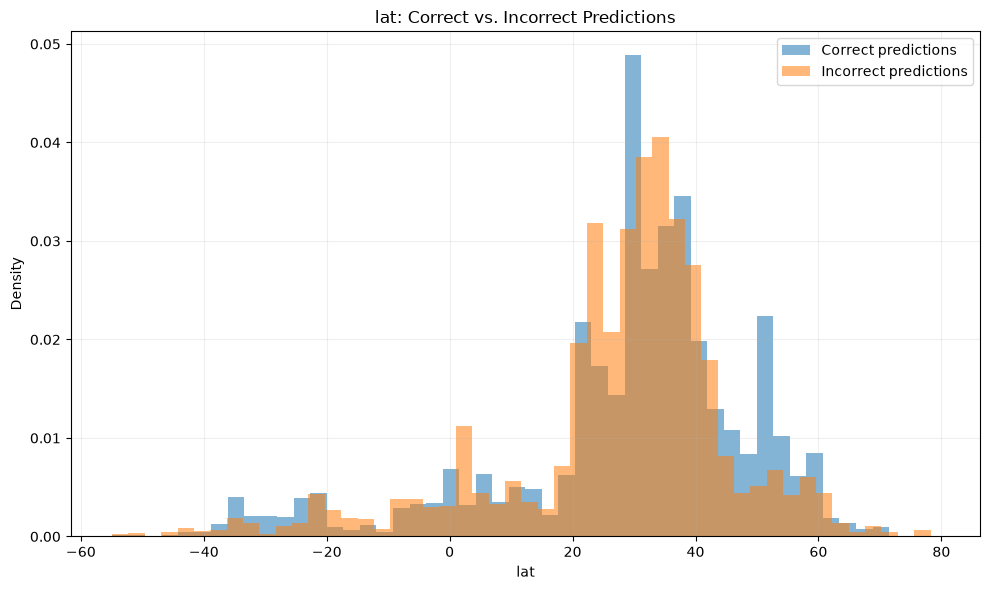

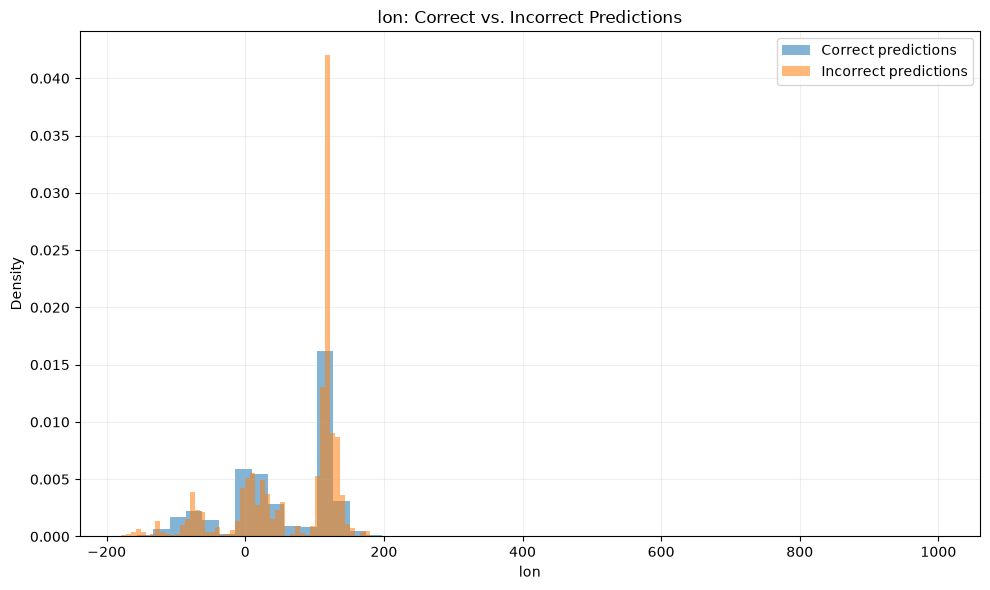

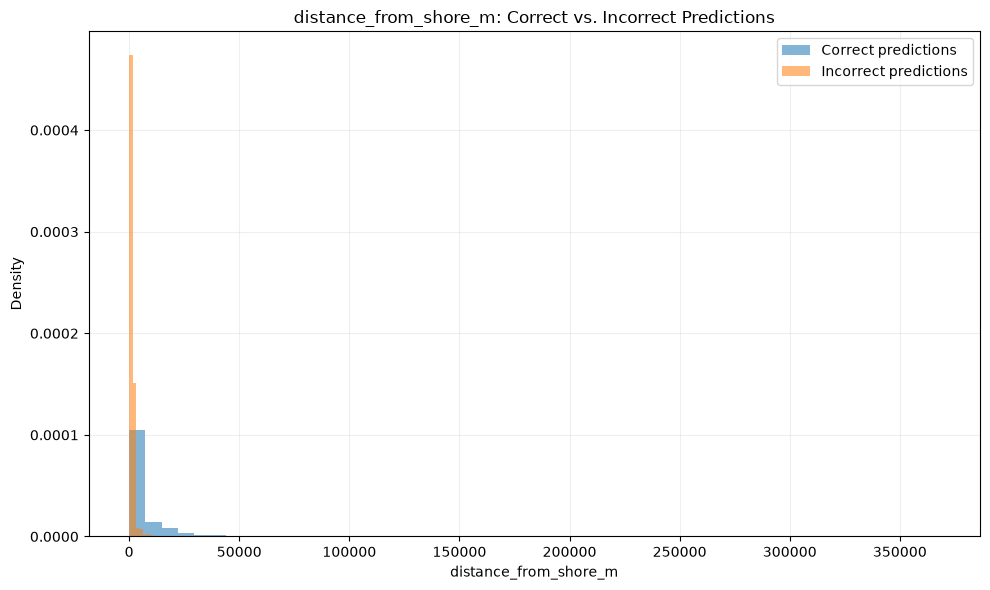

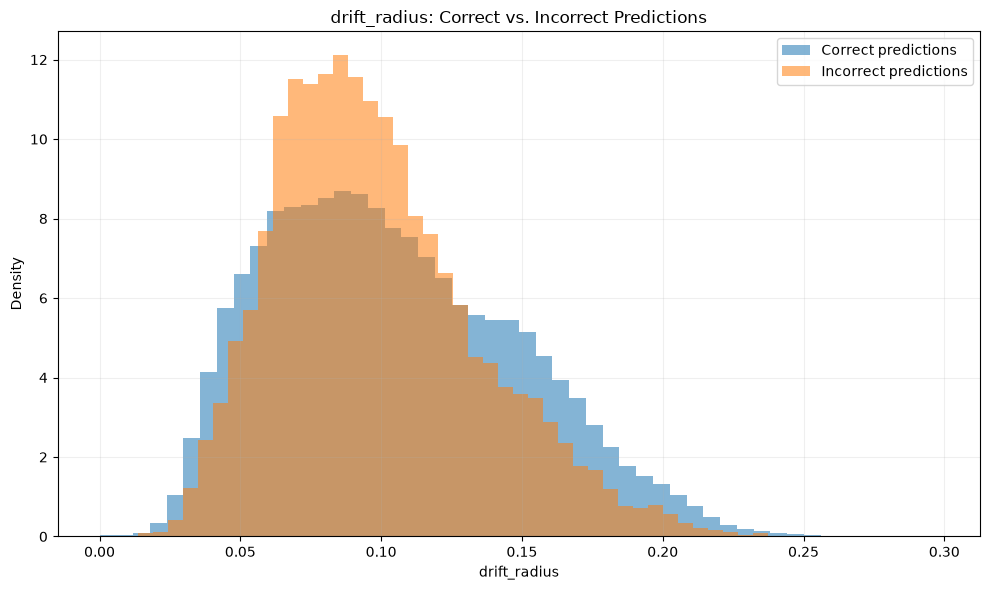

In [228]:
for feature in classification_numeric_features:

    correct_values = (
        correct_predictions_df[
            feature
        ]
        .dropna()
    )

    incorrect_values = (
        incorrect_predictions_df[
            feature
        ]
        .dropna()
    )

    plt.figure(figsize=(10, 6))

    plt.hist(
        correct_values,
        bins=50,
        density=True,
        alpha=0.55,
        label="Correct predictions"
    )

    plt.hist(
        incorrect_values,
        bins=50,
        density=True,
        alpha=0.55,
        label="Incorrect predictions"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")

    plt.title(
        f"{feature}: Correct vs. Incorrect Predictions"
    )

    plt.legend()
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

#### Misclassification Rate Across Numerical Feature Regions

Visual differences between distributions do not directly show the probability of model failure.

Therefore, every numerical feature is divided into approximately ten equal-frequency regions.

For each region, the classification error rate is calculated as:

**Error Rate = Incorrect Predictions / Total Predictions**

A consistently elevated error rate in a particular feature region indicates systematic performance degradation rather than isolated random mistakes.

In [229]:
numerical_error_summaries = {}

for feature in classification_numeric_features:

    feature_df = (
        classification_analysis_df[
            [feature, "correct_prediction"]
        ]
        .dropna()
        .copy()
    )

    feature_df["feature_bin"] = pd.qcut(
        feature_df[feature],
        q=10,
        duplicates="drop"
    )

    feature_summary = (
        feature_df
        .groupby(
            "feature_bin",
            observed=True
        )
        .agg(
            observations=(
                "correct_prediction",
                "size"
            ),
            mean_feature=(
                feature,
                "mean"
            ),
            correct_predictions=(
                "correct_prediction",
                "sum"
            )
        )
        .reset_index(drop=True)
    )

    feature_summary[
        "incorrect_predictions"
    ] = (
        feature_summary[
            "observations"
        ]
        -
        feature_summary[
            "correct_predictions"
        ]
    )

    feature_summary[
        "error_rate_%"
    ] = (
        feature_summary[
            "incorrect_predictions"
        ]
        /
        feature_summary[
            "observations"
        ]
        * 100
    )

    numerical_error_summaries[
        feature
    ] = feature_summary

    print("\n" + "=" * 70)
    print(f"Feature: {feature}")
    print("=" * 70)

    ipy_display(
        feature_summary.round(4)
    )


Feature: lat


,observations,mean_feature,correct_predictions,incorrect_predictions,error_rate_%
0,16647,-18.6861,15208,1439,8.6442
1,16646,10.8610,14966,1680,10.0925
2,16646,23.3354,14613,2033,12.2131
3,16646,28.3922,15102,1544,9.2755
4,16646,30.7721,15686,960,5.7672
5,16646,33.6875,14369,2277,13.6790
6,16646,37.0222,14934,1712,10.2848
7,16646,40.5603,15117,1529,9.1854
8,16646,48.0031,15785,861,5.1724
9,16647,56.8031,15695,952,5.7187



Feature: lon


,observations,mean_feature,correct_predictions,incorrect_predictions,error_rate_%
0,16647,-93.7737,15368,1279,7.6831
1,16646,-27.7509,15391,1255,7.5393
2,16646,5.6903,15821,825,4.9561
3,16646,19.4119,15297,1349,8.1040
4,16646,47.9287,15609,1037,6.2297
5,16646,106.9236,14984,1662,9.9844
6,16646,116.7424,15265,1381,8.2963
7,16646,120.0655,14726,1920,11.5343
8,16646,122.0696,14588,2058,12.3633
9,16647,138.1692,14426,2221,13.3417



Feature: distance_from_shore_m


,observations,mean_feature,correct_predictions,incorrect_predictions,error_rate_%
0,87530,211.0476,76606,10924,12.4803
1,15532,2000.0000,12357,3175,20.4417
2,14997,3420.9509,14484,513,3.4207
3,16862,6320.8991,16613,249,1.4767
4,16036,11927.5380,15968,68,0.4240
5,15480,35139.5349,15429,51,0.3295



Feature: drift_radius


,observations,mean_feature,correct_predictions,incorrect_predictions,error_rate_%
0,16633,0.0408,15643,990,5.9520
1,16633,0.0578,15177,1456,8.7537
2,16633,0.0700,14631,2002,12.0363
3,16633,0.0815,14636,1997,12.0063
4,16633,0.0927,14707,1926,11.5794
5,16632,0.1046,14780,1852,11.1352
6,16633,0.1180,15032,1601,9.6254
7,16633,0.1343,15357,1276,7.6715
8,16633,0.1535,15564,1069,6.4270
9,16633,0.1862,15845,788,4.7376


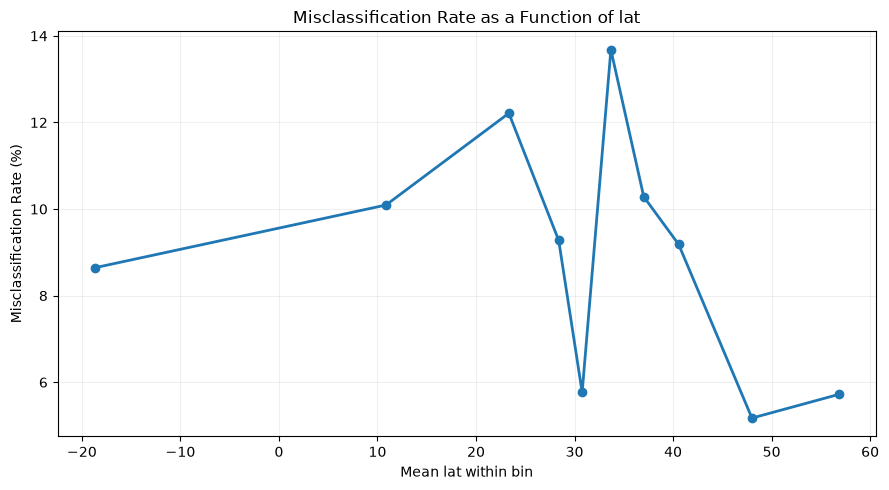

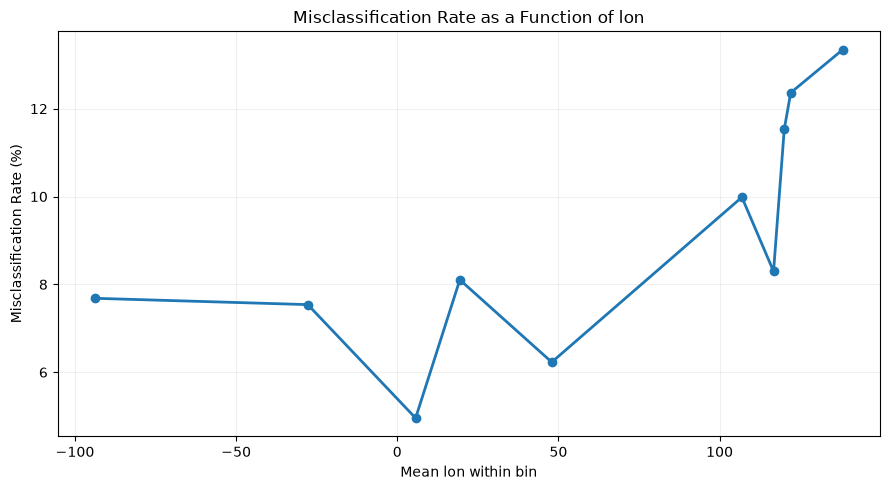

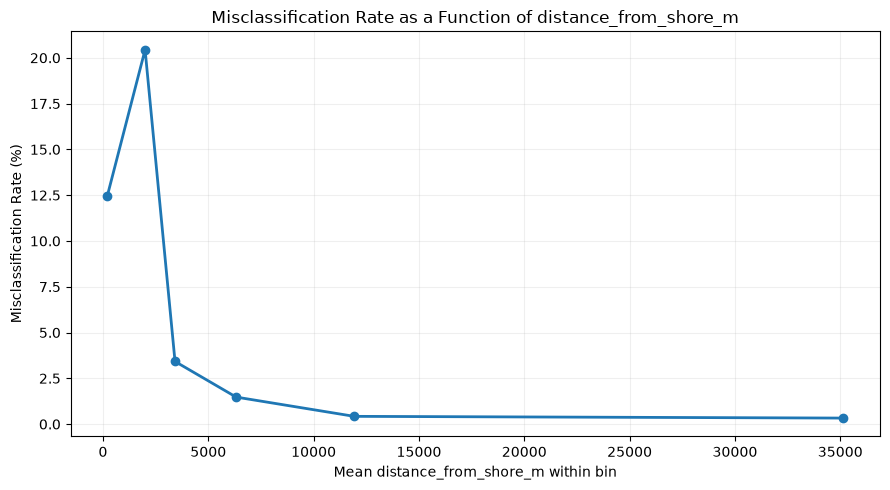

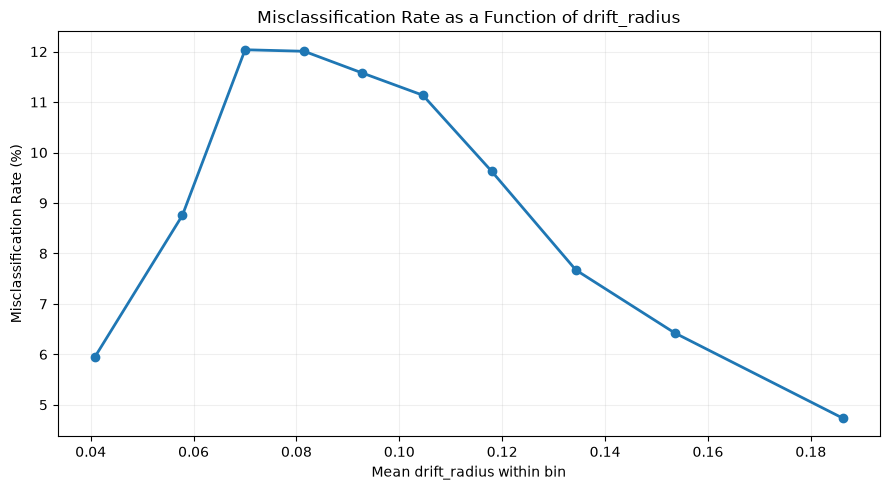

In [230]:
for feature, summary in numerical_error_summaries.items():

    plt.figure(figsize=(9, 5))

    plt.plot(
        summary["mean_feature"],
        summary["error_rate_%"],
        marker="o",
        linewidth=2
    )

    plt.xlabel(
        f"Mean {feature} within bin"
    )

    plt.ylabel(
        "Misclassification Rate (%)"
    )

    plt.title(
        f"Misclassification Rate as a Function of {feature}"
    )

    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

In [231]:
highest_error_numeric_regions = []

for feature, summary in numerical_error_summaries.items():

    worst_index = (
        summary[
            "error_rate_%"
        ]
        .idxmax()
    )

    worst_region = (
        summary.loc[
            worst_index
        ]
    )

    highest_error_numeric_regions.append({
        "Feature": feature,

        "Mean Feature Value":
            worst_region[
                "mean_feature"
            ],

        "Observations":
            worst_region[
                "observations"
            ],

        "Misclassification Rate (%)":
            worst_region[
                "error_rate_%"
            ]
    })

highest_error_numeric_regions = (
    pd.DataFrame(
        highest_error_numeric_regions
    )
    .sort_values(
        "Misclassification Rate (%)",
        ascending=False
    )
)

highest_error_numeric_regions.round(4)

,Feature,Mean Feature Value,Observations,Misclassification Rate (%)
2,distance_from_shore_m,2000.0000,15532.0,20.4417
0,lat,33.6875,16646.0,13.6790
1,lon,138.1692,16647.0,13.3417
3,drift_radius,0.0700,16633.0,12.0363


#### Categorical Feature Distributions

The categorical features are analyzed separately.

For each categorical variable, the analysis compares:

1. how frequently each category appears among correct and incorrect predictions;
2. the actual misclassification rate within each category.

A category that appears frequently among errors may simply be common in the dataset. Therefore, the within-category error rate is especially important for identifying genuinely difficult subpopulations.

For the `label_source` error-rate comparison, only categories containing at least **100 observations** are used when ranking difficult subpopulations.

All categories remain visible in the distribution comparison, but the minimum-support criterion prevents very small groups from being interpreted as strong evidence of systematic model failure.

In [232]:
label_source_distribution = pd.crosstab(
    classification_analysis_df[
        "label_source"
    ],
    classification_analysis_df[
        "correct_prediction"
    ],
    normalize="columns"
) * 100

label_source_distribution.columns = [
    "Incorrect Distribution (%)",
    "Correct Distribution (%)"
]

label_source_distribution.round(2)

,Incorrect Distribution (%),Correct Distribution (%)
label_source,,
WPI_ports,10.34,7.77
anchorage_overrides,81.12,75.36
geonames_1000,3.40,4.73
indonesia,0.19,0.03
peru,0.02,0.00
top_destination,4.94,12.11


In [233]:
MIN_LABEL_SOURCE_OBSERVATIONS = 100

label_source_error_summary_all = (
    classification_analysis_df
    .groupby(
        "label_source"
    )
    .agg(
        observations=(
            "correct_prediction",
            "size"
        ),
        correct_predictions=(
            "correct_prediction",
            "sum"
        )
    )
)

label_source_error_summary_all[
    "incorrect_predictions"
] = (
    label_source_error_summary_all[
        "observations"
    ]
    -
    label_source_error_summary_all[
        "correct_predictions"
    ]
)

label_source_error_summary_all[
    "error_rate_%"
] = (
    label_source_error_summary_all[
        "incorrect_predictions"
    ]
    /
    label_source_error_summary_all[
        "observations"
    ]
    * 100
)

label_source_error_summary_all = (
    label_source_error_summary_all
    .sort_values(
        "error_rate_%",
        ascending=False
    )
)

label_source_error_summary = (
    label_source_error_summary_all[
        label_source_error_summary_all[
            "observations"
        ] >= MIN_LABEL_SOURCE_OBSERVATIONS
    ]
    .copy()
)

print(
    f"Label-source groups used for systematic error comparison "
    f"(minimum {MIN_LABEL_SOURCE_OBSERVATIONS} observations):"
)

label_source_error_summary.round(2)

Label-source groups used for systematic error comparison (minimum 100 observations):


,observations,correct_predictions,incorrect_predictions,error_rate_%
label_source,,,,
WPI_ports,13314,11765,1549,11.63
anchorage_overrides,126313,114156,12157,9.62
geonames_1000,7675,7166,509,6.63
top_destination,19077,18337,740,3.88


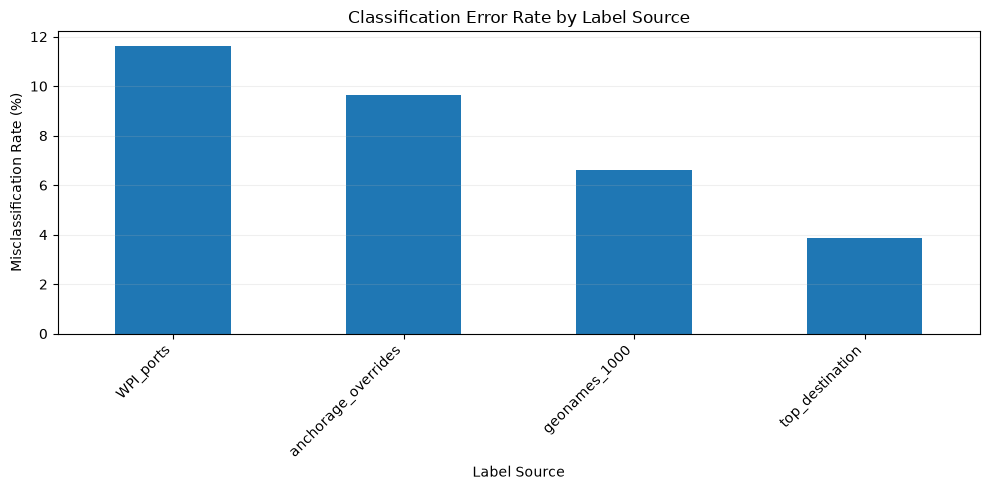

In [234]:
plt.figure(figsize=(10, 5))

label_source_error_summary[
    "error_rate_%"
].plot(
    kind="bar"
)

plt.xlabel("Label Source")
plt.ylabel(
    "Misclassification Rate (%)"
)

plt.title(
    "Classification Error Rate by Label Source"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

#### Geographic Subpopulations

Country (`iso3`) is used to investigate geographic subpopulations in which classification performance degrades.

Only countries with at least **100 observations** are included.

This prevents small groups from appearing artificially extreme because of only a few classification errors.

In [235]:
country_feature_summary = (
    classification_analysis_df
    .dropna(subset=["iso3"])
    .groupby("iso3")
    .agg(
        observations=(
            "correct_prediction",
            "size"
        ),
        correct_predictions=(
            "correct_prediction",
            "sum"
        )
    )
)

country_feature_summary[
    "incorrect_predictions"
] = (
    country_feature_summary[
        "observations"
    ]
    -
    country_feature_summary[
        "correct_predictions"
    ]
)

country_feature_summary[
    "error_rate_%"
] = (
    country_feature_summary[
        "incorrect_predictions"
    ]
    /
    country_feature_summary[
        "observations"
    ]
    * 100
)

country_feature_summary = (
    country_feature_summary[
        country_feature_summary[
            "observations"
        ] >= 100
    ]
    .sort_values(
        "error_rate_%",
        ascending=False
    )
)

country_feature_summary.head(20).round(2)

,observations,correct_predictions,incorrect_predictions,error_rate_%
iso3,,,,
FJI,153,115,38,24.84
BHR,285,215,70,24.56
SGP,1072,844,228,21.27
ECU,261,206,55,21.07
CHL,592,471,121,20.44
AZE,222,177,45,20.27
BHS,366,297,69,18.85
PNG,194,158,36,18.56
KOR,3225,2712,513,15.91


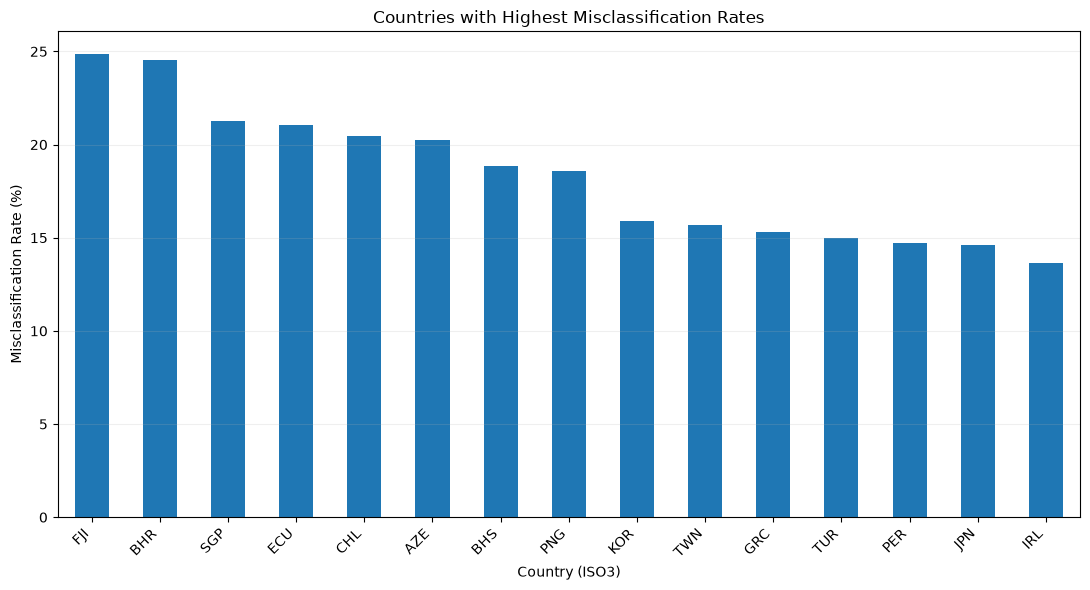

In [236]:
top_error_countries_33 = (
    country_feature_summary
    .head(15)
)

plt.figure(figsize=(11, 6))

top_error_countries_33[
    "error_rate_%"
].plot(
    kind="bar"
)

plt.xlabel(
    "Country (ISO3)"
)

plt.ylabel(
    "Misclassification Rate (%)"
)

plt.title(
    "Countries with Highest Misclassification Rates"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

#### Two-Dimensional Geographic Error Regions

Latitude and longitude may interact rather than influence classification independently.

Therefore, the geographic space is also divided into latitude–longitude cells.

For every cell containing a sufficient number of observations, the misclassification rate is calculated.

This analysis can reveal spatial regions with systematically degraded classification performance that may not be visible when latitude and longitude are analyzed separately.

In [237]:
geo_df = (
    classification_analysis_df[
        [
            "lat",
            "lon",
            "correct_prediction"
        ]
    ]
    .dropna()
    .copy()
)

lat_bins = np.linspace(
    -90,
    90,
    13
)

lon_bins = np.linspace(
    -180,
    180,
    19
)

geo_df["lat_bin"] = pd.cut(
    geo_df["lat"],
    bins=lat_bins,
    include_lowest=True
)

geo_df["lon_bin"] = pd.cut(
    geo_df["lon"],
    bins=lon_bins,
    include_lowest=True
)

geo_error_summary = (
    geo_df
    .groupby(
        ["lat_bin", "lon_bin"],
        observed=True
    )
    .agg(
        observations=(
            "correct_prediction",
            "size"
        ),
        correct_predictions=(
            "correct_prediction",
            "sum"
        )
    )
    .reset_index()
)

geo_error_summary[
    "incorrect_predictions"
] = (
    geo_error_summary[
        "observations"
    ]
    -
    geo_error_summary[
        "correct_predictions"
    ]
)

geo_error_summary[
    "error_rate_%"
] = (
    geo_error_summary[
        "incorrect_predictions"
    ]
    /
    geo_error_summary[
        "observations"
    ]
    * 100
)

# Avoid unstable conclusions from very small cells
geo_error_summary = (
    geo_error_summary[
        geo_error_summary[
            "observations"
        ] >= 100
    ]
)

geo_error_summary = (
    geo_error_summary
    .sort_values(
        "error_rate_%",
        ascending=False
    )
)

geo_error_summary.head(15).round(2)

,lat_bin,lon_bin,observations,correct_predictions,incorrect_predictions,error_rate_%
85,"(45.0, 60.0]","(-180.001, -160.0]",103,58,45,43.69
86,"(45.0, 60.0]","(-160.0, -140.0]",172,116,56,32.56
27,"(-30.0, -15.0]","(160.0, 180.0]",307,233,74,24.10
31,"(-15.0, 0.0]","(-100.0, -80.0]",209,161,48,22.97
38,"(-15.0, 0.0]","(40.0, 60.0]",105,82,23,21.90
16,"(-30.0, -15.0]","(-80.0, -60.0]",234,184,50,21.37
81,"(30.0, 45.0]","(40.0, 60.0]",883,703,180,20.39
13,"(-30.0, -15.0]","(-160.0, -140.0]",186,149,37,19.89
71,"(15.0, 30.0]","(120.0, 140.0]",6078,4940,1138,18.72
42,"(-15.0, 0.0]","(120.0, 140.0]",439,357,82,18.68


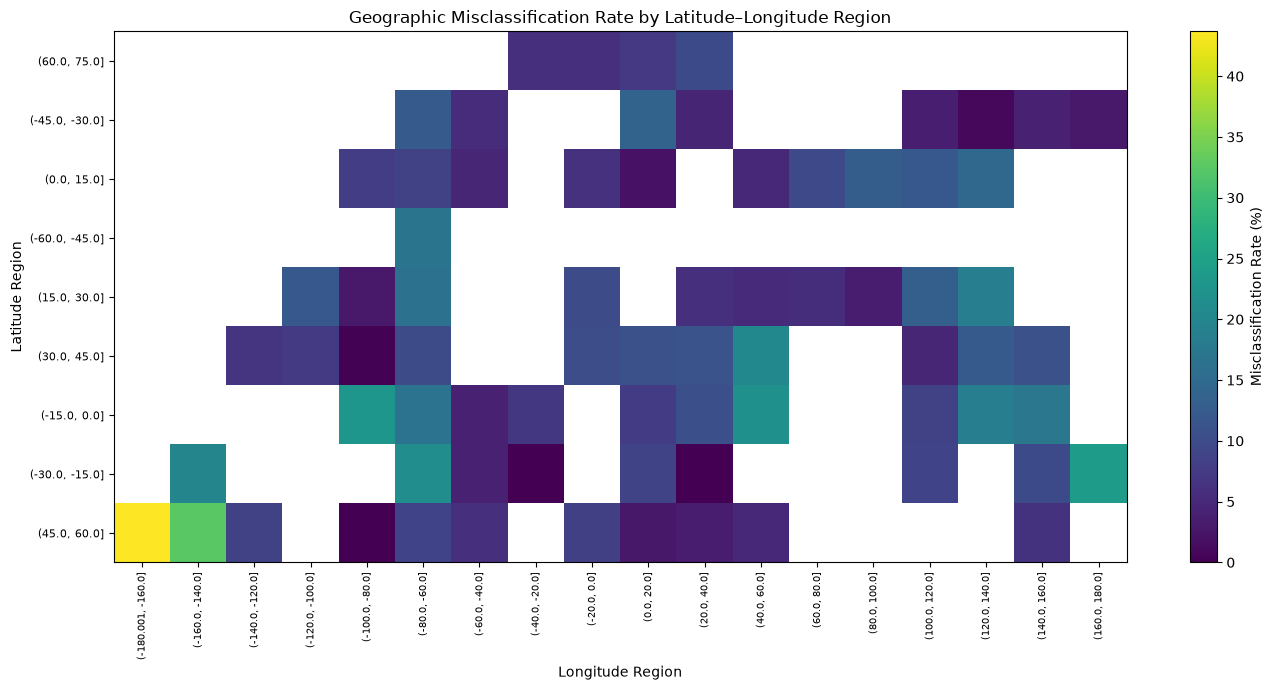

In [238]:
geo_pivot = (
    geo_error_summary
    .pivot(
        index="lat_bin",
        columns="lon_bin",
        values="error_rate_%"
    )
)

plt.figure(figsize=(14, 7))

plt.imshow(
    geo_pivot,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    label="Misclassification Rate (%)"
)

plt.xlabel(
    "Longitude Region"
)

plt.ylabel(
    "Latitude Region"
)

plt.title(
    "Geographic Misclassification Rate by Latitude–Longitude Region"
)

plt.xticks(
    ticks=np.arange(
        len(geo_pivot.columns)
    ),
    labels=[
        str(interval)
        for interval
        in geo_pivot.columns
    ],
    rotation=90,
    fontsize=7
)

plt.yticks(
    ticks=np.arange(
        len(geo_pivot.index)
    ),
    labels=[
        str(interval)
        for interval
        in geo_pivot.index
    ],
    fontsize=8
)

plt.tight_layout()
plt.show()

In [239]:
highest_error_country = (
    country_feature_summary.index[0]
)

highest_error_country_rate = (
    country_feature_summary.iloc[0][
        "error_rate_%"
    ]
)

highest_error_label_source = (
    label_source_error_summary.index[0]
)

highest_error_label_source_rate = (
    label_source_error_summary.iloc[0][
        "error_rate_%"
    ]
)

worst_geo_region = (
    geo_error_summary.iloc[0]
)

print(
    "Highest-error country:",
    highest_error_country,
    f"({highest_error_country_rate:.2f}%)"
)

print(
    "Highest-error label source:",
    highest_error_label_source,
    f"({highest_error_label_source_rate:.2f}%)"
)

print("\nHighest-error geographic cell:")

print(
    "Latitude:",
    worst_geo_region["lat_bin"]
)

print(
    "Longitude:",
    worst_geo_region["lon_bin"]
)

print(
    "Observations:",
    int(
        worst_geo_region[
            "observations"
        ]
    )
)

print(
    "Error rate:",
    f'{worst_geo_region["error_rate_%"]:.2f}%'
)

Highest-error country: FJI (24.84%)
Highest-error label source: WPI_ports (11.63%)

Highest-error geographic cell:
Latitude: (45.0, 60.0]
Longitude: (-180.001, -160.0]
Observations: 103
Error rate: 43.69%


In [240]:
numeric_findings = []

for _, row in (
    highest_error_numeric_regions
    .iterrows()
):

    numeric_findings.append(
        f"- **{row['Feature']}**: "
        f"the highest-error region has an "
        f"average feature value of approximately "
        f"**{row['Mean Feature Value']:.3f}** "
        f"and a misclassification rate of approximately "
        f"**{row['Misclassification Rate (%)']:.2f}%**."
    )

numeric_findings_text = "\n".join(
    numeric_findings
)

interpretation_33 = f"""
#### Interpretation

The comparison between correct and incorrect predictions shows that classification errors are not distributed uniformly across the feature space.

##### Numerical features

The numerical-feature distributions and binned error-rate analysis show that some feature regions are considerably more difficult for the classifier than others.

{numeric_findings_text}

This indicates that model performance depends systematically on feature values rather than being explained only by random classification noise.

In particular, changes in error rate across feature bins suggest that the relationship between the available predictors and dock status is not equally easy to model across the complete feature space.


##### Categorical subpopulations

The categorical analysis also reveals differences in classification difficulty.

The `label_source` category with the highest observed error rate is **{highest_error_label_source}**, with a misclassification rate of approximately **{highest_error_label_source_rate:.2f}%**.

Among countries containing at least 100 observations, **{highest_error_country}** has the highest classification error rate, approximately **{highest_error_country_rate:.2f}%**.

These differences show that particular data-source and geographic subpopulations are more difficult for the baseline classifier.


##### Geographic regions

The combined latitude–longitude analysis provides further evidence of spatially concentrated model failures.

The highest-error geographic cell among sufficiently represented regions is:

- Latitude region: **{worst_geo_region['lat_bin']}**
- Longitude region: **{worst_geo_region['lon_bin']}**
- Observations: **{int(worst_geo_region['observations']):,}**
- Misclassification rate: **{worst_geo_region['error_rate_%']:.2f}%**

This indicates that geographic location affects classifier reliability through more than a simple independent latitude or longitude effect.

The existence of high-error spatial regions suggests that geographic interactions or region-specific characteristics are not fully represented by the current Logistic Regression model.
"""

ipy_display(
    Markdown(
        interpretation_33
    )
)


#### Interpretation

The comparison between correct and incorrect predictions shows that classification errors are not distributed uniformly across the feature space.

##### Numerical features

The numerical-feature distributions and binned error-rate analysis show that some feature regions are considerably more difficult for the classifier than others.

- **distance_from_shore_m**: the highest-error region has an average feature value of approximately **2000.000** and a misclassification rate of approximately **20.44%**.
- **lat**: the highest-error region has an average feature value of approximately **33.687** and a misclassification rate of approximately **13.68%**.
- **lon**: the highest-error region has an average feature value of approximately **138.169** and a misclassification rate of approximately **13.34%**.
- **drift_radius**: the highest-error region has an average feature value of approximately **0.070** and a misclassification rate of approximately **12.04%**.

This indicates that model performance depends systematically on feature values rather than being explained only by random classification noise.

In particular, changes in error rate across feature bins suggest that the relationship between the available predictors and dock status is not equally easy to model across the complete feature space.


##### Categorical subpopulations

The categorical analysis also reveals differences in classification difficulty.

The `label_source` category with the highest observed error rate is **WPI_ports**, with a misclassification rate of approximately **11.63%**.

Among countries containing at least 100 observations, **FJI** has the highest classification error rate, approximately **24.84%**.

These differences show that particular data-source and geographic subpopulations are more difficult for the baseline classifier.


##### Geographic regions

The combined latitude–longitude analysis provides further evidence of spatially concentrated model failures.

The highest-error geographic cell among sufficiently represented regions is:

- Latitude region: **(45.0, 60.0]**
- Longitude region: **(-180.001, -160.0]**
- Observations: **103**
- Misclassification rate: **43.69%**

This indicates that geographic location affects classifier reliability through more than a simple independent latitude or longitude effect.

The existence of high-error spatial regions suggests that geographic interactions or region-specific characteristics are not fully represented by the current Logistic Regression model.


#### Section 3.3 Conclusion

The feature-based classification error analysis shows that the model does not fail uniformly across the dataset.

Three important patterns are observed:

1. **Feature-dependent error behavior:**  
   Misclassification rates vary across different ranges of numerical features.

2. **Systematic subpopulation differences:**  
   Some categorical groups, including geographic and data-source categories, show substantially higher classification error rates than others.

3. **Spatially concentrated failures:**  
   The combined latitude–longitude analysis identifies geographic regions in which classifier performance degrades systematically.

These findings indicate that overall classification metrics alone are insufficient for evaluating model reliability.

The analysis suggests several possible directions for future improvement, including:

- nonlinear classification models,
- explicit interaction features,
- richer geographic features,
- subgroup-aware evaluation,
- and additional investigation of high-error regions.

These changes may improve robustness in the specific regions and subpopulations where the current baseline classifier performs poorly.

### 3.4 Threshold Sensitivity Analysis

Binary classification requires converting predicted probabilities into class predictions using a decision threshold.

Until now, the default threshold of **0.5** has been used:

- if `P(Dock) >= threshold`, predict Dock;
- otherwise, predict Non-Dock.

However, changing the threshold changes the balance between False Positives and False Negatives.

This section evaluates thresholds from **0.1 to 0.9** and compares:

- Precision
- Recall
- F1-score
- False Positive Rate
- False Negative Rate
- Matthews Correlation Coefficient (MCC)

The Fβ-score is also examined as a function of β, and threshold-independent discrimination is evaluated using the ROC curve and AUC–ROC.

All calculations use the same out-of-fold probabilities generated by the 5-fold stratified cross-validation procedure.

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_curve,
    roc_auc_score
)

required_threshold_columns = [
    "actual_class",
    "dock_probability"
]

missing_threshold_columns = [
    column
    for column in required_threshold_columns
    if column not in classification_analysis_df.columns
]

if missing_threshold_columns:
    raise ValueError(
        f"Missing required columns: {missing_threshold_columns}. "
        "Run Section 3.1 first."
    )

y_true_threshold = (
    classification_analysis_df[
        "actual_class"
    ].to_numpy()
)

y_probability = (
    classification_analysis_df[
        "dock_probability"
    ].to_numpy()
)

print("Observations:", f"{len(y_true_threshold):,}")
print(
    "Probability range:",
    f"{y_probability.min():.4f}",
    "to",
    f"{y_probability.max():.4f}"
)

Observations: 166,462
Probability range: 0.0000 to 0.9991


#### Performance Across Classification Thresholds

Thresholds from **0.1 to 0.9**, in increments of 0.1, are evaluated.

For each threshold:

- a new binary prediction is generated,
- the confusion matrix is calculated,
- Precision, Recall, F1-score, MCC, False Positive Rate, and False Negative Rate are calculated.

Lower thresholds make it easier for an observation to be classified as Dock.

Therefore, lower thresholds are generally expected to increase Recall but also increase False Positives.

Higher thresholds make Dock predictions more conservative and are therefore expected to reduce False Positives at the cost of increasing False Negatives.

In [242]:
thresholds = np.arange(
    0.1,
    1.0,
    0.1
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_probability >= threshold
    ).astype(int)

    tn_t, fp_t, fn_t, tp_t = (
        confusion_matrix(
            y_true_threshold,
            predictions,
            labels=[0, 1]
        )
        .ravel()
    )

    precision_t = precision_score(
        y_true_threshold,
        predictions,
        zero_division=0
    )

    recall_t = recall_score(
        y_true_threshold,
        predictions,
        zero_division=0
    )

    f1_t = f1_score(
        y_true_threshold,
        predictions,
        zero_division=0
    )

    mcc_t = matthews_corrcoef(
        y_true_threshold,
        predictions
    )

    fpr_t = (
        fp_t / (fp_t + tn_t)
        if (fp_t + tn_t) > 0
        else np.nan
    )

    fnr_t = (
        fn_t / (fn_t + tp_t)
        if (fn_t + tp_t) > 0
        else np.nan
    )

    threshold_results.append({
        "Threshold": threshold,
        "TN": tn_t,
        "FP": fp_t,
        "FN": fn_t,
        "TP": tp_t,
        "Precision": precision_t,
        "Recall": recall_t,
        "F1": f1_t,
        "MCC": mcc_t,
        "False Positive Rate": fpr_t,
        "False Negative Rate": fnr_t
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df.round(4)

,Threshold,TN,FP,FN,TP,Precision,Recall,F1,MCC,False Positive Rate,False Negative Rate
0,0.1,62556,25383,676,77847,0.7541,0.9914,0.8566,0.7228,0.2886,0.0086
1,0.2,68288,19651,1314,77209,0.7971,0.9833,0.8805,0.7690,0.2235,0.0167
2,0.3,72256,15683,2204,76319,0.8295,0.9719,0.8951,0.7968,0.1783,0.0281
3,0.4,75373,12566,3440,75083,0.8566,0.9562,0.9037,0.8131,0.1429,0.0438
4,0.5,77909,10030,4957,73566,0.8800,0.9369,0.9076,0.8215,0.1141,0.0631
5,0.6,80207,7732,7182,71341,0.9022,0.9085,0.9054,0.8203,0.0879,0.0915
6,0.7,82324,5615,11012,67511,0.9232,0.8598,0.8904,0.8006,0.0639,0.1402
7,0.8,84356,3583,18342,60181,0.9438,0.7664,0.8459,0.7452,0.0407,0.2336
8,0.9,86450,1489,36017,42506,0.9662,0.5413,0.6939,0.5936,0.0169,0.4587


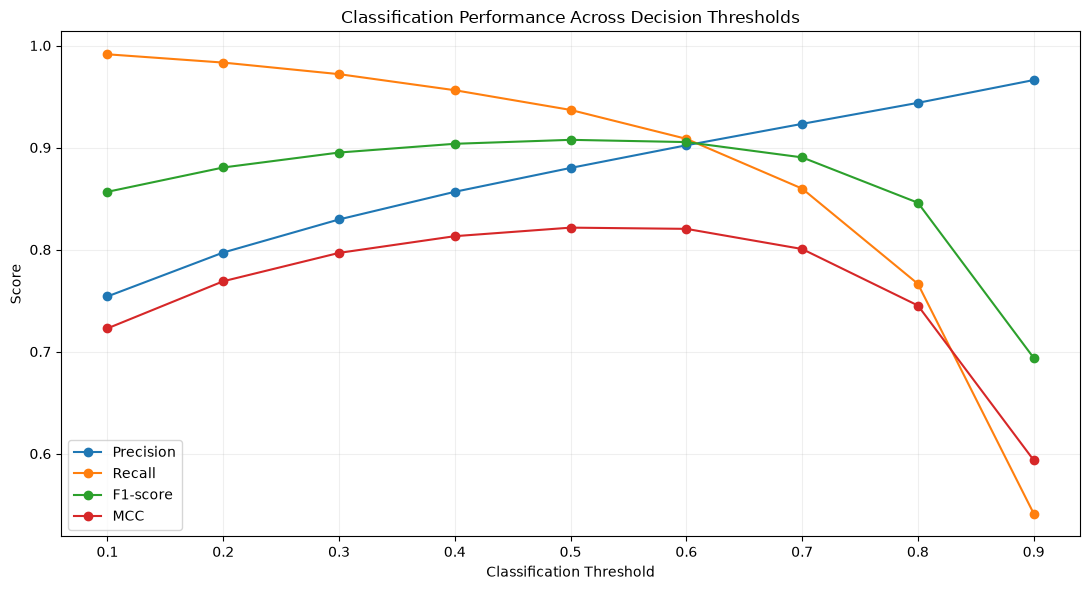

In [243]:
plt.figure(figsize=(11, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1"],
    marker="o",
    label="F1-score"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["MCC"],
    marker="o",
    label="MCC"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Classification Performance Across Decision Thresholds"
)

plt.xticks(thresholds)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### False Positive–False Negative Trade-off

The decision threshold directly controls the balance between the two major classification error types.

At lower thresholds, more observations are classified as Dock. This typically reduces False Negatives but increases False Positives.

At higher thresholds, Dock predictions become more conservative. This typically reduces False Positives but increases False Negatives.

The following plots examine this trade-off using both absolute error counts and normalized error rates.

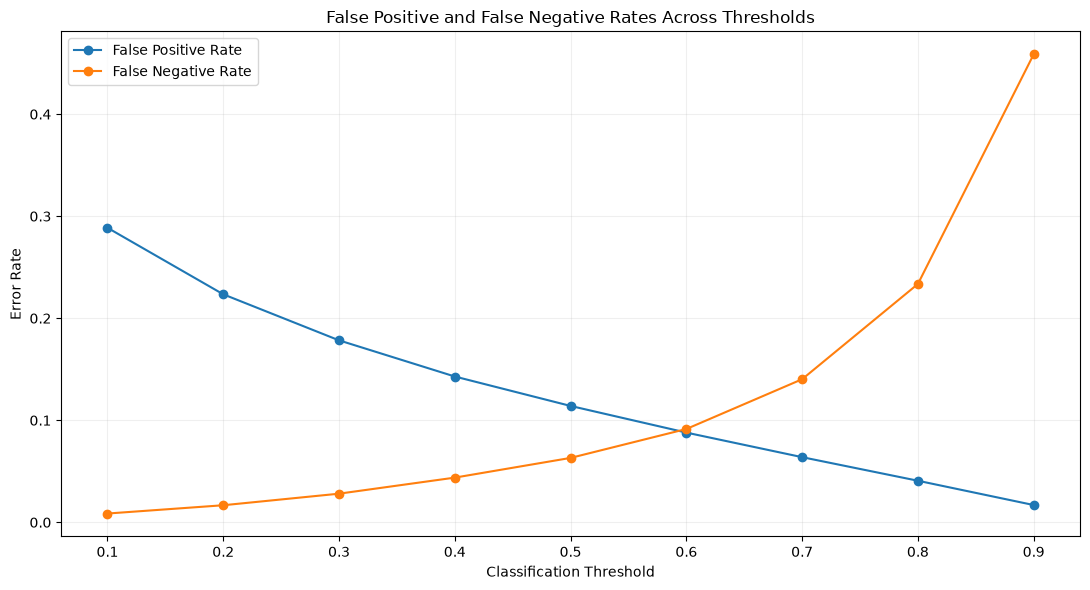

In [244]:
plt.figure(figsize=(11, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df[
        "False Positive Rate"
    ],
    marker="o",
    label="False Positive Rate"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df[
        "False Negative Rate"
    ],
    marker="o",
    label="False Negative Rate"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Error Rate")

plt.title(
    "False Positive and False Negative Rates Across Thresholds"
)

plt.xticks(thresholds)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df[
        "False Positive Rate"
    ],
    marker="o",
    label="False Positive Rate"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df[
        "False Negative Rate"
    ],
    marker="o",
    label="False Negative Rate"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Error Rate")

plt.title(
    "False Positive and False Negative Rates Across Thresholds"
)

plt.xticks(thresholds)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [245]:
best_f1_row = (
    threshold_results_df.loc[
        threshold_results_df[
            "F1"
        ].idxmax()
    ]
)

best_mcc_row = (
    threshold_results_df.loc[
        threshold_results_df[
            "MCC"
        ].idxmax()
    ]
)

print(
    "Threshold with highest F1:",
    f"{best_f1_row['Threshold']:.1f}"
)

print(
    "Best F1:",
    f"{best_f1_row['F1']:.4f}"
)

print()

print(
    "Threshold with highest MCC:",
    f"{best_mcc_row['Threshold']:.1f}"
)

print(
    "Best MCC:",
    f"{best_mcc_row['MCC']:.4f}"
)

Threshold with highest F1: 0.5
Best F1: 0.9076

Threshold with highest MCC: 0.5
Best MCC: 0.8215


#### Fβ-Score as a Function of β

The Fβ-score generalizes the F1-score by changing the relative importance of Precision and Recall.

- `β < 1` gives more importance to **Precision**.
- `β = 1` gives equal importance to Precision and Recall.
- `β > 1` gives more importance to **Recall**.

Because the preferred balance between Precision and Recall depends on the application, Fβ is evaluated across a range of β values for all tested decision thresholds.

This allows the operating threshold to be examined under different error-cost preferences.

In [246]:
beta_values = np.linspace(
    0.25,
    4.0,
    40
)

fbeta_results = []

for threshold in thresholds:

    predictions = (
        y_probability >= threshold
    ).astype(int)

    for beta in beta_values:

        score = fbeta_score(
            y_true_threshold,
            predictions,
            beta=beta,
            zero_division=0
        )

        fbeta_results.append({
            "Threshold": threshold,
            "Beta": beta,
            "F_beta": score
        })

fbeta_results_df = pd.DataFrame(
    fbeta_results
)

fbeta_results_df.head()

,Threshold,Beta,F_beta
0,0.1,0.250000,0.764881
1,0.1,0.346154,0.773932
2,0.1,0.442308,0.784848
3,0.1,0.538462,0.796987
4,0.1,0.634615,0.809755


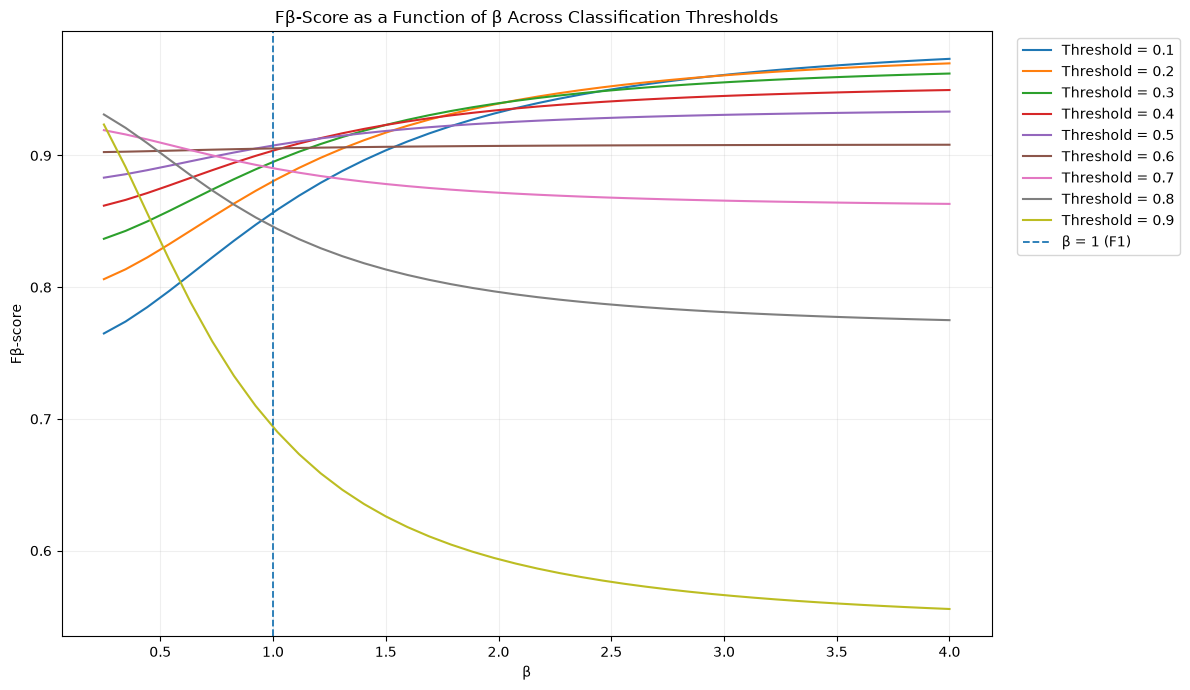

In [247]:
plt.figure(figsize=(12, 7))

for threshold in thresholds:

    threshold_beta_data = (
        fbeta_results_df[
            np.isclose(
                fbeta_results_df["Threshold"],
                threshold
            )
        ]
    )

    plt.plot(
        threshold_beta_data["Beta"],
        threshold_beta_data["F_beta"],
        label=f"Threshold = {threshold:.1f}"
    )

plt.axvline(
    x=1,
    linestyle="--",
    linewidth=1.3,
    label="β = 1 (F1)"
)

plt.xlabel("β")
plt.ylabel("Fβ-score")

plt.title(
    "Fβ-Score as a Function of β Across Classification Thresholds"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [248]:
selected_betas = [
    0.5,
    1.0,
    2.0
]

fbeta_summary = []

for threshold in thresholds:

    predictions = (
        y_probability >= threshold
    ).astype(int)

    row = {
        "Threshold": threshold
    }

    for beta in selected_betas:

        row[
            f"F{beta:g}"
        ] = fbeta_score(
            y_true_threshold,
            predictions,
            beta=beta,
            zero_division=0
        )

    fbeta_summary.append(row)

fbeta_summary_df = pd.DataFrame(
    fbeta_summary
)

fbeta_summary_df.round(4)

,Threshold,F0.5,F1,F2
0,0.1,0.7920,0.8566,0.9327
1,0.2,0.8285,0.8805,0.9394
2,0.3,0.8546,0.8951,0.9397
3,0.4,0.8749,0.9037,0.9345
4,0.5,0.8908,0.9076,0.9249
5,0.6,0.9035,0.9054,0.9073
6,0.7,0.9098,0.8904,0.8717
7,0.8,0.9021,0.8459,0.7963
8,0.9,0.8351,0.6939,0.5935


#### ROC Curve and AUC–ROC

Unlike Precision, Recall, F1, and MCC at a specific threshold, the ROC curve evaluates classifier discrimination across all possible decision thresholds.

The ROC curve plots:

- **False Positive Rate (FPR)** on the x-axis;
- **True Positive Rate (Recall)** on the y-axis.

The **Area Under the ROC Curve (AUC–ROC)** summarizes the model's ability to rank positive observations above negative observations.

An AUC close to 1 indicates strong discrimination, while an AUC near 0.5 indicates performance similar to random ranking.

Because AUC–ROC is calculated directly from predicted probabilities, it does not depend on choosing one fixed classification threshold.

In [249]:
fpr_roc, tpr_roc, roc_thresholds = (
    roc_curve(
        y_true_threshold,
        y_probability
    )
)

auc_roc = roc_auc_score(
    y_true_threshold,
    y_probability
)

print(
    "AUC–ROC:",
    f"{auc_roc:.4f}"
)

AUC–ROC: 0.9666


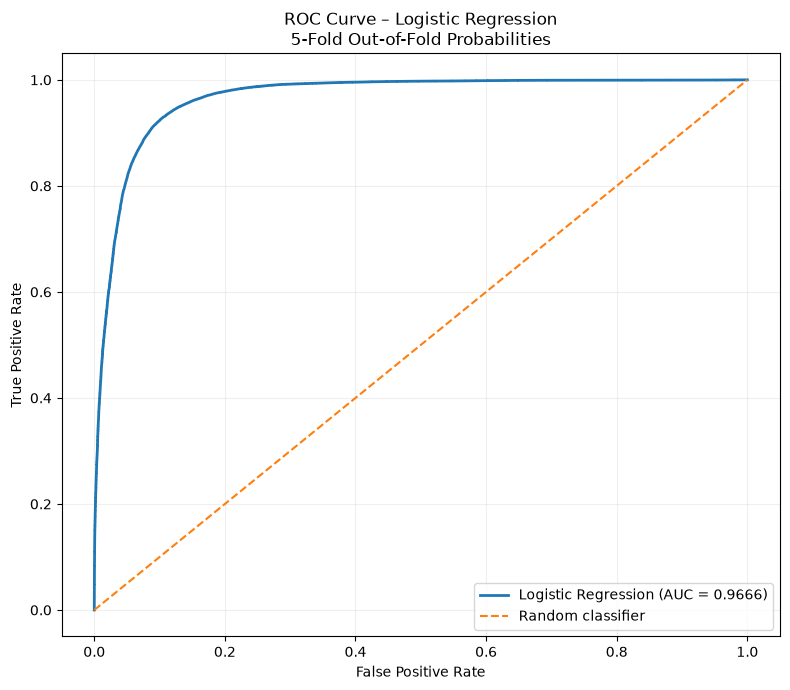

In [250]:
plt.figure(figsize=(8, 7))

plt.plot(
    fpr_roc,
    tpr_roc,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_roc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve – Logistic Regression\n"
    "5-Fold Out-of-Fold Probabilities"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### Stable and Unstable Operating Regions

An operating region is considered relatively **stable** when a small change in threshold produces only small changes in classification performance.

An **unstable** region is one in which a small threshold change causes comparatively large changes in Precision, Recall, F1, or MCC.

To quantify this effect, the absolute changes in these four metrics between every pair of adjacent thresholds are calculated.

A lower combined change indicates greater threshold stability, while a higher combined change indicates greater sensitivity to the operating threshold.

In [251]:
threshold_sensitivity = []

for i in range(
    1,
    len(threshold_results_df)
):

    previous_row = (
        threshold_results_df.iloc[
            i - 1
        ]
    )

    current_row = (
        threshold_results_df.iloc[
            i
        ]
    )

    precision_change = abs(
        current_row["Precision"]
        - previous_row["Precision"]
    )

    recall_change = abs(
        current_row["Recall"]
        - previous_row["Recall"]
    )

    f1_change = abs(
        current_row["F1"]
        - previous_row["F1"]
    )

    mcc_change = abs(
        current_row["MCC"]
        - previous_row["MCC"]
    )

    combined_change = (
        precision_change
        + recall_change
        + f1_change
        + mcc_change
    )

    threshold_sensitivity.append({
        "Threshold Interval":
            f"{previous_row['Threshold']:.1f}"
            f"–{current_row['Threshold']:.1f}",

        "Precision Change":
            precision_change,

        "Recall Change":
            recall_change,

        "F1 Change":
            f1_change,

        "MCC Change":
            mcc_change,

        "Combined Sensitivity":
            combined_change
    })

threshold_sensitivity_df = pd.DataFrame(
    threshold_sensitivity
)

threshold_sensitivity_df.round(4)

,Threshold Interval,Precision Change,Recall Change,F1 Change,MCC Change,Combined Sensitivity
0,0.1–0.2,0.0430,0.0081,0.0238,0.0462,0.1211
1,0.2–0.3,0.0324,0.0113,0.0146,0.0278,0.0862
2,0.3–0.4,0.0271,0.0157,0.0086,0.0164,0.0678
3,0.4–0.5,0.0234,0.0193,0.0039,0.0084,0.0549
4,0.5–0.6,0.0222,0.0283,0.0022,0.0012,0.0539
5,0.6–0.7,0.0210,0.0488,0.0150,0.0198,0.1045
6,0.7–0.8,0.0206,0.0933,0.0444,0.0554,0.2138
7,0.8–0.9,0.0223,0.2251,0.1520,0.1515,0.5510


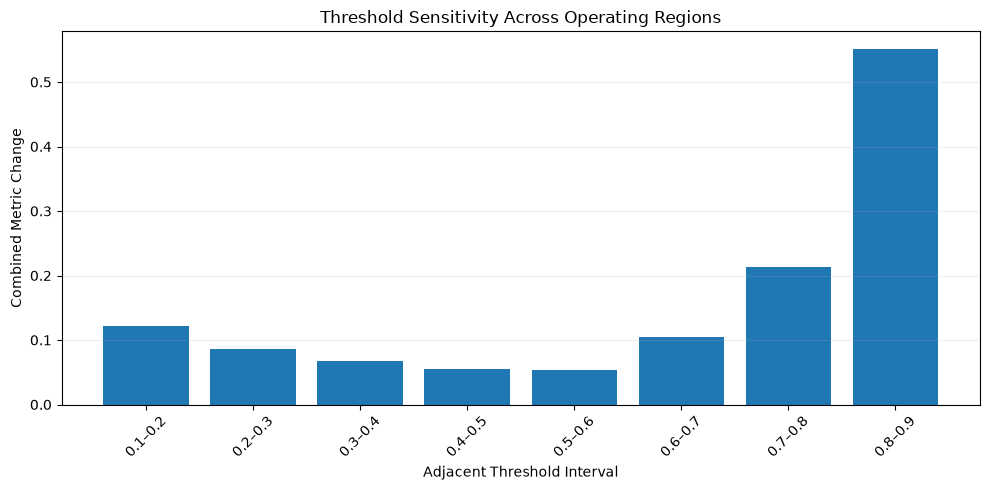

In [252]:
plt.figure(figsize=(10, 5))

plt.bar(
    threshold_sensitivity_df[
        "Threshold Interval"
    ],
    threshold_sensitivity_df[
        "Combined Sensitivity"
    ]
)

plt.xlabel(
    "Adjacent Threshold Interval"
)

plt.ylabel(
    "Combined Metric Change"
)

plt.title(
    "Threshold Sensitivity Across Operating Regions"
)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [253]:
most_stable_row = (
    threshold_sensitivity_df.loc[
        threshold_sensitivity_df[
            "Combined Sensitivity"
        ].idxmin()
    ]
)

most_unstable_row = (
    threshold_sensitivity_df.loc[
        threshold_sensitivity_df[
            "Combined Sensitivity"
        ].idxmax()
    ]
)

print(
    "Most stable adjacent threshold region:",
    most_stable_row[
        "Threshold Interval"
    ]
)

print(
    "Combined sensitivity:",
    f"{most_stable_row['Combined Sensitivity']:.4f}"
)

print()

print(
    "Most unstable adjacent threshold region:",
    most_unstable_row[
        "Threshold Interval"
    ]
)

print(
    "Combined sensitivity:",
    f"{most_unstable_row['Combined Sensitivity']:.4f}"
)

Most stable adjacent threshold region: 0.5–0.6
Combined sensitivity: 0.0539

Most unstable adjacent threshold region: 0.8–0.9
Combined sensitivity: 0.5510


In [254]:
threshold_results_df[
    "FP_FN_rate_gap"
] = np.abs(
    threshold_results_df[
        "False Positive Rate"
    ]
    -
    threshold_results_df[
        "False Negative Rate"
    ]
)

most_balanced_error_row = (
    threshold_results_df.loc[
        threshold_results_df[
            "FP_FN_rate_gap"
        ].idxmin()
    ]
)

print(
    "Threshold with most balanced FP/FN rates:",
    f"{most_balanced_error_row['Threshold']:.1f}"
)

print(
    "False Positive Rate:",
    f"{most_balanced_error_row['False Positive Rate']:.4f}"
)

print(
    "False Negative Rate:",
    f"{most_balanced_error_row['False Negative Rate']:.4f}"
)

Threshold with most balanced FP/FN rates: 0.6
False Positive Rate: 0.0879
False Negative Rate: 0.0915


In [255]:
threshold_summary_table = (
    threshold_results_df[
        [
            "Threshold",
            "Precision",
            "Recall",
            "F1",
            "MCC",
            "False Positive Rate",
            "False Negative Rate"
        ]
    ]
    .copy()
)

threshold_summary_table.round(4)

,Threshold,Precision,Recall,F1,MCC,False Positive Rate,False Negative Rate
0,0.1,0.7541,0.9914,0.8566,0.7228,0.2886,0.0086
1,0.2,0.7971,0.9833,0.8805,0.7690,0.2235,0.0167
2,0.3,0.8295,0.9719,0.8951,0.7968,0.1783,0.0281
3,0.4,0.8566,0.9562,0.9037,0.8131,0.1429,0.0438
4,0.5,0.8800,0.9369,0.9076,0.8215,0.1141,0.0631
5,0.6,0.9022,0.9085,0.9054,0.8203,0.0879,0.0915
6,0.7,0.9232,0.8598,0.8904,0.8006,0.0639,0.1402
7,0.8,0.9438,0.7664,0.8459,0.7452,0.0407,0.2336
8,0.9,0.9662,0.5413,0.6939,0.5936,0.0169,0.4587


In [256]:
from IPython.display import Markdown, display as ipy_display

best_f1_threshold = (
    best_f1_row["Threshold"]
)

best_f1_value = (
    best_f1_row["F1"]
)

best_mcc_threshold = (
    best_mcc_row["Threshold"]
)

best_mcc_value = (
    best_mcc_row["MCC"]
)

stable_interval = (
    most_stable_row[
        "Threshold Interval"
    ]
)

unstable_interval = (
    most_unstable_row[
        "Threshold Interval"
    ]
)

balanced_threshold = (
    most_balanced_error_row[
        "Threshold"
    ]
)

threshold_interpretation = f"""
#### Interpretation

The threshold-sensitivity analysis demonstrates a clear trade-off between False Positives and False Negatives.

At lower decision thresholds, the classifier predicts Dock more readily. This increases Recall because fewer true docks are missed, but it also produces more False Positives and therefore lowers Precision.

As the threshold increases, Dock predictions become more conservative. Precision generally improves because fewer non-dock observations are incorrectly labeled as docks, while Recall decreases because more true docks are rejected.

This confirms that the classification threshold controls the operating behavior of the model rather than merely changing a technical parameter.


##### F1 and MCC

Among the evaluated thresholds from 0.1 to 0.9, the highest F1-score is obtained at a threshold of approximately **{best_f1_threshold:.1f}**, where F1 is approximately **{best_f1_value:.4f}**.

The highest MCC is obtained at a threshold of approximately **{best_mcc_threshold:.1f}**, where MCC is approximately **{best_mcc_value:.4f}**.

If these thresholds differ, the result illustrates that the definition of an "optimal" threshold depends on the evaluation criterion.

MCC is particularly useful because it incorporates all four confusion-matrix outcomes rather than considering only the positive-class Precision and Recall.


##### Fβ behavior

The Fβ analysis shows that the preferred operating threshold changes as the importance assigned to Recall versus Precision changes.

For **β < 1**, Precision receives greater weight. Therefore, more conservative thresholds may become preferable.

For **β > 1**, Recall receives greater weight. Therefore, lower thresholds that reduce False Negatives may become preferable.

This demonstrates that threshold selection should depend on the practical cost of the two classification error types.


##### ROC and AUC

The model achieves an AUC–ROC of approximately **{auc_roc:.4f}**.

The ROC curve summarizes discrimination across all possible classification thresholds and therefore provides a threshold-independent view of classifier quality.

The AUC result should be interpreted together with the threshold-specific metrics: good ranking ability does not automatically determine which operating threshold is appropriate for a particular application.


##### Stable and unstable operating regions

The smallest combined change in Precision, Recall, F1, and MCC occurs between thresholds **{stable_interval}**.

This interval is therefore the most stable among the tested operating regions: a small change in threshold produces relatively limited changes in overall classification behavior.

The largest combined change occurs between thresholds **{unstable_interval}**.

This region is comparatively unstable because a small threshold adjustment produces a larger change in model behavior.

Such unstable regions are less desirable when consistent operating performance is important.


##### False Positive versus False Negative balance

The threshold at which the False Positive Rate and False Negative Rate are most similar is approximately **{balanced_threshold:.1f}**.

However, equal error rates do not necessarily imply that this is the best practical threshold.

If False Positives are considered more costly, a higher threshold may be preferred. If False Negatives are considered more costly, a lower threshold may be preferred.

Therefore, the final operating threshold should be selected according to both statistical performance and the real-world cost of each error type.
"""

ipy_display(
    Markdown(
        threshold_interpretation
    )
)


#### Interpretation

The threshold-sensitivity analysis demonstrates a clear trade-off between False Positives and False Negatives.

At lower decision thresholds, the classifier predicts Dock more readily. This increases Recall because fewer true docks are missed, but it also produces more False Positives and therefore lowers Precision.

As the threshold increases, Dock predictions become more conservative. Precision generally improves because fewer non-dock observations are incorrectly labeled as docks, while Recall decreases because more true docks are rejected.

This confirms that the classification threshold controls the operating behavior of the model rather than merely changing a technical parameter.


##### F1 and MCC

Among the evaluated thresholds from 0.1 to 0.9, the highest F1-score is obtained at a threshold of approximately **0.5**, where F1 is approximately **0.9076**.

The highest MCC is obtained at a threshold of approximately **0.5**, where MCC is approximately **0.8215**.

If these thresholds differ, the result illustrates that the definition of an "optimal" threshold depends on the evaluation criterion.

MCC is particularly useful because it incorporates all four confusion-matrix outcomes rather than considering only the positive-class Precision and Recall.


##### Fβ behavior

The Fβ analysis shows that the preferred operating threshold changes as the importance assigned to Recall versus Precision changes.

For **β < 1**, Precision receives greater weight. Therefore, more conservative thresholds may become preferable.

For **β > 1**, Recall receives greater weight. Therefore, lower thresholds that reduce False Negatives may become preferable.

This demonstrates that threshold selection should depend on the practical cost of the two classification error types.


##### ROC and AUC

The model achieves an AUC–ROC of approximately **0.9666**.

The ROC curve summarizes discrimination across all possible classification thresholds and therefore provides a threshold-independent view of classifier quality.

The AUC result should be interpreted together with the threshold-specific metrics: good ranking ability does not automatically determine which operating threshold is appropriate for a particular application.


##### Stable and unstable operating regions

The smallest combined change in Precision, Recall, F1, and MCC occurs between thresholds **0.5–0.6**.

This interval is therefore the most stable among the tested operating regions: a small change in threshold produces relatively limited changes in overall classification behavior.

The largest combined change occurs between thresholds **0.8–0.9**.

This region is comparatively unstable because a small threshold adjustment produces a larger change in model behavior.

Such unstable regions are less desirable when consistent operating performance is important.


##### False Positive versus False Negative balance

The threshold at which the False Positive Rate and False Negative Rate are most similar is approximately **0.6**.

However, equal error rates do not necessarily imply that this is the best practical threshold.

If False Positives are considered more costly, a higher threshold may be preferred. If False Negatives are considered more costly, a lower threshold may be preferred.

Therefore, the final operating threshold should be selected according to both statistical performance and the real-world cost of each error type.


#### Section 3.4 Conclusion

The classification threshold has a substantial effect on model behavior.

The analysis shows that:

1. **Precision and Recall trade off against each other as the threshold changes.**
2. **False Positives dominate more strongly at lower thresholds, while False Negatives increase at higher thresholds.**
3. **F1 and MCC provide balanced criteria for selecting an operating threshold, but they do not necessarily select the same threshold.**
4. **The Fβ analysis shows that the preferred threshold depends on whether Precision or Recall is considered more important.**
5. **AUC–ROC measures overall discrimination independently of one particular threshold.**
6. **Some threshold regions are more stable than others, meaning that small threshold changes have less effect on classification performance.**

Therefore, the default threshold of 0.5 should not automatically be assumed to be optimal.

Threshold selection should be based on the desired balance between False Positives and False Negatives, overall predictive performance, and the practical consequences of classification errors.

### 3.5 Critical Discussion and Overall Reflection

This section integrates the main findings from both the modeling and error-analysis stages.

The regression stage compared several modeling approaches with different assumptions, including Linear Regression, Decision Tree, Random Forest, and, when included, KNN as an optional model.

The classification stage used Logistic Regression as an interpretable baseline classifier and examined its errors in detail through confusion-matrix analysis, predicted probabilities, feature-dependent error analysis, and threshold sensitivity.

The discussion focuses on:

- strengths and limitations of the evaluated models,
- key failure modes,
- the relationship between model assumptions and observed performance,
- the most important insights obtained from the analysis,
- and concrete recommendations for improving future predictive performance and robustness.

In [257]:
# --------------------------------------------------
# Collect the main results from previous sections
# --------------------------------------------------

# Regression summary
if "extended_validation_summary" in globals():
    final_regression_summary = (
        extended_validation_summary.copy()
    )
elif "validation_summary" in globals():
    final_regression_summary = (
        validation_summary.copy()
    )
else:
    raise ValueError(
        "Regression comparison results were not found. "
        "Run the Section 2 model-comparison blocks first."
    )

preferred_regression_model = (
    final_regression_summary[
        "RMSE_mean"
    ].idxmin()
)

preferred_regression_results = (
    final_regression_summary.loc[
        preferred_regression_model
    ]
)

# Classification results
required_classification_variables = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc_roc",
    "best_f1_row",
    "best_mcc_row"
]

missing_variables = [
    variable
    for variable in required_classification_variables
    if variable not in globals()
]

if missing_variables:
    raise ValueError(
        "Missing classification results: "
        + ", ".join(missing_variables)
        + ". Run Sections 3.1–3.4 first."
    )

overall_summary = pd.DataFrame({
    "Result": [
        "Preferred regression model",
        "Preferred regression MAE",
        "Preferred regression RMSE",
        "Preferred regression R²",
        "Classification Accuracy",
        "Classification Precision",
        "Classification Recall",
        "Classification F1",
        "Classification AUC–ROC",
        "Best threshold by F1",
        "Best threshold by MCC"
    ],

    "Value": [
        preferred_regression_model,
        preferred_regression_results["MAE_mean"],
        preferred_regression_results["RMSE_mean"],
        preferred_regression_results["R2_mean"],
        accuracy,
        precision,
        recall,
        f1,
        auc_roc,
        best_f1_row["Threshold"],
        best_mcc_row["Threshold"]
    ]
})

overall_summary

,Result,Value
0,Preferred regression model,Random Forest
1,Preferred regression MAE,0.017329
2,Preferred regression RMSE,0.024218
3,Preferred regression R²,0.686969
4,Classification Accuracy,0.909967
5,Classification Precision,0.880018
6,Classification Recall,0.936872
7,Classification F1,0.907556
8,Classification AUC–ROC,0.966579
9,Best threshold by F1,0.5


#### Strengths and Limitations of the Evaluated Models

**Linear Regression**

Linear Regression provides a useful baseline because it is computationally efficient and highly interpretable.

Its main limitation is its assumption that the expected target can be represented through a global linear relationship between the predictors and the target.

The residual analyses demonstrated that this assumption is too restrictive for important parts of the anchorage dataset. Residual behavior changed across feature regions, geographic subpopulations, and extreme target values.

Therefore, the main strength of Linear Regression is interpretability, while its main limitation is insufficient flexibility.


**Decision Tree Regressor**

The Decision Tree is more flexible because it can learn nonlinear thresholds and interactions between variables without requiring them to be specified manually.

This is particularly useful for geographic data, where the effect of one variable may depend on another variable or on the geographic region.

However, an individual Decision Tree can have high variance. It may fit detailed structures in the training data that do not generalize equally well to unseen observations.

Therefore, the Decision Tree provides greater flexibility than Linear Regression but introduces a stronger risk of overfitting.


**Random Forest Regressor**

Random Forest retains the nonlinear modeling ability of decision trees while reducing the instability of a single tree by averaging predictions across multiple trees.

This makes it well suited to datasets containing nonlinear relationships, interactions, and heterogeneous subpopulations.

Its main disadvantages are increased computational cost and reduced direct interpretability.

Unlike a single regression equation or a single tree, the final prediction is generated by an ensemble of many trees and is therefore more difficult to explain directly.


**Logistic Regression Classifier**

Logistic Regression provides an interpretable probabilistic baseline for the classification task.

A major advantage is that it produces predicted probabilities, which made it possible to perform confidence analysis, threshold sensitivity analysis, ROC analysis, and application-dependent operating-point selection.

However, Logistic Regression assumes that the log-odds of the positive class can be represented through a linear combination of the transformed input features.

The systematic feature-dependent and geographic classification failures indicate that this assumption does not fully capture all structures in the dataset.

The presence of high-confidence errors also demonstrates that a confident probability should not automatically be interpreted as a reliable prediction.

#### Key Failure Modes Identified During the Analysis

Several important failure modes were identified.

**1. Extreme target values**

The regression analysis showed that observations with unusually large `drift_radius` values were strongly overrepresented among the largest absolute prediction errors.

The Linear Regression model frequently underestimated these cases.


**2. Extreme geographic conditions**

Observations located in unusual geographic regions or at extreme distances from shore showed substantially larger regression errors in several cases.

This indicates that relationships learned from typical observations do not necessarily generalize to extreme conditions.


**3. Geographic subpopulation effects**

Both regression and classification errors varied substantially across countries and geographic regions.

This demonstrates that overall model performance can hide poor performance in specific subpopulations.


**4. Feature-dependent model failures**

Regression residuals and classification error rates changed across ranges of latitude, longitude, distance from shore, and drift radius.

The errors are therefore not purely random but are systematically related to the feature space.


**5. False Positives and False Negatives**

The classification analysis showed that False Positives and False Negatives represent distinct failure modes.

Their practical importance depends on the intended use of the classifier.

If falsely identifying a non-dock location as a dock could lead to unsafe operational decisions, False Positives are particularly important.

If complete dock detection is more important, False Negatives become more costly.


**6. High-confidence classification errors**

Some incorrect predictions received very high predicted confidence.

These failures are particularly important because they cannot easily be identified simply by rejecting uncertain predictions.


**7. Threshold sensitivity**

Classification behavior changed substantially when the decision threshold was varied.

This confirms that the default threshold of 0.5 should not automatically be assumed to be the most appropriate operating point.

#### Relationship Between Model Assumptions and Observed Performance

The observed model performance is closely related to the assumptions made by each modeling approach.

The relatively weak performance of Linear Regression is consistent with the violations observed during residual analysis.

The residuals showed:

- systematic patterns,
- feature-dependent behavior,
- non-constant variance,
- moderate asymmetry,
- and subgroup-specific errors.

These findings indicate that strict linearity and homoskedasticity are not fully satisfied.

The improvement obtained by tree-based regression models demonstrates that nonlinear relationships and interactions are important in this dataset.

Tree-based models do not require one global linear relationship and can therefore adapt to different regions of the feature space.

The classification results reveal a similar issue.

Logistic Regression provides a useful linear probabilistic baseline, but the feature and geographic error analyses show that classification difficulty changes across subpopulations.

This suggests that nonlinear classification boundaries or feature interactions may provide additional predictive information.

The independence assumption cannot be confirmed from the current analysis.

Because the observations are geographic, nearby or regionally related observations may potentially be dependent. A dedicated spatial-dependence analysis would be required before claiming that the independence assumption is satisfied.

#### Most Significant Insights

Several major insights emerge from the complete study.

**First, average model performance is not sufficient.**

Two models may have similar overall metrics while behaving very differently for particular regions, rare observations, or error types.

Residual analysis and subgroup analysis therefore provide information that cannot be obtained from MAE, RMSE, R², or classification accuracy alone.


**Second, model assumptions matter strongly.**

The clear improvement of nonlinear regression models over the linear baseline demonstrates that the structure of the data is more complex than one global linear relationship.


**Third, rare observations are disproportionately difficult.**

Extreme regression errors were strongly associated with unusual target values and unusual feature-space regions.

This means that strong average performance does not guarantee robustness for exceptional cases.


**Fourth, geographic heterogeneity is important.**

Both regression and classification analyses identified geographic subpopulations with substantially degraded performance.

This suggests that geographic location is not merely another input variable but may represent different underlying data-generating conditions.


**Fifth, predicted probability is not equivalent to reliability.**

The classification analysis identified high-confidence errors, showing that the Logistic Regression model can occasionally be strongly confident while still being incorrect.


**Sixth, classification thresholds represent operational choices.**

Changing the decision threshold changes the balance between False Positives and False Negatives.

Therefore, threshold selection should depend on the practical objective and cost of each error type rather than automatically using 0.5.


**Finally, error analysis changes the interpretation of model quality.**

A model should not be considered strong only because it performs well on average.

A robust model should also maintain acceptable performance across difficult regions, rare cases, and important subpopulations.

#### Recommendations for Future Improvement

Based on the observed failure patterns, several concrete improvements are recommended.


**1. Evaluate more flexible classification models**

Tree-based classifiers such as Random Forest, Gradient Boosting, or similar nonlinear models should be evaluated against the Logistic Regression baseline.

The current feature-dependent and geographic failure patterns suggest that nonlinear decision boundaries may improve classification performance.


**2. Perform systematic hyperparameter tuning**

The current study used explicitly specified model configurations.

Future work could use nested cross-validation or another properly separated tuning procedure to optimize hyperparameters without introducing optimistic evaluation bias.


**3. Improve geographic feature engineering**

Latitude and longitude alone may not adequately represent geographic structure.

Additional features could include regional grouping, distance to ports or coastlines, geographic clusters, or interaction terms between location and anchorage characteristics.


**4. Investigate geographic validation strategies**

Random k-fold cross-validation evaluates generalization to unseen observations drawn from similar data.

However, geographic observations may be spatially related.

A future study could compare standard k-fold validation with group-based or spatial cross-validation to test whether models can generalize to entirely unseen geographic regions.


**5. Improve performance on rare and extreme observations**

Rare target values and unusual geographic conditions should receive dedicated analysis.

Possible approaches include collecting more observations from underrepresented regions, designing features that describe exceptional anchorage conditions, or using models that better capture nonlinear tails.


**6. Perform probability calibration analysis**

Because high-confidence classification errors were identified, future work should evaluate probability calibration using methods such as reliability diagrams or calibration metrics.

This would determine whether reported probabilities correspond accurately to observed event frequencies.


**7. Select the classification threshold according to application cost**

The threshold should not be selected using F1 alone when False Positives and False Negatives have different real-world costs.

A future operational system should define an explicit error-cost function and select the threshold accordingly.


**8. Monitor subgroup performance**

Model evaluation should report performance not only globally but also across important countries, geographic regions, dock categories, and other meaningful subpopulations.

This can prevent strong overall metrics from hiding systematic local failures.


**9. Investigate data quality in high-error regions**

Although the basic data-quality analysis did not reveal obvious corruption as the dominant source of extreme errors, high-error geographic regions should be inspected more deeply for measurement differences, inconsistent labeling, or missing explanatory variables.

In [258]:
from IPython.display import Markdown, display as ipy_display

best_reg_name = preferred_regression_model

best_reg_mae = (
    preferred_regression_results[
        "MAE_mean"
    ]
)

best_reg_rmse = (
    preferred_regression_results[
        "RMSE_mean"
    ]
)

best_reg_r2 = (
    preferred_regression_results[
        "R2_mean"
    ]
)

best_f1_threshold = (
    best_f1_row["Threshold"]
)

best_f1_value = (
    best_f1_row["F1"]
)

best_mcc_threshold = (
    best_mcc_row["Threshold"]
)

best_mcc_value = (
    best_mcc_row["MCC"]
)

if "high_confidence_errors" in globals():

    high_conf_count = (
        len(high_confidence_errors)
    )

else:
    high_conf_count = None


final_reflection = f"""
#### Integrated Final Reflection

The complete analysis demonstrates that model performance depends strongly on both the modeling assumptions and the region of the data being evaluated.

For the regression task, the strongest cross-validated model is **{best_reg_name}**, with approximately:

- **MAE = {best_reg_mae:.4f}**
- **RMSE = {best_reg_rmse:.4f}**
- **R² = {best_reg_r2:.4f}**

The improvement over the Linear Regression baseline supports the conclusion that nonlinear relationships and feature interactions are important in the anchorage dataset.

For the classification task, Logistic Regression achieves:

- **Accuracy = {accuracy:.4f}**
- **Precision = {precision:.4f}**
- **Recall = {recall:.4f}**
- **F1 = {f1:.4f}**
- **AUC–ROC = {auc_roc:.4f}**

The threshold analysis shows that the highest evaluated F1-score occurs at a threshold of approximately **{best_f1_threshold:.1f}**, with F1 approximately **{best_f1_value:.4f}**.

The highest MCC occurs at approximately **{best_mcc_threshold:.1f}**, with MCC approximately **{best_mcc_value:.4f}**.

These results demonstrate that no single metric or operating threshold provides a complete description of model quality.

The most important overall conclusion is that prediction failures are structured rather than purely random.

Errors were associated with:

- unusual target values,
- specific feature ranges,
- extreme geographic conditions,
- geographic subpopulations,
- and classification operating thresholds.

Therefore, future improvement should focus not only on increasing average predictive performance but also on improving robustness across difficult and underrepresented regions of the data.
"""

ipy_display(
    Markdown(
        final_reflection
    )
)


#### Integrated Final Reflection

The complete analysis demonstrates that model performance depends strongly on both the modeling assumptions and the region of the data being evaluated.

For the regression task, the strongest cross-validated model is **Random Forest**, with approximately:

- **MAE = 0.0173**
- **RMSE = 0.0242**
- **R² = 0.6870**

The improvement over the Linear Regression baseline supports the conclusion that nonlinear relationships and feature interactions are important in the anchorage dataset.

For the classification task, Logistic Regression achieves:

- **Accuracy = 0.9100**
- **Precision = 0.8800**
- **Recall = 0.9369**
- **F1 = 0.9076**
- **AUC–ROC = 0.9666**

The threshold analysis shows that the highest evaluated F1-score occurs at a threshold of approximately **0.5**, with F1 approximately **0.9076**.

The highest MCC occurs at approximately **0.5**, with MCC approximately **0.8215**.

These results demonstrate that no single metric or operating threshold provides a complete description of model quality.

The most important overall conclusion is that prediction failures are structured rather than purely random.

Errors were associated with:

- unusual target values,
- specific feature ranges,
- extreme geographic conditions,
- geographic subpopulations,
- and classification operating thresholds.

Therefore, future improvement should focus not only on increasing average predictive performance but also on improving robustness across difficult and underrepresented regions of the data.


#### Section 3.5 Conclusion

The combined modeling and error analyses show that predictive performance should be evaluated from several complementary perspectives.

Cross-validation provides an estimate of generalization performance, while residual analysis, confusion-matrix analysis, probability analysis, feature-dependent error analysis, and threshold sensitivity reveal where and how the models fail.

The study demonstrates that:

- nonlinear structure is important,
- rare observations create disproportionate prediction difficulty,
- geographic subpopulations require separate attention,
- probability confidence does not guarantee correctness,
- and classification thresholds should be selected according to the intended operating objective.

The most important lesson is that a reliable predictive system should not only achieve strong average metrics but should also behave consistently across important subpopulations and difficult regions of the data.

## 4. Final Reflection

This final reflection integrates the main conclusions obtained from the regression modeling, residual analysis, classification error analysis, probability analysis, feature-dependent error analysis, and threshold-sensitivity analysis.

The purpose is to identify where the predictive models fail most, determine the likely sources of these failures, propose concrete improvements, and summarize the main insights gained from the complete study.

In [259]:
# --------------------------------------------------
# Final reflection: collect results from earlier sections
# --------------------------------------------------

# Regression model comparison
if "extended_validation_summary" in globals():
    final_regression_summary = extended_validation_summary.copy()

elif "validation_summary" in globals():
    final_regression_summary = validation_summary.copy()

else:
    raise ValueError(
        "Regression model comparison results are missing. "
        "Run Section 2 first."
    )


preferred_regression_model = (
    final_regression_summary[
        "RMSE_mean"
    ].idxmin()
)

preferred_regression_results = (
    final_regression_summary.loc[
        preferred_regression_model
    ]
)


# Extreme regression errors
if "extreme_errors" in globals():

    extreme_underprediction_rate = (
        (
            extreme_errors["residual"] > 0
        ).mean() * 100
    )

else:
    extreme_underprediction_rate = np.nan


# Classification results
required_final_variables = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc_roc",
    "best_f1_row",
    "best_mcc_row"
]

missing_final_variables = [
    variable
    for variable in required_final_variables
    if variable not in globals()
]

if missing_final_variables:
    raise ValueError(
        "Missing classification results: "
        + ", ".join(missing_final_variables)
        + ". Run Sections 3.1–3.4 first."
    )


# High-confidence errors
if "high_confidence_errors" in globals():
    high_confidence_error_count = len(
        high_confidence_errors
    )
else:
    high_confidence_error_count = np.nan


# Highest-error classification country
if (
    "country_feature_summary" in globals()
    and len(country_feature_summary) > 0
):

    highest_error_country = (
        country_feature_summary.index[0]
    )

    highest_error_country_rate = (
        country_feature_summary.iloc[0][
            "error_rate_%"
        ]
    )

else:
    highest_error_country = "N/A"
    highest_error_country_rate = np.nan


print(
    "Preferred regression model:",
    preferred_regression_model
)

print(
    "Regression RMSE:",
    round(
        preferred_regression_results[
            "RMSE_mean"
        ],
        4
    )
)

print(
    "Regression R²:",
    round(
        preferred_regression_results[
            "R2_mean"
        ],
        4
    )
)

print(
    "Classification F1:",
    round(f1, 4)
)

print(
    "Classification AUC–ROC:",
    round(auc_roc, 4)
)

print(
    "Best F1 threshold:",
    round(
        best_f1_row[
            "Threshold"
        ],
        1
    )
)

Preferred regression model: Random Forest
Regression RMSE: 0.0242
Regression R²: 0.687
Classification F1: 0.9076
Classification AUC–ROC: 0.9666
Best F1 threshold: 0.5


In [260]:
from IPython.display import Markdown, display as ipy_display

best_reg_mae = (
    preferred_regression_results[
        "MAE_mean"
    ]
)

best_reg_rmse = (
    preferred_regression_results[
        "RMSE_mean"
    ]
)

best_reg_r2 = (
    preferred_regression_results[
        "R2_mean"
    ]
)

best_f1_threshold = (
    best_f1_row[
        "Threshold"
    ]
)

best_f1_value = (
    best_f1_row[
        "F1"
    ]
)

best_mcc_threshold = (
    best_mcc_row[
        "Threshold"
    ]
)

best_mcc_value = (
    best_mcc_row[
        "MCC"
    ]
)

if np.isclose(
    best_f1_threshold,
    0.5
):
    threshold_selection_text = (
        "The best F1 among the tested thresholds occurs at "
        f"approximately **{best_f1_threshold:.1f}**. "
        "In this dataset, this value happens to coincide with the "
        "default threshold of 0.5; importantly, it was identified "
        "empirically from the threshold analysis rather than assumed "
        "to be optimal in advance."
    )
else:
    threshold_selection_text = (
        "The best F1 among the tested thresholds occurs at "
        f"approximately **{best_f1_threshold:.1f}**, which differs "
        "from the default threshold of 0.5. This demonstrates why the "
        "operating threshold should be evaluated empirically rather "
        "than assumed in advance."
    )


final_reflection_text = f"""
### Final Reflection

#### 1. Where does the model fail most?

The analysis shows that model failures are concentrated in specific regions rather than being distributed uniformly across the dataset.

In the regression task, the largest errors occur especially for **rare or unusually large `drift_radius` values**, extreme geographic conditions, particular distance-from-shore ranges, and specific geographic subpopulations.

The earlier extreme-error analysis also showed that large underpredictions occur frequently among the most severe regression errors.

In the classification task, the model fails more frequently in particular feature ranges and geographic regions. Among sufficiently represented countries, **{highest_error_country}** shows one of the highest observed misclassification rates, approximately **{highest_error_country_rate:.2f}%**.

The classification analysis also identified False Positives, False Negatives, and high-confidence errors, demonstrating that some failures remain important even when the model appears confident.


#### 2. Are failures due to data, model, or formulation?

The evidence suggests that the failures arise from a **combination of factors**, but model limitations and problem formulation appear more important than obvious data-quality problems.

The basic data-quality analysis did not reveal widespread invalid coordinates, negative values, duplicated identifiers, or missing values sufficient to explain the observed error patterns.

In contrast, strong evidence of model limitations was observed.

Linear Regression assumes a global linear relationship, but the residual analysis revealed nonlinear feature-dependent patterns, heteroscedasticity, subgroup differences, and extreme-error behavior.

The stronger performance of **{preferred_regression_model}**, with approximately **MAE = {best_reg_mae:.4f}**, **RMSE = {best_reg_rmse:.4f}**, and **R² = {best_reg_r2:.4f}**, supports the conclusion that more flexible relationships are required.

{threshold_selection_text}

Therefore, the failures are best explained by a combination of model limitations, difficult or rare observations, missing explanatory information, and aspects of the problem formulation.


#### 3. What improvements would you propose?

Several improvements could increase predictive performance and robustness.

For regression, more flexible nonlinear and ensemble models should be preferred over a simple linear baseline when predictive accuracy is the primary objective.

For classification, nonlinear classifiers such as Random Forest or Gradient Boosting should be evaluated against the Logistic Regression baseline.

Geographic feature engineering could also be improved by introducing richer regional information, geographic clusters, interaction features, or additional variables describing anchorage conditions.

Future work should also consider spatial or group-based cross-validation because observations from similar geographic regions may not be fully independent.

High-error and underrepresented regions should receive dedicated analysis and, where possible, additional data.

Because high-confidence classification errors were observed, probability calibration should also be evaluated.

Finally, the classification threshold should be selected according to the real-world cost of False Positives and False Negatives rather than automatically using the default value of 0.5.


#### 4. What insights did you gain in your analysis?

The most important insight is that **overall performance metrics alone are not sufficient to evaluate a predictive model**.

Residual analysis showed where regression errors occur and revealed systematic patterns that were hidden by average metrics.

The comparison between regression models demonstrated that modeling assumptions strongly affect performance. The improvement obtained with nonlinear approaches showed that the dataset contains relationships and interactions that cannot be represented adequately by one global linear equation.

The classification analysis showed that accuracy alone also hides important information. False Positives and False Negatives represent different failure modes, predicted probability does not guarantee correctness, and model performance can differ substantially between geographic subpopulations.

The threshold analysis further demonstrated that model behavior depends on the selected operating point. The highest evaluated F1-score is approximately **{best_f1_value:.4f}** at threshold **{best_f1_threshold:.1f}**, while the highest MCC is approximately **{best_mcc_value:.4f}** at threshold **{best_mcc_threshold:.1f}**.

Overall, the study demonstrates that a strong predictive model should not only achieve good average performance but should also produce stable, understandable, and reliable behavior across difficult observations, subpopulations, and operating conditions.
"""

ipy_display(
    Markdown(
        final_reflection_text
    )
)


### Final Reflection

#### 1. Where does the model fail most?

The analysis shows that model failures are concentrated in specific regions rather than being distributed uniformly across the dataset.

In the regression task, the largest errors occur especially for **rare or unusually large `drift_radius` values**, extreme geographic conditions, particular distance-from-shore ranges, and specific geographic subpopulations.

The earlier extreme-error analysis also showed that large underpredictions occur frequently among the most severe regression errors.

In the classification task, the model fails more frequently in particular feature ranges and geographic regions. Among sufficiently represented countries, **FJI** shows one of the highest observed misclassification rates, approximately **24.84%**.

The classification analysis also identified False Positives, False Negatives, and high-confidence errors, demonstrating that some failures remain important even when the model appears confident.


#### 2. Are failures due to data, model, or formulation?

The evidence suggests that the failures arise from a **combination of factors**, but model limitations and problem formulation appear more important than obvious data-quality problems.

The basic data-quality analysis did not reveal widespread invalid coordinates, negative values, duplicated identifiers, or missing values sufficient to explain the observed error patterns.

In contrast, strong evidence of model limitations was observed.

Linear Regression assumes a global linear relationship, but the residual analysis revealed nonlinear feature-dependent patterns, heteroscedasticity, subgroup differences, and extreme-error behavior.

The stronger performance of **Random Forest**, with approximately **MAE = 0.0173**, **RMSE = 0.0242**, and **R² = 0.6870**, supports the conclusion that more flexible relationships are required.

The best F1 among the tested thresholds occurs at approximately **0.5**. In this dataset, this value happens to coincide with the default threshold of 0.5; importantly, it was identified empirically from the threshold analysis rather than assumed to be optimal in advance.

Therefore, the failures are best explained by a combination of model limitations, difficult or rare observations, missing explanatory information, and aspects of the problem formulation.


#### 3. What improvements would you propose?

Several improvements could increase predictive performance and robustness.

For regression, more flexible nonlinear and ensemble models should be preferred over a simple linear baseline when predictive accuracy is the primary objective.

For classification, nonlinear classifiers such as Random Forest or Gradient Boosting should be evaluated against the Logistic Regression baseline.

Geographic feature engineering could also be improved by introducing richer regional information, geographic clusters, interaction features, or additional variables describing anchorage conditions.

Future work should also consider spatial or group-based cross-validation because observations from similar geographic regions may not be fully independent.

High-error and underrepresented regions should receive dedicated analysis and, where possible, additional data.

Because high-confidence classification errors were observed, probability calibration should also be evaluated.

Finally, the classification threshold should be selected according to the real-world cost of False Positives and False Negatives rather than automatically using the default value of 0.5.


#### 4. What insights did you gain in your analysis?

The most important insight is that **overall performance metrics alone are not sufficient to evaluate a predictive model**.

Residual analysis showed where regression errors occur and revealed systematic patterns that were hidden by average metrics.

The comparison between regression models demonstrated that modeling assumptions strongly affect performance. The improvement obtained with nonlinear approaches showed that the dataset contains relationships and interactions that cannot be represented adequately by one global linear equation.

The classification analysis showed that accuracy alone also hides important information. False Positives and False Negatives represent different failure modes, predicted probability does not guarantee correctness, and model performance can differ substantially between geographic subpopulations.

The threshold analysis further demonstrated that model behavior depends on the selected operating point. The highest evaluated F1-score is approximately **0.9076** at threshold **0.5**, while the highest MCC is approximately **0.8215** at threshold **0.5**.

Overall, the study demonstrates that a strong predictive model should not only achieve good average performance but should also produce stable, understandable, and reliable behavior across difficult observations, subpopulations, and operating conditions.


### Overall Conclusion

This study demonstrates the value of systematic error analysis in both regression and classification.

Cross-validation provided a reliable basis for evaluating generalization, while residual analysis, extreme-error analysis, subgroup analysis, probability analysis, and threshold sensitivity revealed failure patterns that could not be identified from overall performance metrics alone.

The central conclusion is that model quality should be evaluated not only by how often predictions are correct on average, but also by **where the model fails, how confidently it fails, which subpopulations are affected, and whether those failures are acceptable for the intended application**.